### Celda 1 — Extracción SQL → `df` (dataset transaccional día–local–SKU)



## Celda 1 — Extracción SQL → `df` (dataset transaccional día–local–SKU) — Documentación completa

### 0) Objetivo de la celda
Construir el dataframe **`df`** a nivel **día × local (`IDLOCALCODIGO`) × SKU (`IDINTERNOCODIGO`)** desde **SQL Server (DistribucionLab)**, filtrando ventas válidas y enriqueciendo cada transacción con:
- atributos de producto (UC/Mundo/Laboratorio/Marca/Marca Propia/Equivalencia),
- foco comercial por mes (EsFoco),
- atributos del local (Segmentación/Región/Comuna),
- y canal de venta (Web vs Vendedor).

Este `df` es la “tabla base” para:
1) crear `df_cluster` (clustering por local),  
2) ejecutar EDA,  
3) construir `df_ls` (dataset supervisado Local–SKU para recomendación).

---

### 1) Fuente de datos y tablas involucradas
**Base principal (hechos de venta):**
- `dbo.Ventas_Hist` (venta facturada histórica).

**Dimensiones / enriquecimientos:**
- `dbo.MaestroProductos` (clasificación comercial y atributos del producto):
  - `UC_FCV`, `Mundo`, `Laboratorio`, `Marca`,
  - `EsMarcaPropia`,
  - `EquivalenciaComercial`.
- `dbo.FocosFarma` (foco por SKU y mes → se transforma a flag `EsFoco` por SKU+Mes).
- `dbo.Dim_Locales` (atributos del local):
  - `Segmentacion_1`,
  - `REGIONDESCRIPCION`,
  - `COMUNADESCRIPCION`.

---

### 2) Ventana temporal (definida automáticamente)
La celda define dinámicamente el período de extracción en SQL:

- `@Hasta`: **máxima fecha** disponible en `dbo.Ventas_Hist`.
- `@Desde`: **primer día del mes** de `@Hasta`, desplazado **-1 año**.

**Interpretación:** la ventana incluye ~12 meses hacia atrás desde el inicio del mes de corte, y puede abarcar **13 meses calendario** dependiendo del día exacto de `@Hasta`.

Además, la celda incluye en cada fila columnas de trazabilidad:
- `Ventana_Desde = @Desde`
- `Ventana_Hasta = @Hasta`

---

### 3) Filtros de calidad de datos (ventas válidas)
Se incluyen solo transacciones con:
- `VENTAFINALVALOR > 0` (ventas positivas; se excluyen notas de crédito/ajustes).

**Filtro adicional recomendado y aplicado:**  
- `IDINTERNOCODIGO <> -99999` (SKU dummy/comodín).  
Esto evita que el dummy contamine:
- métricas de mix,
- surtido,
- y especialmente el recomendador (no debe recomendarse como producto real).

---

### 4) Derivaciones y enriquecimientos (qué agrega la celda)

#### 4.1 Normalización temporal
- `Fecha`: `CAST(IDFECHA AS date)`
- `Mes`: primer día del mes de `Fecha` (`DATEFROMPARTS(YEAR(Fecha), MONTH(Fecha), 1)`)

#### 4.2 Canal de venta (Web vs Vendedor)
Se crea `Canal_Venta` con la regla:
- **Web** si `VENTAFINALVALOR_B2B > 0`
- **Vendedor** en caso contrario

#### 4.3 Atributos de producto (join con MaestroProductos)
Se anexan:
- `UC_FCV`
- `Mundo`
- `Laboratorio`
- `Marca`
- `EsMarcaPropia` (cast a int)
- `EquivalenciaComercial`

#### 4.4 Foco comercial (join con FocosFarma)
Se construye una tabla intermedia `FocoMes`:
- grano: `IDINTERNOCODIGO × Mes`
- valor: `EsFoco = 1`

Luego se hace join por `(IDINTERNOCODIGO, Mes)` y se define:
- `EsFoco = ISNULL(fm.EsFoco, 0)` (0/1)

#### 4.5 Atributos del local (join con Dim_Locales)
Se anexan:
- `Segmentacion_1`
- `REGIONDESCRIPCION`
- `COMUNADESCRIPCION`
con limpieza básica (trim) y conversión de strings vacíos a NULL.

---

### 5) Columnas finales de salida (`df`)
**Claves:**
- `Fecha`
- `Mes`
- `IDLOCALCODIGO`
- `IDINTERNOCODIGO`

**Medidas:**
- `VENTAFINALUNIDADES`
- `VENTAFINALVALOR`

**Canal:**
- `Canal_Venta` (Web/Vendedor)

**Producto (MaestroProductos):**
- `UC_FCV`
- `Mundo`
- `Laboratorio`
- `Marca`
- `EsMarcaPropia`
- `EquivalenciaComercial`

**Foco:**
- `EsFoco`

**Local (Dim_Locales):**
- `Segmentacion_1`
- `REGIONDESCRIPCION`
- `COMUNADESCRIPCION`

**Trazabilidad:**
- `Ventana_Desde`
- `Ventana_Hasta`

---

### 6) Controles impresos (sanity checks)
Al finalizar la extracción, la celda imprime:
- número de filas,
- número de locales únicos,
- número de SKUs únicos,
- venta total,
- min/max de fecha,
- cobertura (% no nulo) de Segmentación/Región/Comuna.

**Resultado real observado en tu última ejecución:**
- Filas: **9,154,156**
- Locales: **2,778**
- SKUs: **12,152**
- Venta total: **207,543,621,279.8484**
- Rango fechas: **2025-04-01** a **2026-04-30**
- Cobertura:
  - Segmentacion_1: **100.0%**
  - REGIONDESCRIPCION: **99.79%**
  - COMUNADESCRIPCION: **99.79%**

---

### 7) Nota técnica: warning de `pd.read_sql_query` con `pyodbc`
Es normal ver un warning del tipo:
> “pandas only supports SQLAlchemy connectable… Other DBAPI2 objects are not tested…”

Esto ocurre porque pandas recomienda usar SQLAlchemy como “engine” para mayor compatibilidad.  
**No invalida** la extracción; es solo una recomendación.

Si en el futuro quieres eliminar el warning, puedes:
- migrar a `SQLAlchemy + pyodbc` (engine), o
- mantenerlo tal cual si la extracción es estable (como aquí).

---

### 8) Salida
Queda en memoria:
- `df`: dataframe transaccional enriquecido, listo para:
  - construcción de `df_cluster` (clustering),
  - EDA,
  - y dataset `df_ls` (recomendación supervisada).

La celda finaliza mostrando:
- `df.head()` como muestra de estructura y valores.

FIN.

In [1]:
##Celda1
import pandas as pd
import pyodbc

SERVER = r"PROV-PF5YB5LA\SQLEXPRESS"
DB = "DistribucionLab"

# -------------------------
# 0) Conexión robusta
# -------------------------
drivers = pyodbc.drivers()
preferred = ["ODBC Driver 18 for SQL Server", "ODBC Driver 17 for SQL Server", "SQL Server"]
driver = next((d for d in preferred if d in drivers), drivers[-1])

cn = pyodbc.connect(
    f"DRIVER={{{driver}}};SERVER={SERVER};DATABASE={DB};Trusted_Connection=yes;TrustServerCertificate=yes;"
)

# -------------------------
# 1) SQL (excluye SKU dummy -99999 y corrige entities)
# -------------------------
sql = """
SET NOCOUNT ON;

DECLARE @Hasta date = (SELECT MAX(CAST(IDFECHA AS date)) FROM dbo.Ventas_Hist);
DECLARE @Desde date = DATEADD(YEAR, -1, DATEFROMPARTS(YEAR(@Hasta), MONTH(@Hasta), 1));

;WITH Base AS (
    SELECT
        CAST(v.IDFECHA AS date) AS Fecha,
        DATEFROMPARTS(YEAR(CAST(v.IDFECHA AS date)), MONTH(CAST(v.IDFECHA AS date)), 1) AS Mes,
        CAST(v.IDLOCALCODIGO AS bigint) AS IDLOCALCODIGO,
        CAST(v.IDINTERNOCODIGO AS bigint) AS IDINTERNOCODIGO,
        v.VENTAFINALUNIDADES,
        v.VENTAFINALVALOR,
        CASE WHEN ISNULL(v.VENTAFINALVALOR_B2B, 0) > 0 THEN 'Web' ELSE 'Vendedor' END AS Canal_Venta
    FROM dbo.Ventas_Hist v
    WHERE CAST(v.IDFECHA AS date) >= @Desde
      AND CAST(v.IDFECHA AS date) <= @Hasta
      AND ISNULL(v.VENTAFINALVALOR, 0) > 0
      AND CAST(v.IDINTERNOCODIGO AS bigint) <> -99999  -- ✅ EXCLUIR SKU DUMMY
),
FocoMes AS (
    SELECT DISTINCT
        CAST(f.idinternocodigo AS bigint) AS IDINTERNOCODIGO,
        DATEFROMPARTS(YEAR(CAST(f.fechafoco AS date)), MONTH(CAST(f.fechafoco AS date)), 1) AS Mes,
        1 AS EsFoco
    FROM dbo.FocosFarma f
),
Loc AS (
    SELECT
        TRY_CONVERT(bigint, IDLOCALCODIGO) AS IDLOCALCODIGO,
        NULLIF(LTRIM(RTRIM(Segmentacion_1)), '') AS Segmentacion_1,
        NULLIF(LTRIM(RTRIM(REGIONDESCRIPCION)), '') AS REGIONDESCRIPCION,
        NULLIF(LTRIM(RTRIM(COMUNADESCRIPCION)), '') AS COMUNADESCRIPCION
    FROM dbo.Dim_Locales
)
SELECT
    b.Fecha,
    b.Mes,
    b.IDLOCALCODIGO,
    b.IDINTERNOCODIGO,
    b.Canal_Venta,
    b.VENTAFINALUNIDADES,
    b.VENTAFINALVALOR,

    -- Producto
    p.UC_FCV,
    p.Mundo,
    p.Laboratorio,
    p.Marca,
    CAST(p.EsMarcaPropia AS int) AS EsMarcaPropia,
    p.EquivalenciaComercial,

    -- Foco por SKU+Mes
    ISNULL(fm.EsFoco, 0) AS EsFoco,

    -- Atributos del local
    l.Segmentacion_1,
    l.REGIONDESCRIPCION,
    l.COMUNADESCRIPCION,

    -- Parámetros de ventana (t trazabilidad)
    @Desde AS Ventana_Desde,
    @Hasta AS Ventana_Hasta

FROM Base b
LEFT JOIN dbo.MaestroProductos p
    ON p.IDINTERNOCODIGO = b.IDINTERNOCODIGO
LEFT JOIN FocoMes fm
    ON fm.IDINTERNOCODIGO = b.IDINTERNOCODIGO
   AND fm.Mes = b.Mes
LEFT JOIN Loc l
    ON l.IDLOCALCODIGO = b.IDLOCALCODIGO;
"""

# -------------------------
# 2) Ejecución + cierres seguros
# -------------------------
try:
    df = pd.read_sql_query(sql, cn)
finally:
    cn.close()

# -------------------------
# 3) Sanity checks
# -------------------------
print("OK | filas:", len(df),
      "| locales:", df["IDLOCALCODIGO"].nunique(),
      "| skus:", df["IDINTERNOCODIGO"].nunique(),
      "| venta_total:", float(df["VENTAFINALVALOR"].sum()))
print("min_fecha:", df["Fecha"].min(), "| max_fecha:", df["Fecha"].max())
print("cobertura Segmentacion_1 (% no nulo):", round(df["Segmentacion_1"].notna().mean()*100, 2))
print("cobertura REGIONDESCRIPCION (% no nulo):", round(df["REGIONDESCRIPCION"].notna().mean()*100, 2))
print("cobertura COMUNADESCRIPCION (% no nulo):", round(df["COMUNADESCRIPCION"].notna().mean()*100, 2))

# Verificación explícita de que el dummy no quedó
if (df["IDINTERNOCODIGO"] == -99999).any():
    raise RuntimeError("ERROR: todavía hay filas con IDINTERNOCODIGO = -99999. Revisa el filtro en SQL.")

df.head()

C:\Users\alejandro.aguilar\AppData\Local\Temp\ipykernel_67840\3846661437.py:101: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(sql, cn)


OK | filas: 9154156 | locales: 2778 | skus: 12152 | venta_total: 207543621279.8484
min_fecha: 2025-04-01 | max_fecha: 2026-04-30
cobertura Segmentacion_1 (% no nulo): 100.0
cobertura REGIONDESCRIPCION (% no nulo): 99.79
cobertura COMUNADESCRIPCION (% no nulo): 99.79


,Fecha,Mes,IDLOCALCODIGO,IDINTERNOCODIGO,Canal_Venta,VENTAFINALUNIDADES,VENTAFINALVALOR,UC_FCV,Mundo,Laboratorio,Marca,EsMarcaPropia,EquivalenciaComercial,EsFoco,Segmentacion_1,REGIONDESCRIPCION,COMUNADESCRIPCION,Ventana_Desde,Ventana_Hasta
0,2026-01-27,2026-01-01,6354008,1006,Vendedor,3.0,35355.0,FARMA,ETICO,DEUTSCHE PHARMA,MORELIN,0.0,1080,0,Minorista Grande,Valparaíso,Viña Del Mar,2025-04-01,2026-04-30
1,2026-01-26,2026-01-01,6354013,1006,Vendedor,1.0,11785.0,FARMA,ETICO,DEUTSCHE PHARMA,MORELIN,0.0,1080,0,Minorista Grande,Valparaíso,Quilpué,2025-04-01,2026-04-30
2,2026-01-27,2026-01-01,6354027,1006,Vendedor,2.0,23570.0,FARMA,ETICO,DEUTSCHE PHARMA,MORELIN,0.0,1080,0,Minorista Grande,Valparaíso,Viña Del Mar,2025-04-01,2026-04-30
3,2026-01-26,2026-01-01,8311301,1006,Vendedor,6.0,70710.0,FARMA,ETICO,DEUTSCHE PHARMA,MORELIN,0.0,1080,0,Minorista Mediano,Valparaíso,San Antonio,2025-04-01,2026-04-30
4,2026-01-26,2026-01-01,8444205,1006,Vendedor,1.0,11785.0,FARMA,ETICO,DEUTSCHE PHARMA,MORELIN,0.0,1080,0,Minorista Grande,Metropolitana,Santiago,2025-04-01,2026-04-30


## Celda 2 — Construcción de `df_cluster` (1 fila por local) — Documentación completa

### 0) Objetivo de la celda
Transformar el dataframe transaccional **`df`** (a nivel día × local × SKU) en un dataset agregado **a nivel local** (1 fila por `IDLOCALCODIGO`) llamado **`df_cluster`**, que concentra variables conductuales, de tamaño, mix y estabilidad para:
- segmentación de locales (clustering),
- perfilamiento comercial,
- y uso posterior como contexto en recomendación.

---

### 1) Input requerido
La celda requiere que exista en memoria:
- `df` con, al menos, estas columnas:
  - `Fecha`, `Mes`, `IDLOCALCODIGO`, `IDINTERNOCODIGO`
  - `VENTAFINALVALOR`, `VENTAFINALUNIDADES`
  - `UC_FCV`, `Mundo`, `Marca`, `EquivalenciaComercial`
  - `EsMarcaPropia`, `EsFoco`, `Canal_Venta`
  - `Segmentacion_1`, `REGIONDESCRIPCION`, `COMUNADESCRIPCION`

---

### 2) Reglas de consistencia y limpieza aplicadas (antes de agregar)
Esta celda aplica un “blindaje” mínimo para asegurar que las agregaciones sean robustas:

#### 2.1 Tipos y nulos
- `Fecha` → datetime (y se eliminan filas con `Fecha` nula).
- `Mes` → datetime y se normaliza a **primer día del mes**.
- `VENTAFINALVALOR`, `VENTAFINALUNIDADES` → numéricos, con nulos a 0.

#### 2.2 Anti-leakage (opcional si existe `fecha_corte`)
Si existe la variable `fecha_corte` en memoria, la celda filtra:
- `Fecha <= fecha_corte`

Esto permite que el clustering use solo información “pasada” respecto de un futuro que se quiera predecir en modelos supervisados.

#### 2.3 Exclusión de SKU dummy (-99999)
Se excluye explícitamente `IDINTERNOCODIGO = -99999` (si apareciera), para evitar:
- contaminar surtido/mix,
- y que se “aprenda” o recomiende un SKU que no corresponde a un producto real.

#### 2.4 Normalización de strings
Para evitar categorías duplicadas por espacios o valores vacíos:
- se hace trim,
- se convierte `""`, `"None"`, `"nan"` a nulos reales,
- y se imputan categorías faltantes en `UC_FCV` y `Mundo` como `"POR_CLASIFICAR"` (para que el pivot de mix sea estable).

---

### 3) Feature engineering: qué variables se construyen (por bloques)

> Todas las agregaciones se realizan por `IDLOCALCODIGO`, dejando **exactamente 1 fila por local**.

---

## Bloque A — RFM + tamaño (conducta de compra global)
Se construye un dataframe `rfm` con:

- **RecencyDays**: días desde la última compra del local (0 = compró el día del corte).
- **FrequencyMonths**: número de meses distintos con compra.
- **Monetary**: venta total del período (suma de `VENTAFINALVALOR`).
- **Units**: unidades totales (suma de `VENTAFINALUNIDADES`).
- **Tickets**: cantidad de registros/ocurrencias (proxy de intensidad operativa).

**Interpretación:**
- RFM resume “qué tan vivo” y “qué tan grande” es el local.
- `Tickets` suele correlacionar con surtido e intensidad.

---

## Bloque B — Amplitud / surtido (diversidad de compra)
Se construye `surtido` con conteos distintos:

- **SKU_Distintos**: cantidad de SKUs distintos comprados.
- **Mundos_Distintos**: cantidad de mundos distintos comprados.
- **UC_Distintas**: cantidad de unidades comerciales distintas compradas.
- **Marcas_Distintas**: cantidad de marcas distintas compradas.
- **Equiv_Distintas**: cantidad de equivalencias comerciales distintas compradas.

**Interpretación:**
- Este bloque mide “variedad” y “diversidad” del local.
- Normalmente hay redundancias altas entre SKU/Marca/Equivalencia (miden una dimensión similar).

---

## Bloque C — Señales estratégicas (shares en valor)
Se construye `flags` con:

- **VentaTotal**: venta total por local.
- **ShareMarcaPropia**: % de la venta del local en marca propia.
- **ShareFoco**: % de la venta del local en productos foco (por mes).
- **ShareWeb**: % de la venta del local por canal web.

**Cómo se calculan:**
1) Se suma `VENTAFINALVALOR` por condición (MP, Foco, Web).
2) Se divide por `VentaTotal` para obtener shares.
3) Si `VentaTotal=0`, el share queda en 0 (protección contra división por cero).

**Interpretación:**
- Son variables muy interpretables para negocio:
  - adopción digital (web),
  - alineación a estrategia comercial (foco, MP).

---

## Bloque D — Mix por UC (composición del gasto)
Se construye `uc_tab` con un pivot:

- `pivot_table(index=IDLOCALCODIGO, columns=UC_FCV, values=VENTAFINALVALOR, sum)`

Luego se transforma a proporciones:

- **Share_UC_{UC}** = venta UC / venta total UC (por local)

El resultado son columnas tipo:
- `Share_UC_FARMA`
- `Share_UC_BIENESTAR_Y_CONSUMO`
- `Share_UC_BELLEZA_Y_CUIDADO_PERSONAL`
- y otras UCs que existan en el maestro.

**Interpretación:**
- Este bloque mide “en qué tipo de portafolio compra el local”.
- Es útil para perfilar clusters y para explicar segmentos.

---

## Bloque E — Estabilidad mensual (volatilidad del local)
Se calcula primero la venta mensual por local:

- venta_mensual(local, mes) = sum(VENTAFINALVALOR)

Luego se agregan:
- **VentaMensual_Prom**: promedio mensual.
- **VentaMensual_Std**: desviación estándar mensual.
- **CV_Mensual**: coeficiente de variación = Std / Prom (si Prom>0).

**Interpretación:**
- `CV_Mensual` separa locales estables vs volátiles.
- Es normal que existan nulos si el local tiene pocos meses con compra o casos donde la std no se estima (depende de la historia mensual disponible).

---

## Bloque F — Atributos del local (modo)
Se construye `loc` tomando el valor más frecuente (modo) por local:

- `Segmentacion_1`
- `REGIONDESCRIPCION`
- `COMUNADESCRIPCION`

**Interpretación:**
- Estos campos no “cambian” con transacciones; se usan para:
  - explicar clusters,
  - segmentar resultados,
  - y eventualmente como input categórico en clustering (con cuidado por cardinalidad de comuna).

---

### 4) Ensamble final: `df_cluster`
Se construye `df_cluster` uniendo por `IDLOCALCODIGO`:

1) `rfm`
2) `surtido`
3) `flags`
4) `uc_tab`
5) `stab`
6) `loc`

El merge es `how="left"` para no perder locales presentes en el set base.

---

### 5) Validaciones y controles (sanity checks)
- Se valida que `IDLOCALCODIGO` sea único (1 fila por local).
- Se imprime:
  - cantidad de filas (locales),
  - cantidad de columnas,
  - top de columnas con nulos (%).

---

### 6) Resultado real observado (tu corrida)
- `df_cluster` creado correctamente.
- **Filas (locales): 2,778**
- **Columnas: 27**

**Nulos principales:**
- `CV_Mensual`: **7.42%**
- `VentaMensual_Std`: **7.42%**
- `COMUNADESCRIPCION`: **2.38%**
- `REGIONDESCRIPCION`: **2.38%**
- `Segmentacion_1`: **0.11%**

**Interpretación de nulos:**
- Los nulos de estabilidad (`VentaMensual_Std`, `CV_Mensual`) son esperables en locales con historia mensual insuficiente o series “cortas”.
- Los nulos en región/comuna/segmentación suelen venir de faltantes en la dimensión o inconsistencias de carga; son bajos y manejables.

---

### 7) Salida de la celda
Queda disponible en memoria:
- `df_cluster`: dataset a nivel local listo para:
  - preprocesamiento (one-hot + escalado),
  - clustering (K-Means / DBSCAN),
  - EDA y perfilamiento.

La celda finaliza mostrando:
- `df_cluster.head()` para ver estructura y valores.

FIN.

In [2]:
# =========================
# CELDA 2 — Construcción de df_cluster (1 fila por local) [CORREGIDA]
# - Robusta a nulos y strings sucios
# - Excluye SKU dummy -99999 (por seguridad)
# - Si existe fecha_corte en memoria, filtra df a Fecha <= fecha_corte (anti-leakage)
# =========================

import pandas as pd
import numpy as np

# -------------------------
# 0) Validaciones
# -------------------------
if "df" not in globals():
    raise RuntimeError("No existe el dataframe 'df' en memoria. Ejecuta primero la extracción (Celda 1) para crear df.")

dfw = df.copy()

# -------------------------
# 1) Tipos + filtro opcional por fecha_corte (anti-leakage si existe)
# -------------------------
dfw["Fecha"] = pd.to_datetime(dfw["Fecha"], errors="coerce")
dfw = dfw.dropna(subset=["Fecha"]).copy()

# Si existe fecha_corte (p.ej. definida en Celda 8), usamos solo pasado para clustering
if "fecha_corte" in globals():
    _fc = pd.to_datetime(fecha_corte).normalize()
    dfw = dfw[dfw["Fecha"].dt.normalize() <= _fc].copy()

# Asegurar Mes como primer día del mes (datetime)
dfw["Mes"] = pd.to_datetime(dfw["Mes"], errors="coerce")
dfw = dfw.dropna(subset=["Mes"]).copy()
dfw["Mes"] = dfw["Mes"].dt.to_period("M").dt.to_timestamp()

max_fecha = dfw["Fecha"].max()

# -------------------------
# 2) Filtro de seguridad: excluir SKU dummy -99999
# -------------------------
if "IDINTERNOCODIGO" in dfw.columns:
    sku = pd.to_numeric(dfw["IDINTERNOCODIGO"], errors="coerce")
    dfw = dfw[sku.ne(-99999)].copy()

# -------------------------
# 3) Normalizaciones (evita categorías raras y NaNs inconsistentes)
# -------------------------
def clean_str_col(s: pd.Series) -> pd.Series:
    s = s.astype("string").str.strip()
    s = s.replace({"": pd.NA, "None": pd.NA, "nan": pd.NA, "NaN": pd.NA})
    return s

for c in ["Mundo", "UC_FCV", "Marca", "EquivalenciaComercial",
          "Segmentacion_1", "REGIONDESCRIPCION", "COMUNADESCRIPCION", "Canal_Venta"]:
    if c in dfw.columns:
        dfw[c] = clean_str_col(dfw[c])

# Para UC_FCV y Mundo, si faltan, marcamos "POR_CLASIFICAR" (importante para pivot y conteos)
if "UC_FCV" in dfw.columns:
    dfw["UC_FCV"] = dfw["UC_FCV"].fillna("POR_CLASIFICAR")
if "Mundo" in dfw.columns:
    dfw["Mundo"] = dfw["Mundo"].fillna("POR_CLASIFICAR")

# Flags (si faltan, los creamos)
if "EsMarcaPropia" not in dfw.columns:
    dfw["EsMarcaPropia"] = 0
if "EsFoco" not in dfw.columns:
    dfw["EsFoco"] = 0

dfw["EsMarcaPropia"] = pd.to_numeric(dfw["EsMarcaPropia"], errors="coerce").fillna(0).astype(int)
dfw["EsFoco"] = pd.to_numeric(dfw["EsFoco"], errors="coerce").fillna(0).astype(int)

# Canal_Venta (si falta, lo dejamos como "Vendedor")
if "Canal_Venta" not in dfw.columns:
    dfw["Canal_Venta"] = "Vendedor"
dfw["Canal_Venta"] = dfw["Canal_Venta"].fillna("Vendedor")

# Ventas numéricas
dfw["VENTAFINALVALOR"] = pd.to_numeric(dfw["VENTAFINALVALOR"], errors="coerce").fillna(0.0)
dfw["VENTAFINALUNIDADES"] = pd.to_numeric(dfw["VENTAFINALUNIDADES"], errors="coerce").fillna(0.0)

# -------------------------
# Helper: moda (valor más frecuente) para atributos del local
# -------------------------
def mode_series(s):
    s2 = s.dropna()
    if s2.empty:
        return np.nan
    return s2.value_counts().idxmax()

# ---------------------------
# 1) RFM + tamaño base por local
# ---------------------------
rfm = dfw.groupby("IDLOCALCODIGO", as_index=False).agg(
    RecencyDays=("Fecha", lambda s: int((max_fecha - s.max()).days)),
    FrequencyMonths=("Mes", "nunique"),
    Monetary=("VENTAFINALVALOR", "sum"),
    Units=("VENTAFINALUNIDADES", "sum"),
    Tickets=("IDINTERNOCODIGO", "size")
)

# ---------------------------
# 2) Surtido por local (amplitud)
# ---------------------------
surtido = dfw.groupby("IDLOCALCODIGO", as_index=False).agg(
    SKU_Distintos=("IDINTERNOCODIGO", "nunique"),
    Mundos_Distintos=("Mundo", lambda s: s.dropna().nunique()),
    UC_Distintas=("UC_FCV", lambda s: s.dropna().nunique()),
    Marcas_Distintas=("Marca", lambda s: s.dropna().nunique()),
    Equiv_Distintas=("EquivalenciaComercial", lambda s: s.dropna().nunique())
)

# ---------------------------
# 3) Señales estratégicas / canal (shares en valor)
# ---------------------------
g = dfw.groupby("IDLOCALCODIGO", as_index=False).agg(VentaTotal=("VENTAFINALVALOR", "sum"))

tmp = dfw[["IDLOCALCODIGO", "VENTAFINALVALOR", "EsMarcaPropia", "EsFoco", "Canal_Venta"]].copy()
tmp["IsWeb"] = tmp["Canal_Venta"].astype(str).str.upper().eq("WEB").astype(int)

venta_mp   = tmp.loc[tmp["EsMarcaPropia"] == 1].groupby("IDLOCALCODIGO")["VENTAFINALVALOR"].sum().rename("VentaMarcaPropia")
venta_foco = tmp.loc[tmp["EsFoco"] == 1].groupby("IDLOCALCODIGO")["VENTAFINALVALOR"].sum().rename("VentaFoco")
venta_web  = tmp.loc[tmp["IsWeb"] == 1].groupby("IDLOCALCODIGO")["VENTAFINALVALOR"].sum().rename("VentaWeb")

flags = g.set_index("IDLOCALCODIGO").join([venta_mp, venta_foco, venta_web]).fillna(0.0).reset_index()

flags["ShareMarcaPropia"] = np.where(flags["VentaTotal"] > 0, flags["VentaMarcaPropia"] / flags["VentaTotal"], 0.0)
flags["ShareFoco"]        = np.where(flags["VentaTotal"] > 0, flags["VentaFoco"] / flags["VentaTotal"], 0.0)
flags["ShareWeb"]         = np.where(flags["VentaTotal"] > 0, flags["VentaWeb"] / flags["VentaTotal"], 0.0)

flags = flags.drop(columns=["VentaMarcaPropia", "VentaFoco", "VentaWeb"])

# ---------------------------
# 4) Mix por UC (shares)
# ---------------------------
uc_tab = (
    dfw.pivot_table(
        index="IDLOCALCODIGO",
        columns="UC_FCV",
        values="VENTAFINALVALOR",
        aggfunc="sum",
        fill_value=0.0
    )
    .reset_index()
)

uc_cols = [c for c in uc_tab.columns if c != "IDLOCALCODIGO"]
uc_total = uc_tab[uc_cols].sum(axis=1).replace(0, np.nan)

for c in uc_cols:
    clean = str(c).strip().replace(" ", "_")
    uc_tab[f"Share_UC_{clean}"] = (uc_tab[c] / uc_total).fillna(0.0)

uc_tab = uc_tab[["IDLOCALCODIGO"] + [c for c in uc_tab.columns if str(c).startswith("Share_UC_")]]

# ---------------------------
# 5) Estabilidad mensual (desv y CV)
# ---------------------------
mensual = dfw.groupby(["IDLOCALCODIGO", "Mes"], as_index=False)["VENTAFINALVALOR"].sum()

stab = mensual.groupby("IDLOCALCODIGO", as_index=False)["VENTAFINALVALOR"].agg(
    VentaMensual_Prom="mean",
    VentaMensual_Std="std"
)

stab["CV_Mensual"] = np.where(
    stab["VentaMensual_Prom"] > 0,
    stab["VentaMensual_Std"] / stab["VentaMensual_Prom"],
    np.nan
)

# ---------------------------
# 6) Atributos del local (modo por local)
# ---------------------------
loc = dfw.groupby("IDLOCALCODIGO", as_index=False).agg(
    Segmentacion_1=("Segmentacion_1", mode_series),
    REGIONDESCRIPCION=("REGIONDESCRIPCION", mode_series),
    COMUNADESCRIPCION=("COMUNADESCRIPCION", mode_series)
)

# ---------------------------
# 7) Dataset final de clustering (1 fila por local)
# ---------------------------
df_cluster = (
    rfm.merge(surtido, on="IDLOCALCODIGO", how="left")
       .merge(flags, on="IDLOCALCODIGO", how="left")
       .merge(uc_tab, on="IDLOCALCODIGO", how="left")
       .merge(stab, on="IDLOCALCODIGO", how="left")
       .merge(loc, on="IDLOCALCODIGO", how="left")
)

# Checks mínimos
assert df_cluster["IDLOCALCODIGO"].is_unique, "No quedó 1 fila por local (hay duplicados)."

print("OK | df_cluster creado")
print("Filas (locales):", len(df_cluster), "| Columnas:", df_cluster.shape[1])
print("Nulos top 10 (%):")
print((df_cluster.isna().mean().sort_values(ascending=False)*100).round(2).head(10).to_string())

df_cluster.head()

OK | df_cluster creado
Filas (locales): 2778 | Columnas: 27
Nulos top 10 (%):
CV_Mensual           7.42
VentaMensual_Std     7.42
COMUNADESCRIPCION    2.38
REGIONDESCRIPCION    2.38
Segmentacion_1       0.11
Tickets              0.00
Units                0.00
Monetary             0.00
IDLOCALCODIGO        0.00
RecencyDays          0.00


,IDLOCALCODIGO,RecencyDays,FrequencyMonths,Monetary,Units,Tickets,SKU_Distintos,Mundos_Distintos,UC_Distintas,Marcas_Distintas,...,Share_UC_FARMA,Share_UC_INSTITUCIONAL,Share_UC_INSUMO,Share_UC_POR_CLASIFICAR,VentaMensual_Prom,VentaMensual_Std,CV_Mensual,Segmentacion_1,REGIONDESCRIPCION,COMUNADESCRIPCION
0,5230101,2,13,2.446130e+07,6875.0,3393,1437,13,3,603,...,0.635454,0.000000,0.0,0.0,1.881639e+06,3.898263e+05,0.207174,Minorista Pequeño,Metropolitana,Ñuñoa
1,6103301,23,8,9.356357e+06,4263.0,590,405,12,3,273,...,0.651707,0.000000,0.0,0.0,1.169545e+06,8.833628e+05,0.755305,Minorista Pequeño,Valparaíso,Valparaíso
2,6103801,0,13,1.485019e+08,70865.0,7620,1522,15,4,820,...,0.799007,0.001170,0.0,0.0,1.142322e+07,1.589267e+06,0.139126,Minorista Pequeño,Valparaíso,Valparaíso
3,6103901,1,5,3.381928e+06,2526.0,200,134,7,3,92,...,0.832679,0.000000,0.0,0.0,6.763856e+05,8.078671e+05,1.194388,Minorista Pequeño,Valparaíso,Valparaíso
4,6104401,0,13,1.123462e+08,66492.0,5841,1280,16,4,741,...,0.907226,0.001705,0.0,0.0,8.642013e+06,2.341690e+06,0.270966,Minorista Pequeño,Valparaíso,Valparaíso


## Celda 3 — Preprocesamiento para clustering: One‑Hot + StandardScaler (FIX definitivo pd.NA) — Documentación actualizada

### 0) Objetivo
Transformar `df_cluster` (1 fila por local) en una matriz numérica `X` lista para algoritmos basados en distancia (**K‑Means** y **DBSCAN**).  
Esta celda define exactamente:
- qué variables entran al clustering,
- cómo se manejan nulos,
- cómo se codifican categóricas,
- y cómo se escalan numéricas.

El output principal es `X`, junto a `preprocess` y `feature_names`, dejando el pipeline completamente reproducible.

---

### 1) Input requerido
Debe existir en memoria:
- `df_cluster` (dataset agregado por `IDLOCALCODIGO`).

Columnas relevantes que usa esta celda:
- Identificador / meta (excluidas del clustering): `IDLOCALCODIGO`, `COMUNADESCRIPCION`
- Categóricas (se codifican): `Segmentacion_1`, `REGIONDESCRIPCION`
- Numéricas (se escalan): todas las demás columnas numéricas de `df_cluster` (RFM, tamaño, amplitud, shares, estabilidad, mix UC, etc.)

---

### 2) Decisiones técnicas (diseño del preprocesamiento)

#### 2.1 Variables categóricas y por qué
- **Se incluyen en clustering (One‑Hot):**
  - `Segmentacion_1` (baja cardinalidad → útil para segmentación)
  - `REGIONDESCRIPCION` (cardinalidad moderada → aporta contexto sin explotar dimensión)

- **Se excluye del clustering (solo perfilamiento):**
  - `COMUNADESCRIPCION` porque es de alta cardinalidad (288 categorías en tu data), lo que:
    - infla dimensionalidad,
    - distorsiona distancias,
    - y vuelve el clustering “geográfico” más que conductual.

#### 2.2 Variables numéricas y por qué
Se consideran numéricas todas las columnas restantes (excepto las excluidas), que representan:
- conducta (recencia, frecuencia),
- tamaño (venta total / promedio mensual),
- intensidad (tickets, unidades),
- amplitud (SKU, marcas, equivalencias, mundos),
- señales estratégicas (shares foco / marca propia / web),
- mix por UC (Share_UC_*),
- estabilidad (CV_Mensual).

Estas variables se escalan porque K‑Means/DBSCAN son sensibles a magnitudes.

---

### 3) FIX crítico: eliminación completa de `pd.NA` (evita error “boolean value of NA is ambiguous”)
Esta celda implementa un fix “definitivo” para evitar el error:

> `TypeError: boolean value of NA is ambiguous`

Causa típica:
- `sklearn` (especialmente `SimpleImputer`) falla si en columnas `object` aparecen valores `pd.NA`.

Solución aplicada:
- Se reemplaza globalmente `pd.NA → np.nan`.
- **No** se usa `StringDtype` en limpieza (porque puede reintroducir `<NA>`).
- Categóricas quedan como `object` con `np.nan`.
- Numéricas se fuerzan con `pd.to_numeric(errors="coerce")` a `float64`.

Resultado: `SimpleImputer` detecta faltantes como `np.nan` sin ambigüedad.

---

### 4) Pipeline de transformación (exacto)

#### 4.1 Numéricas
- **Imputación:** mediana (`SimpleImputer(strategy="median")`)
  - robusta a outliers.
- **Escalado:** `StandardScaler`
  - deja todas las numéricas en escala comparable (media 0, varianza 1).

#### 4.2 Categóricas
- **Imputación:** moda (`SimpleImputer(strategy="most_frequent")`)
- **Codificación:** `OneHotEncoder(handle_unknown="ignore")`
  - evita errores si aparece una categoría nueva en el futuro.
- El encoder se configura para entregar matriz densa (`sparse_output=False` o `sparse=False` según versión de sklearn).

#### 4.3 Ensamble
Se usa `ColumnTransformer` con:
- bloque numérico (num)
- bloque categórico (cat)
- `remainder="drop"` (todo lo no declarado se excluye).

---

### 5) Controles impresos (sanity checks)
La celda imprime:
1) Cardinalidad de categóricas (sin nulos):
   - `Segmentacion_1`: 6
   - `REGIONDESCRIPCION`: 18
   - `COMUNADESCRIPCION` (solo perfilamiento): 288

2) Resumen de columnas:
   - Categóricas: `['Segmentacion_1', 'REGIONDESCRIPCION']`
   - Meta excluidas: `['IDLOCALCODIGO', 'COMUNADESCRIPCION']`
   - Numéricas: 23

3) Forma final de `X` y desglose:
   - Filas (locales): 2778
   - Columnas (features): 47
   - Numéricas: 23
   - Dummies: 24 (6 + 18)

---

### 6) Outputs (objetos listos para las siguientes celdas)
Al finalizar, quedan en memoria:
- `X`: matriz numérica final (2778 × 47) lista para clustering.
- `preprocess`: pipeline entrenado (fit) que garantiza reproducibilidad.
- `feature_names`: lista de nombres de features en el orden exacto de `X`.
- `num_cols`, `cat_cols`: listas auditables de columnas usadas.

Esto permite:
- entrenar K‑Means/DBSCAN sobre `X`,
- interpretar resultados (via `feature_names`),
- reutilizar exactamente el mismo preprocesamiento para futuros cortes o experimentos.

---

### 7) Nota metodológica importante (colinealidad)
Esta celda **no elimina colinealidad por sí sola**: solo prepara `X`.  
En tu set de features suelen existir pares altamente redundantes (ej. tamaño anual vs venta total, o medidas de amplitud casi duplicadas).  
La decisión de eliminar duplicidades/colinealidad se recomienda realizarla **antes** de armar `X` (en esta misma celda, filtrando `num_cols`) o en una celda “3b” de selección final de variables.

FIN.

In [3]:
# =========================
# CELDA 3 — Preprocesamiento para clustering: One‑Hot + StandardScaler [FIX DEFINITIVO pd.NA]
# - Evita "boolean value of NA is ambiguous" eliminando pd.NA por completo
# - NO usa StringDtype (que reintroduce <NA>)
# - Categóricas: limpieza robusta -> object con np.nan
# - Numéricas: pd.to_numeric(errors="coerce") -> float64 con np.nan
# - Salidas: X, preprocess, feature_names, num_cols, cat_cols
# =========================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# -------------------------
# 0) Validaciones
# -------------------------
if "df_cluster" not in globals():
    raise RuntimeError("No existe 'df_cluster' en memoria. Ejecuta primero la Celda 2 para crearlo.")

dfc = df_cluster.copy()

# Paso crítico: convertir cualquier pd.NA a np.nan (global)
dfc = dfc.replace({pd.NA: np.nan})

id_col = "IDLOCALCODIGO"

# -------------------------
# 1) Definir columnas (tu diseño)
# -------------------------
cat_cols = [c for c in ["Segmentacion_1", "REGIONDESCRIPCION"] if c in dfc.columns]
meta_cols = [c for c in [id_col, "COMUNADESCRIPCION"] if c in dfc.columns]

# Candidatas numéricas: todo lo que no sea id/meta/categórica
cand_num = [c for c in dfc.columns if c not in (set(cat_cols) | set(meta_cols))]

# Forzar numéricas de forma robusta (si alguna era object, queda float con np.nan)
for c in cand_num:
    dfc[c] = pd.to_numeric(dfc[c], errors="coerce")
# Asegurar dtype numpy float (no pandas nullable)
dfc[cand_num] = dfc[cand_num].astype("float64")

num_cols = cand_num  # aquí ya son numéricas (float64)

# -------------------------
# 2) Limpieza robusta de categóricas (SIN StringDtype)
# -------------------------
def clean_cat_obj(s: pd.Series) -> pd.Series:
    # Mantener object y normalizar strings sin pasar por dtype "string"
    s = s.astype("object")

    # strip solo si es str
    s = s.map(lambda x: x.strip() if isinstance(x, str) else x)

    # normalizar strings equivalentes a vacío/nulo
    s = s.replace({
        "": np.nan,
        "None": np.nan,
        "none": np.nan,
        "nan": np.nan,
        "NaN": np.nan,
        "NULL": np.nan,
        "null": np.nan
    })

    # si quedara algún pd.NA, lo matamos aquí
    s = s.map(lambda x: np.nan if x is pd.NA else x)

    return s

for c in cat_cols:
    dfc[c] = clean_cat_obj(dfc[c])

# COMUNADESCRIPCION es solo perfilamiento, pero la limpiamos igual para consistencia
if "COMUNADESCRIPCION" in dfc.columns:
    dfc["COMUNADESCRIPCION"] = clean_cat_obj(dfc["COMUNADESCRIPCION"])

# -------------------------
# 3) Reporte de cardinalidad (control)
# -------------------------
print("Cardinalidad categóricas (n_unique, sin nulos):")
for c in cat_cols:
    print(f"- {c}: {pd.Series(dfc[c]).nunique(dropna=True)}")

if "COMUNADESCRIPCION" in dfc.columns:
    print(f"- COMUNADESCRIPCION (solo perfilamiento): {pd.Series(dfc['COMUNADESCRIPCION']).nunique(dropna=True)}")

print("\nResumen columnas:")
print("Categóricas:", cat_cols)
print("Meta excluidas:", meta_cols)
print("Numéricas:", len(num_cols))

# -------------------------
# 4) Pipeline: imputación + escalado + one-hot
# -------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", missing_values=np.nan)),
    ("scaler", StandardScaler())
])

# Compatibilidad sklearn: sparse_output (nuevo) vs sparse (viejo)
try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent", missing_values=np.nan)),
    ("onehot", onehot)
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

# -------------------------
# 5) Construir matriz X + feature_names
# -------------------------
X = preprocess.fit_transform(dfc)

feature_names = list(num_cols)
if len(cat_cols) > 0:
    ohe = preprocess.named_transformers_["cat"].named_steps["onehot"]
    cat_feature_names = ohe.get_feature_names_out(cat_cols).tolist()
    feature_names.extend(cat_feature_names)
else:
    cat_feature_names = []

print("\nOK | Matriz X lista para clustering")
print("Filas (locales):", X.shape[0])
print("Columnas (features):", X.shape[1])
print("Numéricas:", len(num_cols), "| Dummies:", len(cat_feature_names))
print("Ejemplo features (primeras 15):", feature_names[:15])

# Objetos clave en memoria:
# - X
# - preprocess
# - feature_names
# - num_cols / cat_cols

Cardinalidad categóricas (n_unique, sin nulos):
- Segmentacion_1: 6
- REGIONDESCRIPCION: 18
- COMUNADESCRIPCION (solo perfilamiento): 288

Resumen columnas:
Categóricas: ['Segmentacion_1', 'REGIONDESCRIPCION']
Meta excluidas: ['IDLOCALCODIGO', 'COMUNADESCRIPCION']
Numéricas: 23

OK | Matriz X lista para clustering
Filas (locales): 2778
Columnas (features): 47
Numéricas: 23 | Dummies: 24
Ejemplo features (primeras 15): ['RecencyDays', 'FrequencyMonths', 'Monetary', 'Units', 'Tickets', 'SKU_Distintos', 'Mundos_Distintos', 'UC_Distintas', 'Marcas_Distintas', 'Equiv_Distintas', 'VentaTotal', 'ShareMarcaPropia', 'ShareFoco', 'ShareWeb', 'Share_UC_BELLEZA_Y_CUIDADO_PERSONAL']


## Celda 3b — Selección final de variables (eliminar colinealidad) + reconstrucción de `X_final` — Documentación completa

### 0) Objetivo
Esta celda define el **set final de features** para clustering (K‑Means/DBSCAN) eliminando:
1) **colinealidad perfecta** (variables duplicadas en contenido),
2) **redundancia extrema** (variables casi equivalentes),
y luego reconstruye `X` (matriz numérica) con el mismo esquema de preprocesamiento (imputación + escalado + one‑hot) pero usando solo las variables finales.

Esto es metodológicamente importante porque en clustering basado en distancia, mantener variables duplicadas “pesa doble” una dimensión y distorsiona los clusters.

---

### 1) Input requerido
- `df_cluster` (1 fila por local, salida de Celda 2).

---

### 2) Por qué se hace (motivación metodológica)
El EDA y la matriz de correlación muestran que existen variables:
- **perfectamente duplicadas** (misma información con distinto nombre),
- y otras altamente redundantes (miden casi lo mismo).

Si estas variables entran juntas a `X`, el clustering tiende a separar por esa dimensión repetida, perdiendo sensibilidad frente a señales como recencia, estabilidad, canal y focos.

---

### 3) Cambios aplicados (DROP_NUM)
Se elimina explícitamente el siguiente set:

- `VentaTotal`
  - Motivo: duplicidad/colinealidad perfecta con `Monetary` (ambas representan el total de venta del período).

- `Marcas_Distintas`
  - Motivo: redundancia extrema con otras medidas de amplitud (especialmente `Equiv_Distintas` y/o `SKU_Distintos`). Se conserva `Equiv_Distintas` como proxy de amplitud para no duplicar la misma dimensión.

**DROP_NUM aplicado:** `['VentaTotal', 'Marcas_Distintas']`

---

### 4) Reconstrucción de `X_final`
Con las variables numéricas ya depuradas:
- Numéricas: imputación mediana + `StandardScaler`
- Categóricas (`Segmentacion_1`, `REGIONDESCRIPCION`): imputación moda + One‑Hot

Se reconstruyen:
- `X`
- `preprocess`
- `feature_names`

---

### 5) Resultados reales observados
- `X_final` listo (sin colineales)
- Filas: **2778**
- Columnas: **45**
- Variables eliminadas: `VentaTotal`, `Marcas_Distintas`

Esto reduce la dimensionalidad respecto a la versión anterior (47 features) y evita sobreponderar tamaño/amplitud por duplicidad.

---

### 6) Implicación práctica
Desde este punto en adelante, todas las celdas de clustering y perfilamiento (K‑Means, DBSCAN, perfiles y decisiones) deben ejecutarse usando `X_final` para mantener consistencia metodológica y reproducibilidad.

FIN.

In [4]:
# =========================
# CELDA 3b — Selección final de features (quita colineales) + reconstruye X
# - Quita colinealidad perfecta: VentaTotal (duplicada de Monetary)
# - Quita redundancia extrema: Marcas_Distintas (muy ~ Equiv_Distintas)
# - (Opcional) Quita VentaMensual_Prom (muy correlacionada con Monetary ~0.95)
# =========================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

if "df_cluster" not in globals():
    raise RuntimeError("No existe 'df_cluster' en memoria. Ejecuta primero la Celda 2.")

dfc = df_cluster.copy().replace({pd.NA: np.nan})

id_col = "IDLOCALCODIGO"
cat_cols = [c for c in ["Segmentacion_1", "REGIONDESCRIPCION"] if c in dfc.columns]
meta_cols = [c for c in [id_col, "COMUNADESCRIPCION"] if c in dfc.columns]

# === AQUÍ definimos qué quitamos ===
DROP_NUM = [
    "VentaTotal",        # colineal perfecta con Monetary
    "Marcas_Distintas",  # redundante extremo con Equiv_Distintas
    # "VentaMensual_Prom" # opcional: muy correlacionada con Monetary (~0.95)
]

# Numéricas candidatas
cand_num = [c for c in dfc.columns if c not in (set(cat_cols) | set(meta_cols))]
cand_num = [c for c in cand_num if c not in DROP_NUM]

# Forzar numéricas
for c in cand_num:
    dfc[c] = pd.to_numeric(dfc[c], errors="coerce")
dfc[cand_num] = dfc[cand_num].astype("float64")

# Limpieza categóricas SIN StringDtype (para no reintroducir pd.NA)
def clean_cat_obj(s: pd.Series) -> pd.Series:
    s = s.astype("object")
    s = s.map(lambda x: x.strip() if isinstance(x, str) else x)
    s = s.replace({"": np.nan, "None": np.nan, "none": np.nan, "nan": np.nan, "NaN": np.nan})
    s = s.map(lambda x: np.nan if x is pd.NA else x)
    return s

for c in cat_cols:
    dfc[c] = clean_cat_obj(dfc[c])

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", missing_values=np.nan)),
    ("scaler", StandardScaler())
])

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent", missing_values=np.nan)),
    ("onehot", onehot)
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, cand_num),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

X = preprocess.fit_transform(dfc)

feature_names = list(cand_num)
if len(cat_cols) > 0:
    ohe = preprocess.named_transformers_["cat"].named_steps["onehot"]
    feature_names += ohe.get_feature_names_out(cat_cols).tolist()

print("OK | X FINAL listo (sin colineales)")
print("DROP_NUM aplicado:", DROP_NUM)
print("Filas:", X.shape[0], "| Columnas:", X.shape[1])
print("Ejemplo features:", feature_names[:15])

OK | X FINAL listo (sin colineales)
DROP_NUM aplicado: ['VentaTotal', 'Marcas_Distintas']
Filas: 2778 | Columnas: 45
Ejemplo features: ['RecencyDays', 'FrequencyMonths', 'Monetary', 'Units', 'Tickets', 'SKU_Distintos', 'Mundos_Distintos', 'UC_Distintas', 'Equiv_Distintas', 'ShareMarcaPropia', 'ShareFoco', 'ShareWeb', 'Share_UC_BELLEZA_Y_CUIDADO_PERSONAL', 'Share_UC_BIENESTAR_Y_CONSUMO', 'Share_UC_FARMA']


## Celda 4 — EDA completo (Histogramas + Boxplots + Outliers + Correlación) — MKD FINAL (actualizado con tus resultados)

### 0) Objetivo
Esta celda ejecuta el **Análisis Exploratorio de Datos (EDA)** sobre `df_cluster` (1 fila por local) para:
1) describir **distribuciones** (histogramas),
2) cuantificar **outliers** (boxplots con regla IQR),
3) detectar **redundancias/colinealidad** (correlación),
4) dejar tablas **copy/paste** para redacción de tesis.

**Importante:** esta celda trabaja sobre `df_cluster` (no sobre `X`). Por eso, aunque después eliminemos variables colineales en la **Celda 3b** para entrenar clustering, aquí seguirás “viendo” esas variables en correlación porque siguen existiendo en `df_cluster`.

---

### 1) Convenciones del EDA (cómo se construyen y cómo se leen)
#### 1.1 Cap p99 (recorte del 1% superior)
Para cada variable graficada se aplica un **cap en p99** (solo para visualización), evitando que valores extremos distorsionen histogramas y boxplots. Esto no borra datos del dataset; solo recorta el eje.

#### 1.2 Histogramas
- Eje Y: **N° de locales**.
- Se marcan líneas:
  - Q1 (p25), Q2 (mediana), Q3 (p75), y Promedio.
- Si el **promedio** es mucho mayor que la **mediana**, hay **cola derecha** (pocos locales grandes).

#### 1.3 Boxplots + Outliers (regla IQR)
- Límites teóricos:
  - `LimitDown = Q1 − 1.5 × IQR`
  - `LimitUp   = Q3 + 1.5 × IQR`
- Conteo de outliers:
  - `OutLow` = # valores < LimitDown
  - `OutHigh` = # valores > LimitUp  
**Nota:** en shares (0–1) los límites IQR pueden quedar fuera del rango posible (no es error).

#### 1.4 Tratamiento de nulos (EDA)
En correlación se imputa **mediana por columna solo para calcular corr** (no es el tratamiento final de modelamiento).

---

### 2) Calidad de datos (nulos)
- `CV_Mensual`: **n=2572** (faltan 206 locales ≈ **7.42%**).
- El resto de variables principales tiene n=2778.

**Implicación para clustering:** antes de K‑Means/DBSCAN hay que imputar `CV_Mensual` (mediana es una opción estándar y defendible).

---

### 3) TABLA RESUMEN HISTOGRAMAS (copy/paste) — resultado real
                           variable    n      Q1       Q2       Q3 Promedio      IQR
                           Monetary 2778 9.46 MM 33.11 MM 81.71 MM 67.58 MM 72.25 MM
                        RecencyDays 2778       0        2       15       42       15
                    FrequencyMonths 2778       7       13       13       10        6
                            Tickets 2778     566    2,036    4,842    3,247    4,276
                      SKU_Distintos 2778     359      860    1,434      970    1,075
                   Mundos_Distintos 2778      11       14       15       12        4
                    Equiv_Distintas 2778     187      430      628      423      441
                   ShareMarcaPropia 2778   1.04%    2.01%    3.42%    3.52%    2.39%
                          ShareFoco 2778  10.62%   15.49%   20.21%   15.81%    9.59%
                           ShareWeb 2778   0.00%    7.39%   81.90%   35.03%   81.90%
                  VentaMensual_Prom 2778 1.44 MM  3.24 MM  6.88 MM  5.95 MM  5.43 MM
                         CV_Mensual 2572   0.221    0.343    0.537    0.413    0.316
Share_UC_BELLEZA_Y_CUIDADO_PERSONAL 2778  10.67%   18.03%   28.65%   24.22%   17.98%
       Share_UC_BIENESTAR_Y_CONSUMO 2778   1.56%    2.87%    4.43%    4.04%    2.87%
                     Share_UC_FARMA 2778  66.23%   77.71%   85.73%   71.28%   19.50%
             Share_UC_INSTITUCIONAL 2778   0.00%    0.00%    0.10%    0.09%    0.10%
                    Share_UC_INSUMO 2778   0.00%    0.00%    0.00%    0.00%    0.00%
            Share_UC_POR_CLASIFICAR 2778   0.00%    0.00%    0.00%    0.00%    0.00%

---

### 4) TABLA RESUMEN BOXPLOTS (copy/paste) — resultado real
                           variable    n      Q1       Q2       Q3 Promedio      IQR LimitDown   LimitUp  OutLow  OutHigh
                           Monetary 2778 9.46 MM 33.11 MM 81.71 MM 67.58 MM 72.25 MM -98.92 MM 190.09 MM       0      216
                        RecencyDays 2778       0        2       15       42       15       -22        38       0      537
                    FrequencyMonths 2778       7       13       13       10        6        -2        22       0        0
                            Tickets 2778     566    2,036    4,842    3,247    4,276    -5,848    11,257       0      120
                      SKU_Distintos 2778     359      860    1,434      970    1,075    -1,253     3,046       0       41
                   Mundos_Distintos 2778      11       14       15       12        4         5        21     227        0
                    Equiv_Distintas 2778     187      430      628      423      441      -474     1,290       0        0
                   ShareMarcaPropia 2778   1.04%    2.01%    3.42%    3.52%    2.39%    -2.54%     7.00%       0      254
                          ShareFoco 2778  10.62%   15.49%   20.21%   15.81%    9.59%    -3.76%    34.60%       0      130
                           ShareWeb 2778   0.00%    7.39%   81.90%   35.03%   81.90%  -122.85%   204.75%       0        0
                  VentaMensual_Prom 2778 1.44 MM  3.24 MM  6.88 MM  5.95 MM  5.43 MM  -6.71 MM  15.03 MM       0      235
                         CV_Mensual 2572   0.221    0.343    0.537    0.413    0.316    -0.253     1.011       0       93
Share_UC_BELLEZA_Y_CUIDADO_PERSONAL 2778  10.67%   18.03%   28.65%   24.22%   17.98%   -16.31%    55.62%       0      246
       Share_UC_BIENESTAR_Y_CONSUMO 2778   1.56%    2.87%    4.43%    4.04%    2.87%    -2.75%     8.74%       0      195
                     Share_UC_FARMA 2778  66.23%   77.71%   85.73%   71.28%   19.50%    36.97%   114.98%     275        0
             Share_UC_INSTITUCIONAL 2778   0.00%    0.00%    0.10%    0.09%    0.10%    -0.15%     0.24%       0      288
                    Share_UC_INSUMO 2778   0.00%    0.00%    0.00%    0.00%    0.00%     0.00%     0.00%       0        0
            Share_UC_POR_CLASIFICAR 2778   0.00%    0.00%    0.00%    0.00%    0.00%     0.00%     0.00%       0        0

---

### 5) Interpretación (conclusiones del EDA)

#### 5.1 Tamaño (Monetary y VentaMensual_Prom)
- `Monetary` es altamente sesgada: mediana 33.11 MM vs promedio 67.58 MM, con 216 outliers altos por IQR.
- `VentaMensual_Prom` también es sesgada y se comporta como “otra vista” del tamaño.

**Implicación:** para clustering, tamaño debe:
- transformarse (log) o
- seleccionarse cuidadosamente para no dominar las distancias.

#### 5.2 Actividad y conducta (RecencyDays y FrequencyMonths)
- `RecencyDays` mediana 2 y outliers altos 537: existe un segmento “frío” real (no error).
- `FrequencyMonths` mediana 13: gran masa compra casi todos los meses.

#### 5.3 Amplitud (SKU/Mundos/Equiv)
- `SKU_Distintos` y `Mundos_Distintos` capturan surtido y diversidad.
- `Equiv_Distintas` captura amplitud “por grupo comercial”.
- Las variables de amplitud suelen ser redundantes entre sí (ver correlación).

#### 5.4 Señales estratégicas (ShareWeb, ShareFoco, ShareMarcaPropia)
- `ShareWeb` es extremadamente polarizante: Q1=0%, Q3≈81.9% (dos modos de comportamiento).
- `ShareMarcaPropia` tiene cola de “alto MP”.
- `ShareFoco` aporta señal estratégica y dispersión útil.

#### 5.5 Mix por UC
- `Share_UC_FARMA` domina el mix (mediana ~77.7%).
- `Share_UC_BELLEZA...` compite con FARMA.
- `Share_UC_INSUMO` y `Share_UC_POR_CLASIFICAR` están prácticamente en 0 en esta ventana (aporta poca variación si se confirma que son constantes).

---

### 6) Correlación (detección de redundancias y colinealidad)

#### 6.1 Variables incluidas en heatmap Top20
['Monetary', 'VentaTotal', 'VentaMensual_Prom', 'Units', 'VentaMensual_Std', 'Tickets', 'SKU_Distintos', 'Marcas_Distintas', 'Equiv_Distintas', 'FrequencyMonths', 'ShareWeb', 'RecencyDays', 'Mundos_Distintos', 'CV_Mensual', 'UC_Distintas', 'ShareMarcaPropia', 'Share_UC_BIENESTAR_Y_CONSUMO', 'Share_UC_FARMA', 'Share_UC_INSTITUCIONAL', 'ShareFoco']

#### 6.2 Hallazgos clave (Top 20 correlaciones absolutas)
- `Monetary` vs `VentaTotal` = 1.0000 → colinealidad perfecta (duplicidad).
- `Marcas_Distintas` vs `Equiv_Distintas` = 0.9900 → redundancia extrema.
- `SKU_Distintos` vs `Marcas_Distintas` = 0.9617 → redundancia fuerte.
- `Monetary` vs `VentaMensual_Prom` = 0.9539 → tamaño anual vs promedio mensual casi lo mismo.
- `Share_UC_BELLEZA...` vs `Share_UC_FARMA` = −0.9329 → trade‑off matemático del mix.

---

### 7) Nota metodológica: colineales perfectas y cómo se corrigen
**Esta celda NO elimina variables**; solo diagnostica. Por eso aquí siguen apareciendo:
- `Monetary` y `VentaTotal` (colineales perfectas),
- y la redundancia `Marcas_Distintas` vs `Equiv_Distintas`.

La corrección se realiza en la **Celda 3b**, donde se define un set final de features para clustering eliminando duplicidades antes de construir `X_final`.

---

### 8) Conclusión final (lista para tesis)
1) El tamaño (Monetary) es altamente sesgado y puede dominar clustering si no se controla.
2) Recency y Frequency capturan un eje conductual fuerte (vivos vs fríos).
3) Amplitud (SKU/Marcas/Equiv) tiene redundancias altas; debe evitarse el “peso doble”.
4) ShareWeb es una señal estratégica polarizante y muy útil para segmentación.
5) El mix UC muestra dominancia de FARMA y trade‑offs esperables con ByCP.
6) Se detecta colinealidad perfecta (Monetary vs VentaTotal) y redundancias extremas; por rigor metodológico, se eliminan en la selección final de variables (Celda 3b) antes de entrenar K‑Means/DBSCAN.

FIN.


=== HISTOGRAMAS (N° de locales) ===


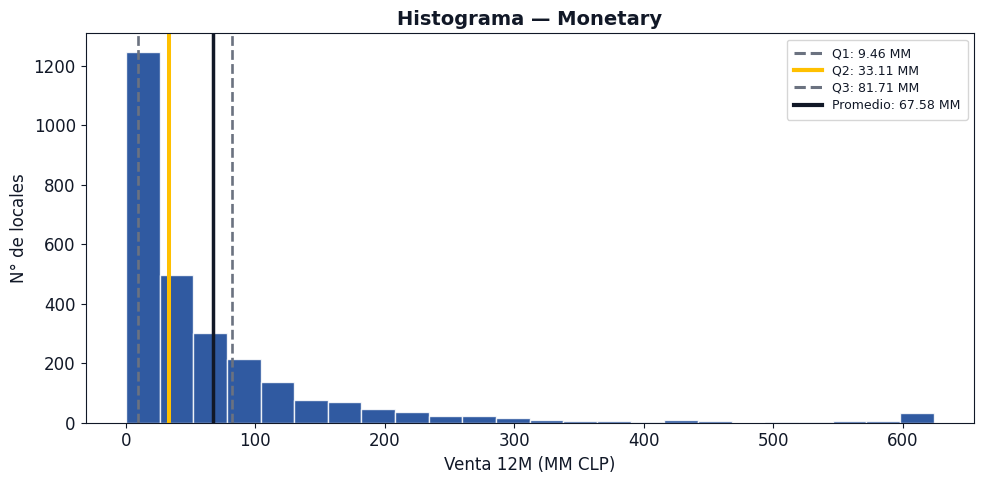

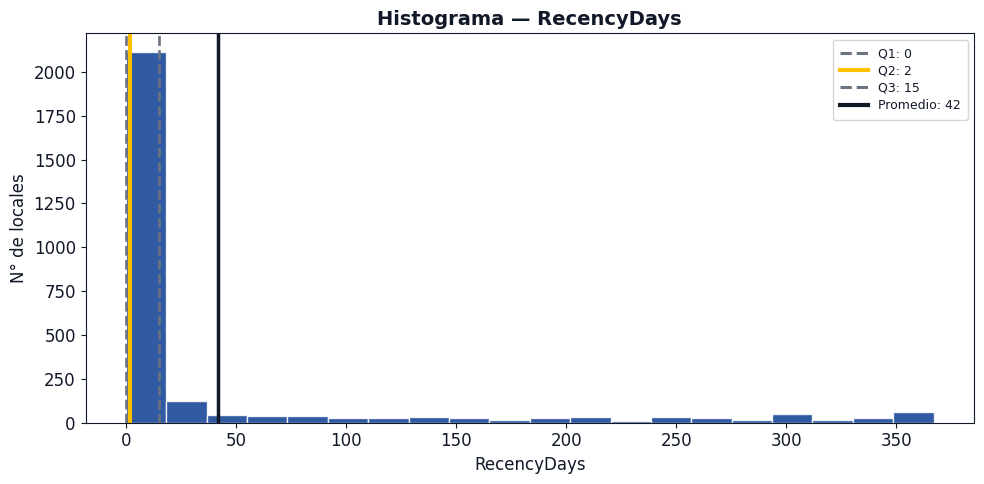

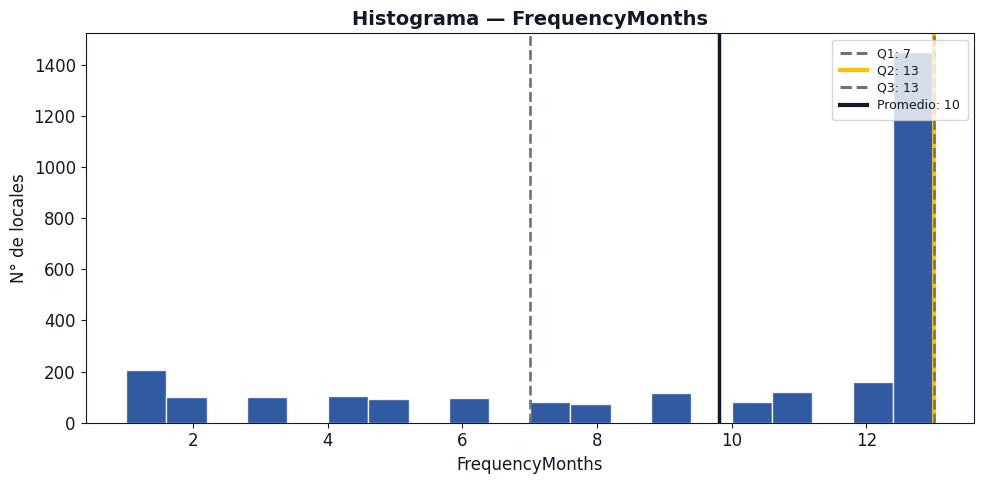

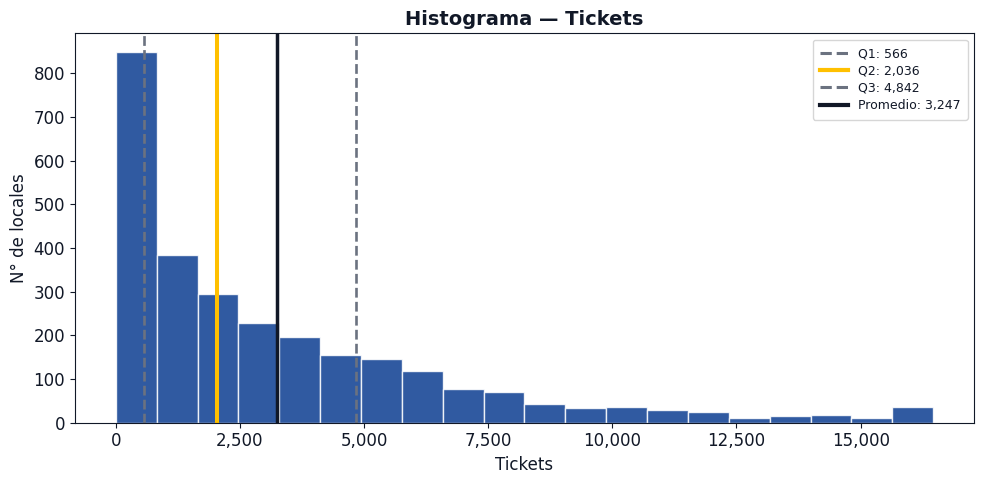

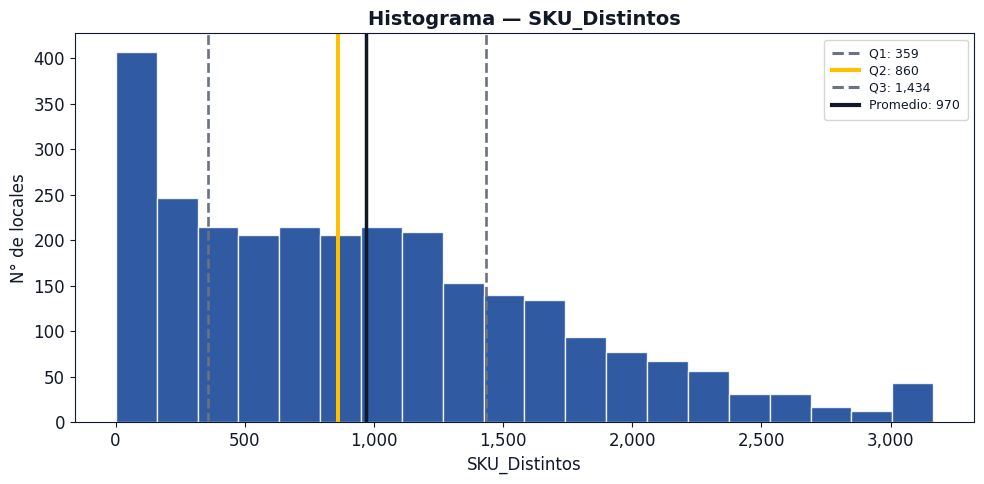

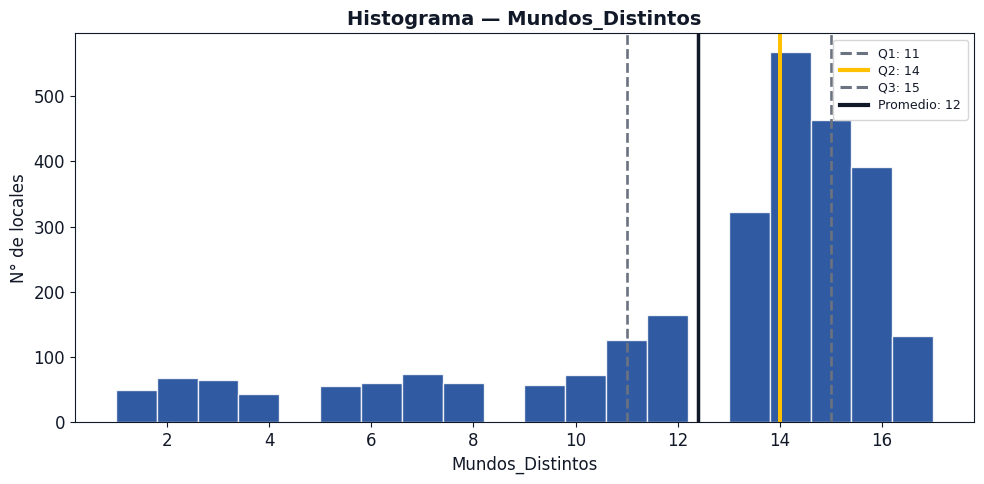

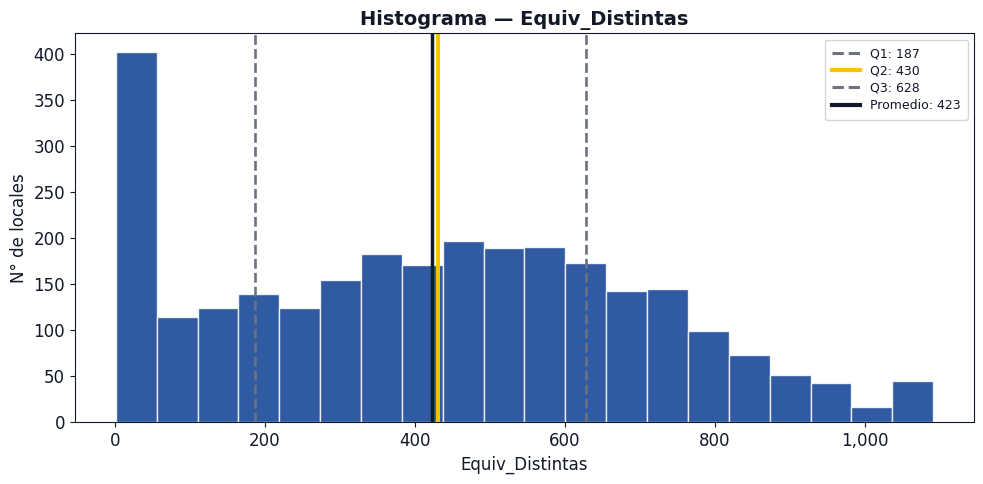

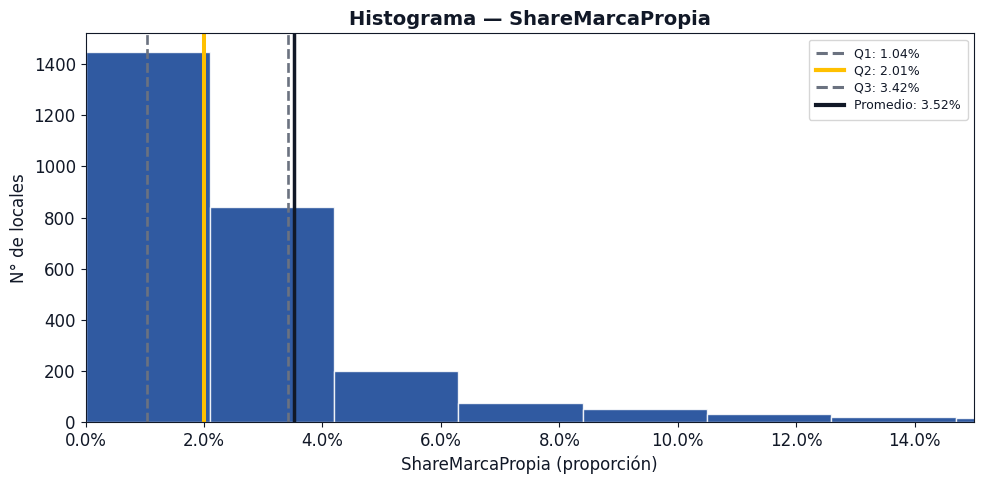

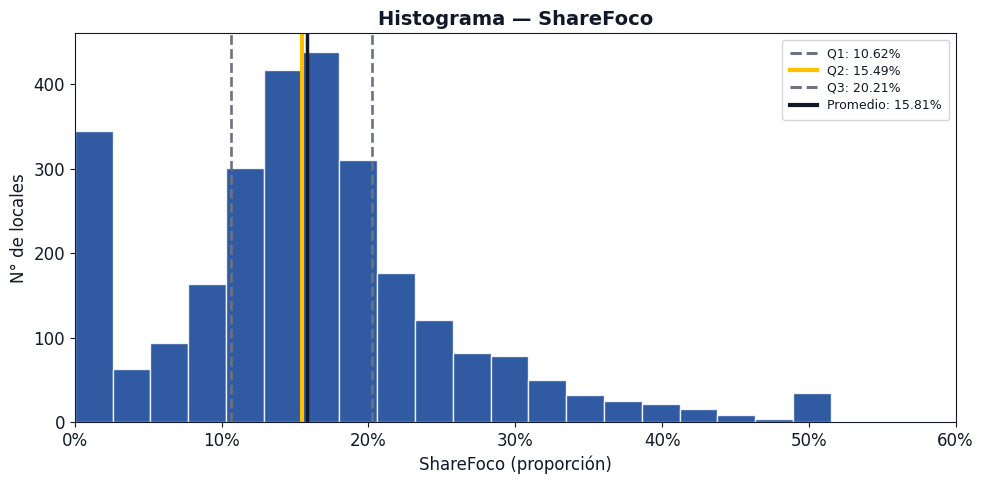

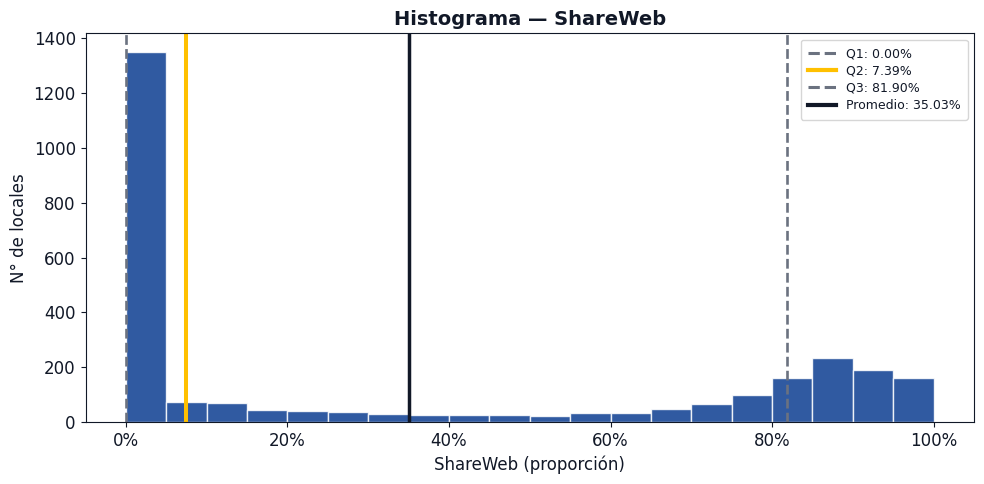

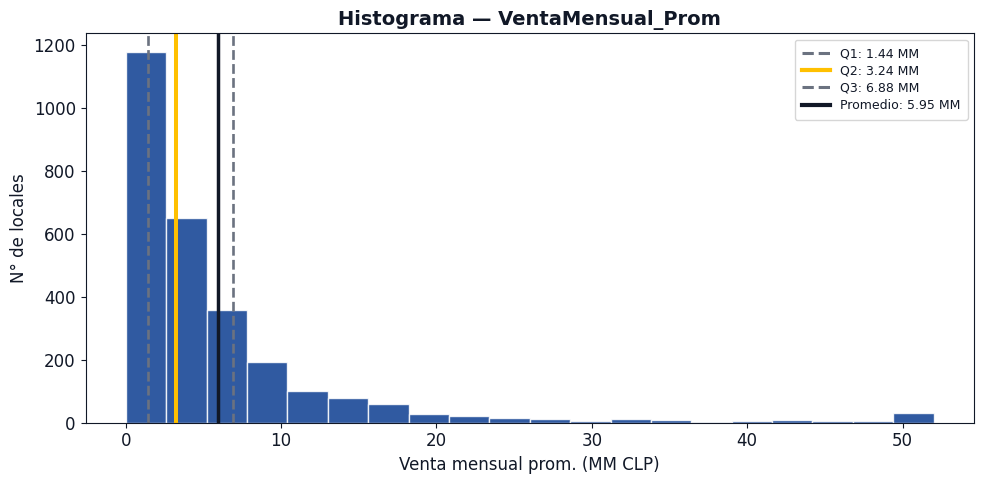

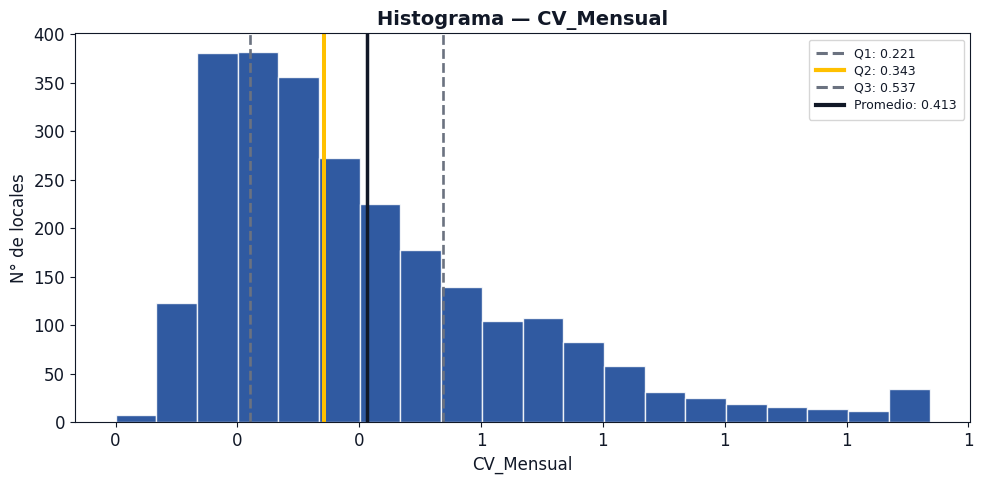

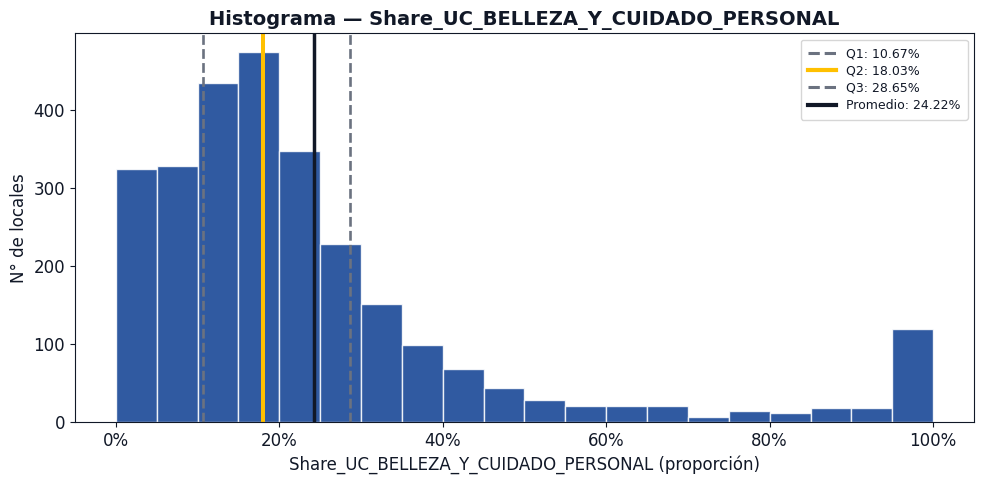

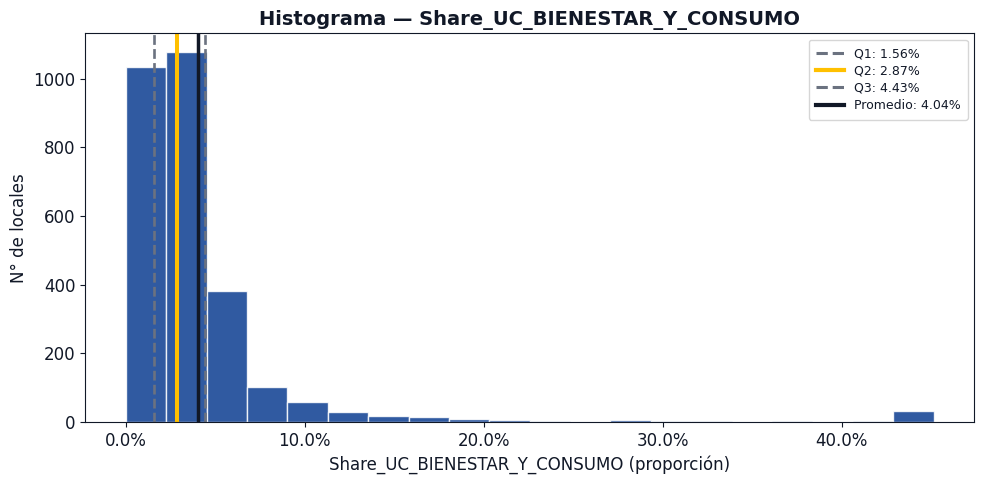

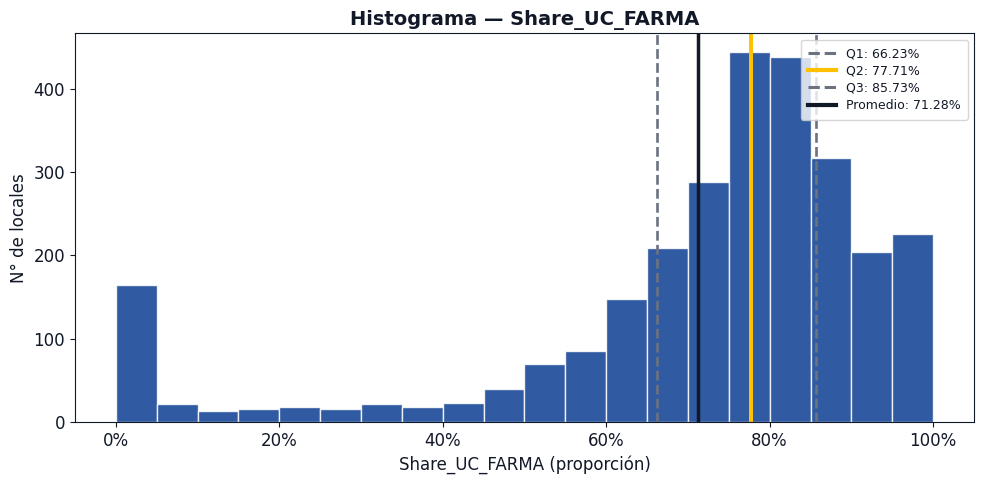

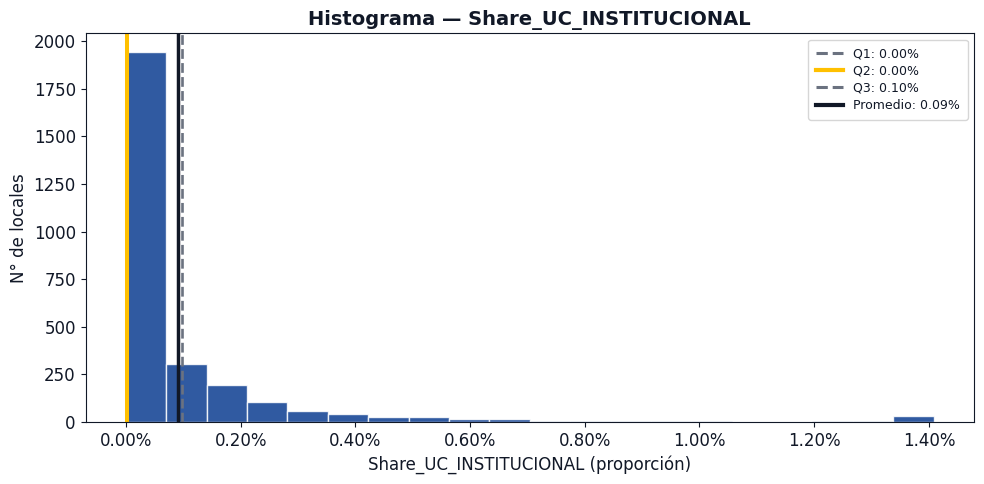

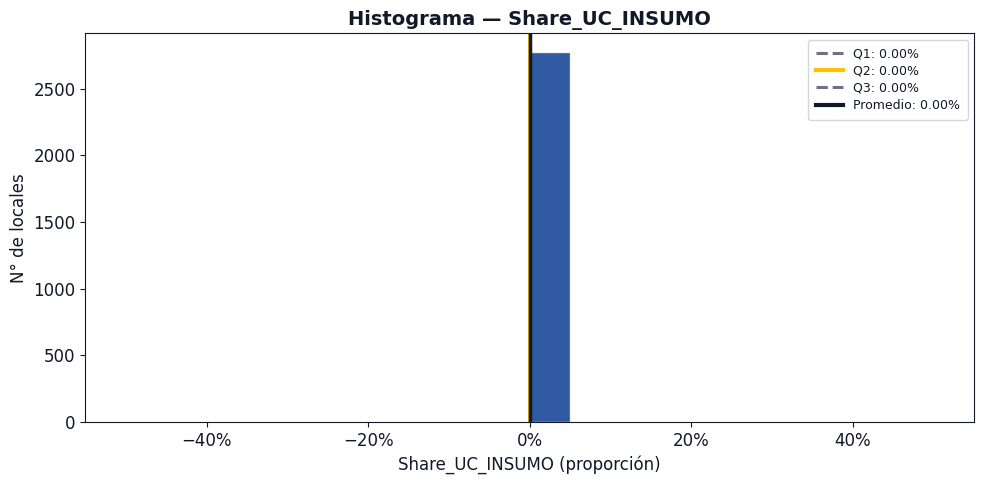

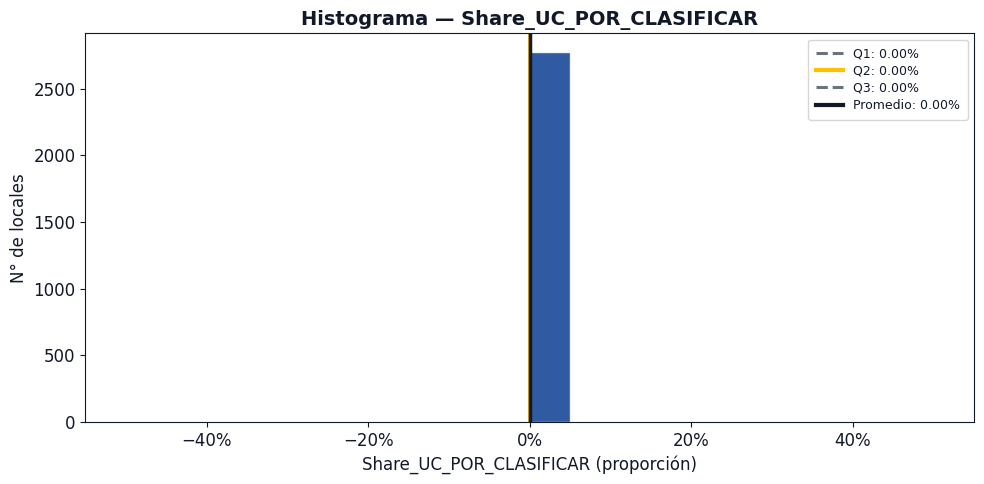

=== BOXPLOTS (incluye OutLow/OutHigh) ===


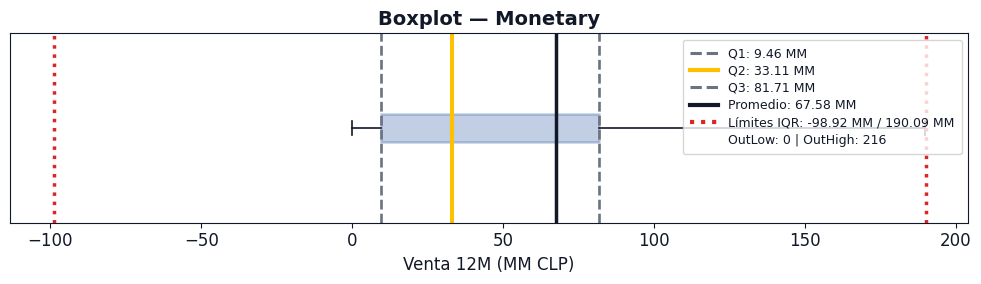

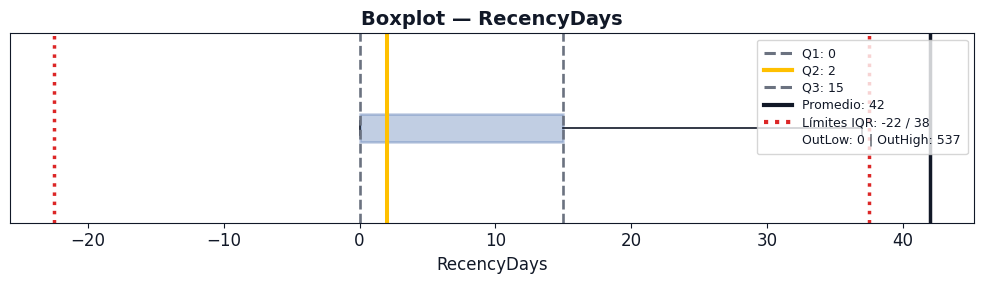

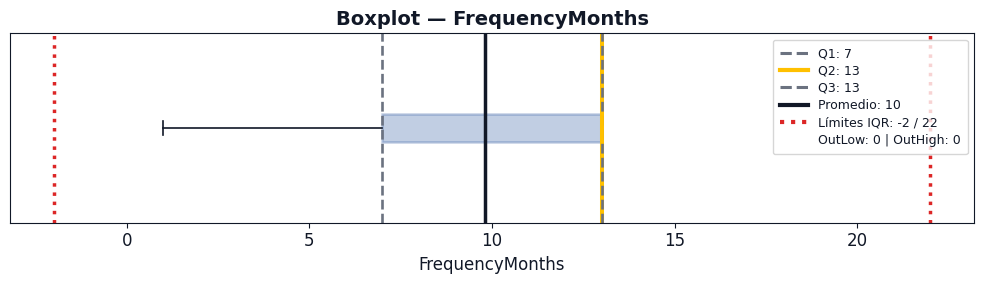

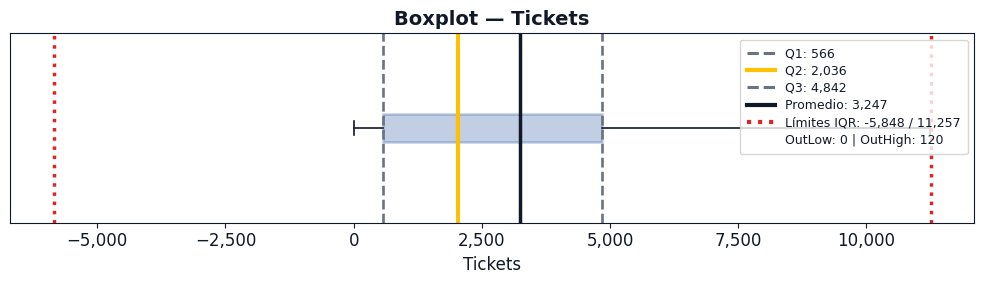

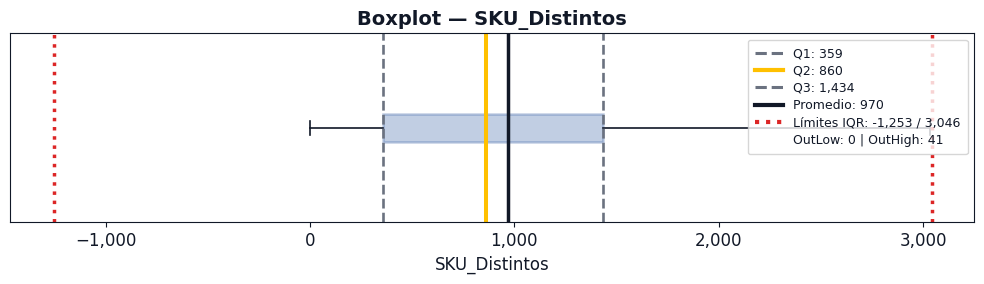

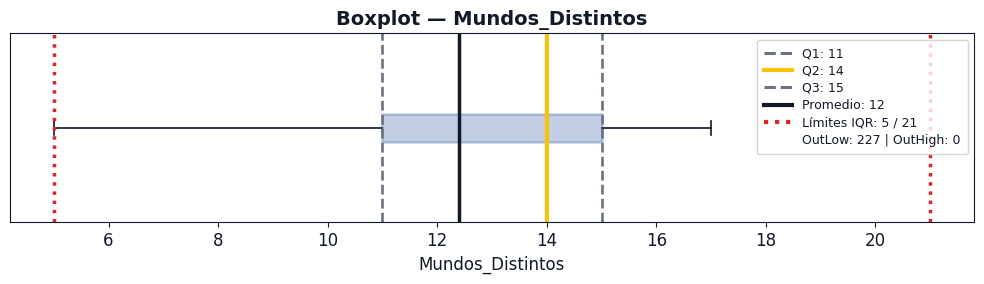

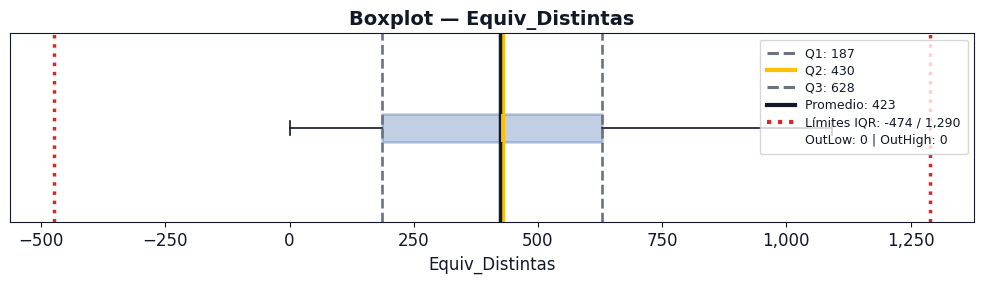

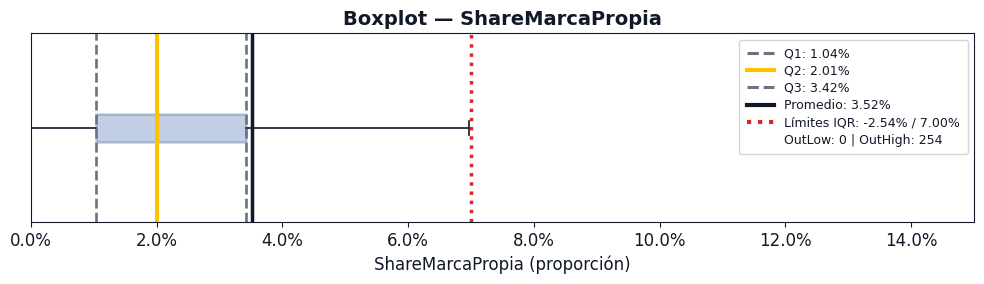

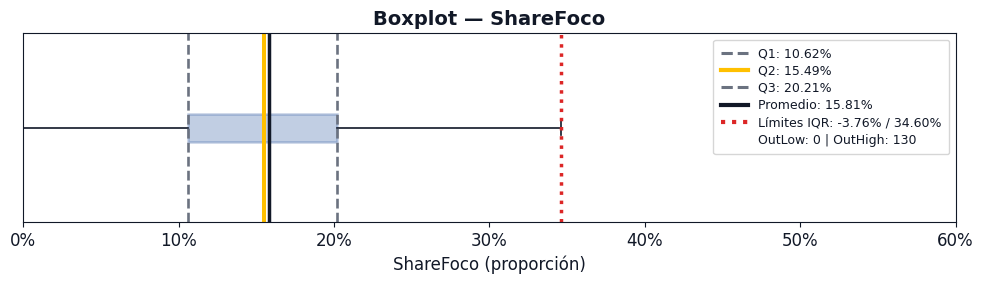

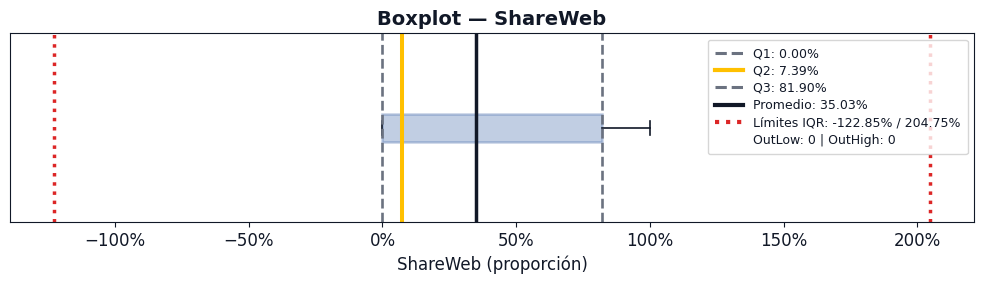

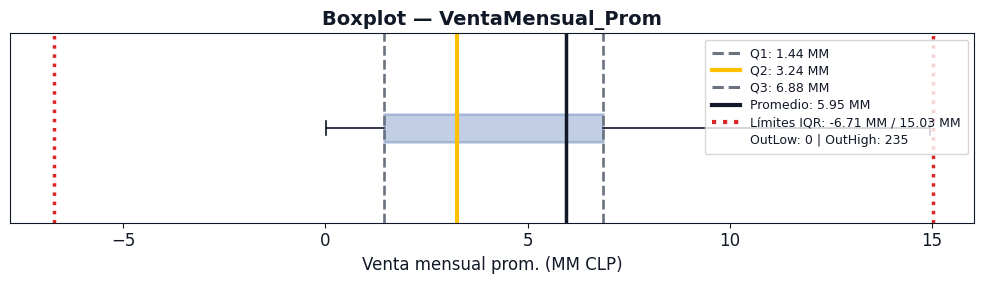

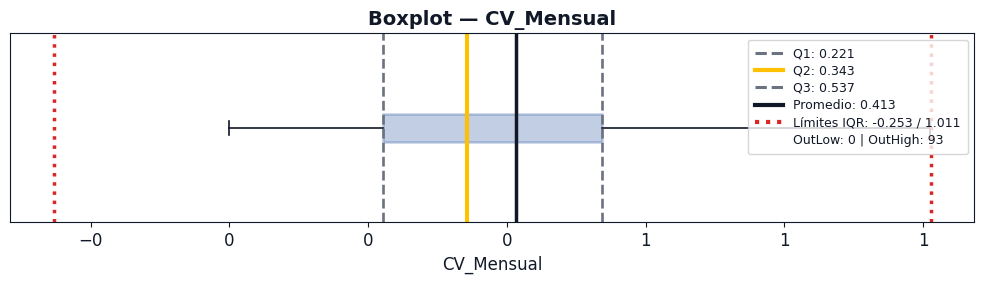

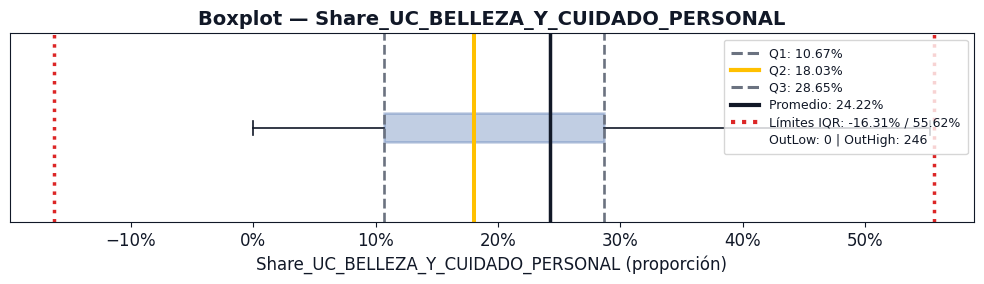

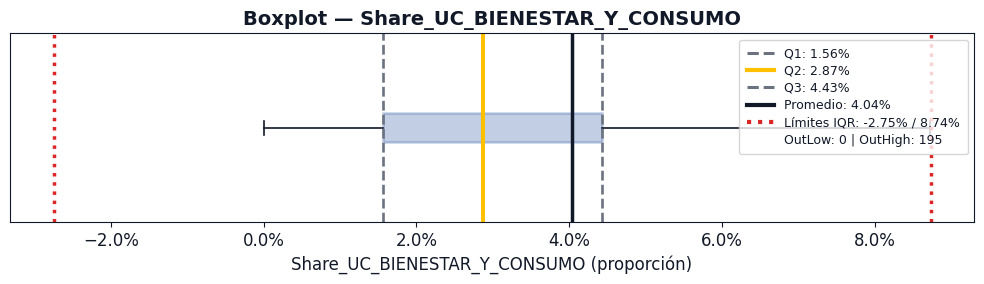

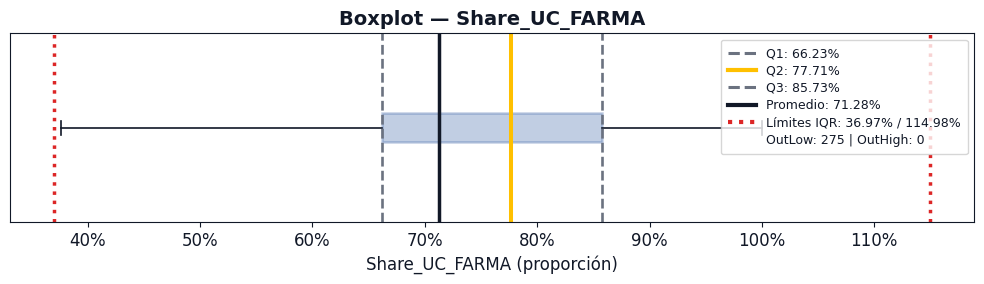

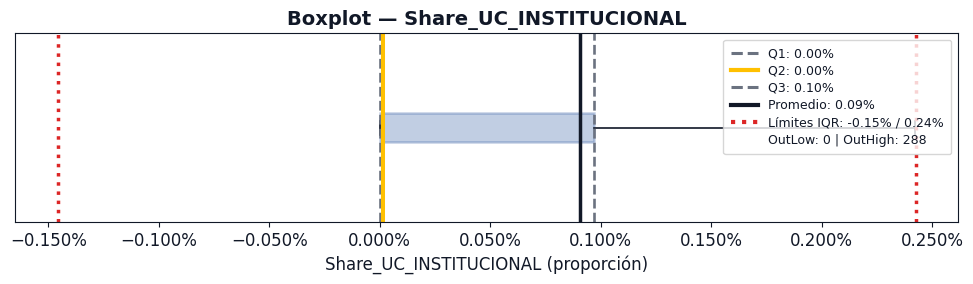

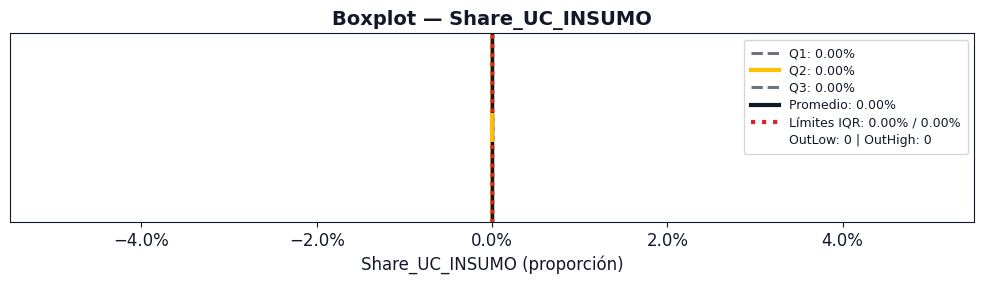

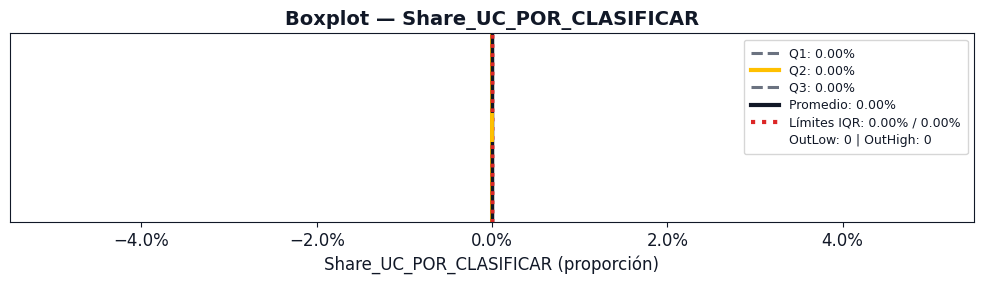


TABLA RESUMEN HISTOGRAMAS (copy/paste)
                           variable    n      Q1       Q2       Q3 Promedio      IQR
                           Monetary 2778 9.46 MM 33.11 MM 81.71 MM 67.58 MM 72.25 MM
                        RecencyDays 2778       0        2       15       42       15
                    FrequencyMonths 2778       7       13       13       10        6
                            Tickets 2778     566    2,036    4,842    3,247    4,276
                      SKU_Distintos 2778     359      860    1,434      970    1,075
                   Mundos_Distintos 2778      11       14       15       12        4
                    Equiv_Distintas 2778     187      430      628      423      441
                   ShareMarcaPropia 2778   1.04%    2.01%    3.42%    3.52%    2.39%
                          ShareFoco 2778  10.62%   15.49%   20.21%   15.81%    9.59%
                           ShareWeb 2778   0.00%    7.39%   81.90%   35.03%   81.90%
                  VentaMe

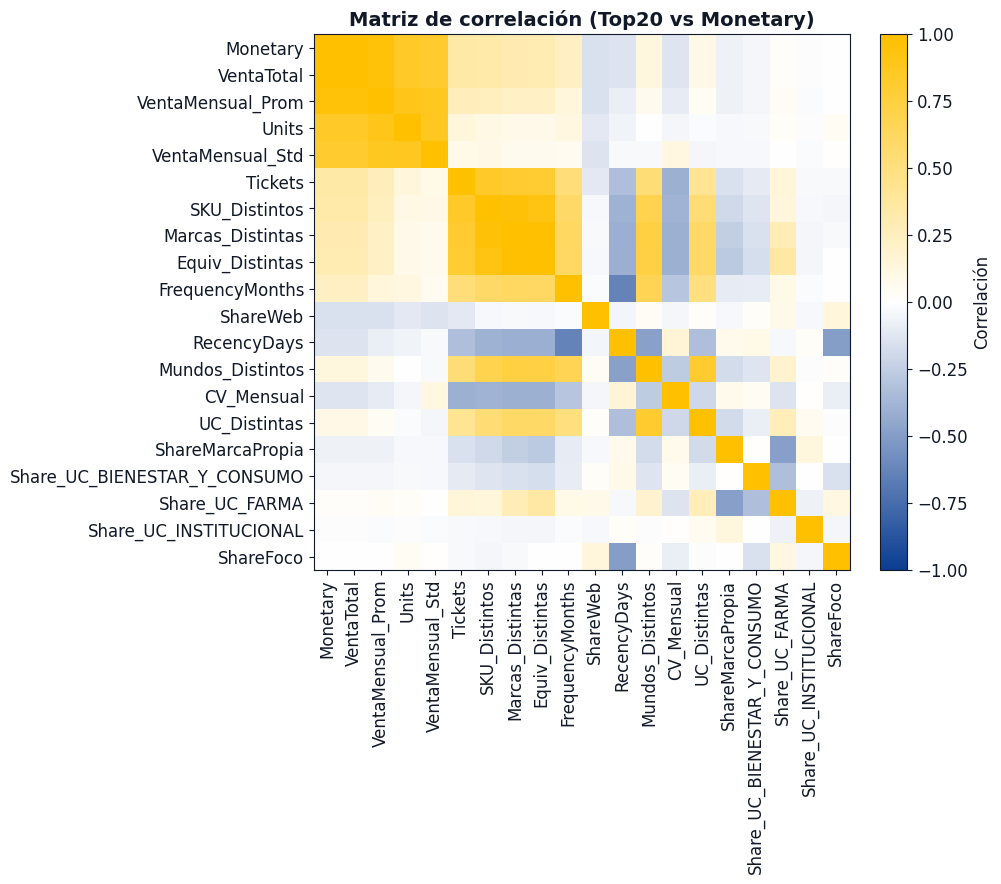


CORR — Variables incluidas en heatmap Top20
['Monetary', 'VentaTotal', 'VentaMensual_Prom', 'Units', 'VentaMensual_Std', 'Tickets', 'SKU_Distintos', 'Marcas_Distintas', 'Equiv_Distintas', 'FrequencyMonths', 'ShareWeb', 'RecencyDays', 'Mundos_Distintos', 'CV_Mensual', 'UC_Distintas', 'ShareMarcaPropia', 'Share_UC_BIENESTAR_Y_CONSUMO', 'Share_UC_FARMA', 'Share_UC_INSTITUCIONAL', 'ShareFoco']

CORR — Matriz Top20 (copy/paste)
                              Monetary  VentaTotal  VentaMensual_Prom   Units  VentaMensual_Std  Tickets  SKU_Distintos  Marcas_Distintas  Equiv_Distintas  FrequencyMonths  ShareWeb  RecencyDays  Mundos_Distintos  CV_Mensual  UC_Distintas  ShareMarcaPropia  Share_UC_BIENESTAR_Y_CONSUMO  Share_UC_FARMA  Share_UC_INSTITUCIONAL  ShareFoco
Monetary                        1.0000      1.0000             0.9539  0.8404            0.8149   0.3446         0.3359            0.3008           0.2961           0.2372   -0.1503      -0.1372            0.1321     -0.1294        0.

In [5]:
# =========================
# CELDA 4 — EDA (Histogramas + Boxplots + Outliers + Correlación) [100% CORREGIDA]
# - Compatible con df_cluster actual (2778 locales, ~27-28 cols)
# - Sin entities HTML (no &lt; / &gt;)
# - Robusta a pd.NA (convierte a np.nan)
# - Genera:
#   (1) Histogramas + tabla copy/paste
#   (2) Boxplots + tabla copy/paste
#   (3) Correlación: heatmap Top20 + matriz Top20 + top pares + top10 por variable
# - Incluye automáticamente todas las Share_UC_* disponibles (además de variables base)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap

# =========================
# REQUIERE df_cluster
# =========================
if "df_cluster" not in globals():
    raise RuntimeError("No existe 'df_cluster' en memoria. Ejecuta primero la celda que crea df_cluster.")

dfc = df_cluster.copy()

# Robustez: pandas NA -> np.nan
dfc = dfc.replace({pd.NA: np.nan})

# =========================
# COLORES / ESTILO
# =========================
PROV_BLUE   = "#0B3D91"
PROV_YELLOW = "#FFC000"
PROV_WHITE  = "#FFFFFF"
PROV_GRAY   = "#6B7280"
PROV_BLACK  = "#111827"   # Promedio en NEGRO
PROV_RED    = "#DC2626"   # Límites teóricos (IQR)

plt.rcParams.update({
    "figure.facecolor": PROV_WHITE,
    "axes.facecolor": PROV_WHITE,
    "axes.edgecolor": PROV_BLACK,
    "axes.labelcolor": PROV_BLACK,
    "text.color": PROV_BLACK,
    "xtick.color": PROV_BLACK,
    "ytick.color": PROV_BLACK,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

# =========================
# CONFIG
# =========================
CAP_P = 0.99
BINS_MONETARY = 24
BINS_OTHERS = 20

# Rangos amigables para shares (opcional)
SHARE_XLIMS = {
    "ShareFoco": (0.0, 0.60),
    "ShareMarcaPropia": (0.0, 0.15),
    # ShareWeb lo dejamos sin límite porque es polarizante (0–1)
}

# Variables base (si existen)
base_order = [
    "Monetary",
    "RecencyDays", "FrequencyMonths", "Tickets",
    "SKU_Distintos", "Mundos_Distintos", "Equiv_Distintas",
    "ShareMarcaPropia", "ShareFoco", "ShareWeb",
    "VentaMensual_Prom", "CV_Mensual",
]

# Auto-detect de todas las Share_UC_* disponibles (más robusto que listar 3)
uc_all = sorted([c for c in dfc.columns if isinstance(c, str) and c.startswith("Share_UC_")])

# Orden final de gráficos = base + todas las Share_UC_*
order = [c for c in base_order if c in dfc.columns] + [c for c in uc_all if c in dfc.columns]

# =========================
# HELPERS
# =========================
def cap_series(s, cap_p=CAP_P):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if s.empty:
        return s, np.nan
    cap = float(s.quantile(cap_p))
    return s.clip(upper=cap), cap

def to_plot_units(var, s):
    # ventas a millones para presentación
    if var in ("Monetary", "VentaMensual_Prom", "VentaMensual_Std", "VentaTotal"):
        return s / 1_000_000.0
    return s

def x_label(var):
    if var == "Monetary":
        return "Venta 12M (MM CLP)"
    if var == "VentaMensual_Prom":
        return "Venta mensual prom. (MM CLP)"
    if var == "VentaMensual_Std":
        return "Venta mensual std. (MM CLP)"
    if var.startswith("Share"):
        return f"{var} (proporción)"
    return var

def set_x_format(ax, var):
    if var.startswith("Share"):
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
    else:
        ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

def apply_share_xlim(ax, var):
    if var in SHARE_XLIMS:
        ax.set_xlim(*SHARE_XLIMS[var])

def compute_stats(s_plot):
    # s_plot: array numérico ya cappeado (p99) y convertido a unidades de plot
    s_plot = np.asarray(s_plot, dtype=float)
    q1 = float(np.quantile(s_plot, 0.25))
    q2 = float(np.quantile(s_plot, 0.50))
    q3 = float(np.quantile(s_plot, 0.75))
    mu = float(np.mean(s_plot))
    sd = float(np.std(s_plot, ddof=0))
    iqr = q3 - q1
    fence_low  = q1 - 1.5 * iqr
    fence_high = q3 + 1.5 * iqr

    # ✅ FIX: operadores reales (no HTML)
    out_low  = int((s_plot < fence_low).sum())
    out_high = int((s_plot > fence_high).sum())

    return dict(q1=q1, q2=q2, q3=q3, mean=mu, std=sd, iqr=iqr,
                fence_low=fence_low, fence_high=fence_high,
                out_low=out_low, out_high=out_high)

def fmt_value(var, x):
    # Formato para leyenda/tablas
    if var.startswith("Share"):
        return f"{x*100:.2f}%"
    if var in ("Monetary", "VentaMensual_Prom", "VentaMensual_Std", "VentaTotal"):
        return f"{x:,.2f} MM"
    if var == "CV_Mensual":
        return f"{x:.3f}"
    if var in ("RecencyDays", "FrequencyMonths"):
        return f"{x:,.0f}"
    return f"{x:,.0f}"

# =========================
# TABLAS PARA COPY/PASTE
# =========================
rows_hist = []
rows_box  = []

# =========================
# HISTOGRAMAS
# =========================
def plot_hist(var):
    raw = dfc[var]
    s_cap, _ = cap_series(raw, cap_p=CAP_P)
    if s_cap.empty:
        return

    s_plot = to_plot_units(var, s_cap)
    st = compute_stats(s_plot)

    bins = BINS_MONETARY if var == "Monetary" else BINS_OTHERS

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(np.asarray(s_plot), bins=bins, color=PROV_BLUE, alpha=0.85, edgecolor=PROV_WHITE)

    ax.axvline(st["q1"],   color=PROV_GRAY,   linestyle="--", linewidth=1.9)
    ax.axvline(st["q2"],   color=PROV_YELLOW, linestyle="-",  linewidth=2.9)
    ax.axvline(st["q3"],   color=PROV_GRAY,   linestyle="--", linewidth=1.9)
    ax.axvline(st["mean"], color=PROV_BLACK,  linestyle="-",  linewidth=2.5)

    apply_share_xlim(ax, var)
    set_x_format(ax, var)

    ax.set_title(f"Histograma — {var}")
    ax.set_xlabel(x_label(var))
    ax.set_ylabel("N° de locales")

    handles = [
        Line2D([0],[0], color=PROV_GRAY,   linestyle="--", linewidth=2.2, label=f"Q1: {fmt_value(var, st['q1'])}"),
        Line2D([0],[0], color=PROV_YELLOW, linestyle="-",  linewidth=3.0, label=f"Q2: {fmt_value(var, st['q2'])}"),
        Line2D([0],[0], color=PROV_GRAY,   linestyle="--", linewidth=2.2, label=f"Q3: {fmt_value(var, st['q3'])}"),
        Line2D([0],[0], color=PROV_BLACK,  linestyle="-",  linewidth=3.0, label=f"Promedio: {fmt_value(var, st['mean'])}"),
    ]
    ax.legend(handles=handles, loc="upper right", frameon=True, fontsize=9,
              handlelength=2.2, borderpad=0.6, labelspacing=0.35)

    plt.tight_layout()
    plt.show()

    rows_hist.append({
        "variable": var,
        "n": int(pd.to_numeric(raw, errors="coerce").dropna().shape[0]),
        "Q1": fmt_value(var, st["q1"]),
        "Q2": fmt_value(var, st["q2"]),
        "Q3": fmt_value(var, st["q3"]),
        "Promedio": fmt_value(var, st["mean"]),
        "IQR": fmt_value(var, st["iqr"]),
    })

# =========================
# BOXPLOTS
# =========================
def plot_box(var):
    raw = dfc[var]
    s_cap, _ = cap_series(raw, cap_p=CAP_P)
    if s_cap.empty:
        return

    s_plot = to_plot_units(var, s_cap)
    st = compute_stats(s_plot)

    fig, ax = plt.subplots(figsize=(10, 3.0))

    ax.boxplot(
        np.asarray(s_plot),
        vert=False,
        showfliers=False,
        patch_artist=True,
        boxprops=dict(facecolor=PROV_BLUE, alpha=0.25, edgecolor=PROV_BLUE, linewidth=1.8),
        medianprops=dict(color=PROV_YELLOW, linewidth=2.8),
        whiskerprops=dict(color=PROV_BLACK, linewidth=1.2),
        capprops=dict(color=PROV_BLACK, linewidth=1.2),
    )

    ax.axvline(st["q1"],         color=PROV_GRAY,   linestyle="--", linewidth=1.9)
    ax.axvline(st["q2"],         color=PROV_YELLOW, linestyle="-",  linewidth=2.9)
    ax.axvline(st["q3"],         color=PROV_GRAY,   linestyle="--", linewidth=1.9)
    ax.axvline(st["mean"],       color=PROV_BLACK,  linestyle="-",  linewidth=2.5)
    ax.axvline(st["fence_low"],  color=PROV_RED,    linestyle=":",  linewidth=2.5)
    ax.axvline(st["fence_high"], color=PROV_RED,    linestyle=":",  linewidth=2.5)

    apply_share_xlim(ax, var)
    set_x_format(ax, var)

    ax.set_title(f"Boxplot — {var}")
    ax.set_xlabel(x_label(var))
    ax.set_yticks([])

    handles = [
        Line2D([0],[0], color=PROV_GRAY,   linestyle="--", linewidth=2.2, label=f"Q1: {fmt_value(var, st['q1'])}"),
        Line2D([0],[0], color=PROV_YELLOW, linestyle="-",  linewidth=3.0, label=f"Q2: {fmt_value(var, st['q2'])}"),
        Line2D([0],[0], color=PROV_GRAY,   linestyle="--", linewidth=2.2, label=f"Q3: {fmt_value(var, st['q3'])}"),
        Line2D([0],[0], color=PROV_BLACK,  linestyle="-",  linewidth=3.0, label=f"Promedio: {fmt_value(var, st['mean'])}"),
        Line2D([0],[0], color=PROV_RED,    linestyle=":",  linewidth=3.0,
               label=f"Límites IQR: {fmt_value(var, st['fence_low'])} / {fmt_value(var, st['fence_high'])}"),
        Line2D([0],[0], color="none", label=f"OutLow: {st['out_low']} | OutHigh: {st['out_high']}"),
    ]
    ax.legend(handles=handles, loc="upper right", frameon=True, fontsize=9,
              handlelength=2.2, borderpad=0.6, labelspacing=0.35)

    plt.tight_layout()
    plt.show()

    rows_box.append({
        "variable": var,
        "n": int(pd.to_numeric(raw, errors="coerce").dropna().shape[0]),
        "Q1": fmt_value(var, st["q1"]),
        "Q2": fmt_value(var, st["q2"]),
        "Q3": fmt_value(var, st["q3"]),
        "Promedio": fmt_value(var, st["mean"]),
        "IQR": fmt_value(var, st["iqr"]),
        "LimitDown": fmt_value(var, st["fence_low"]),
        "LimitUp": fmt_value(var, st["fence_high"]),
        "OutLow": st["out_low"],
        "OutHigh": st["out_high"],
    })

# =========================
# 1) EJECUCIÓN: HIST + BOX
# =========================
print("=== HISTOGRAMAS (N° de locales) ===")
for v in order:
    plot_hist(v)

print("=== BOXPLOTS (incluye OutLow/OutHigh) ===")
for v in order:
    plot_box(v)

# =========================
# 2) TABLAS COPY/PASTE
# =========================
hist_table = pd.DataFrame(rows_hist)
box_table  = pd.DataFrame(rows_box)

if not hist_table.empty:
    hist_table["__ord"] = hist_table["variable"].apply(lambda x: order.index(x) if x in order else 999)
    hist_table = hist_table.sort_values("__ord").drop(columns="__ord")

if not box_table.empty:
    box_table["__ord"] = box_table["variable"].apply(lambda x: order.index(x) if x in order else 999)
    box_table = box_table.sort_values("__ord").drop(columns="__ord")

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

print("\n====================")
print("TABLA RESUMEN HISTOGRAMAS (copy/paste)")
print("====================")
print(hist_table.to_string(index=False))

print("\n====================")
print("TABLA RESUMEN BOXPLOTS (copy/paste)")
print("====================")
print(box_table.to_string(index=False))

# =========================================================
# 3) CORRELACIÓN: HEATMAP + TABLAS COPY/PASTE
# =========================================================
num_cols_corr = [c for c in dfc.columns if c != "IDLOCALCODIGO" and pd.api.types.is_numeric_dtype(dfc[c])]
corr_base = dfc[num_cols_corr].replace([np.inf, -np.inf], np.nan)

# Imputación mediana SOLO para correlación
corr_base = corr_base.apply(lambda s: s.fillna(s.median()), axis=0)

corr = corr_base.corr(numeric_only=True)

# Colormap Azul-Blanco-Amarillo
cmap_by = LinearSegmentedColormap.from_list(
    "prov_blue_white_yellow",
    [PROV_BLUE, PROV_WHITE, PROV_YELLOW],
    N=256
)

# Top20 vs Monetary (o primera numérica)
target = "Monetary" if "Monetary" in corr.columns else corr.columns[0]
top20 = corr[target].abs().sort_values(ascending=False).head(20).index.tolist()
corr_top20 = corr.loc[top20, top20]

# Heatmap Top20
fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr_top20.values, cmap=cmap_by, vmin=-1, vmax=1)

ax.set_title(f"Matriz de correlación (Top20 vs {target})", color=PROV_BLACK)
ax.set_xticks(range(len(top20)))
ax.set_yticks(range(len(top20)))
ax.set_xticklabels(top20, rotation=90)
ax.set_yticklabels(top20)

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Correlación")

plt.tight_layout()
plt.show()

print("\n====================")
print("CORR — Variables incluidas en heatmap Top20")
print("====================")
print(top20)

print("\n====================")
print("CORR — Matriz Top20 (copy/paste)")
print("====================")
print(corr_top20.round(4).to_string())

# Top pares globales
pairs = []
cols = list(corr.columns)
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        val = float(corr.iloc[i, j])
        pairs.append((cols[i], cols[j], val, abs(val)))

top_pairs = (pd.DataFrame(pairs, columns=["VarA", "VarB", "Corr", "CorrAbs"])
               .sort_values("CorrAbs", ascending=False)
               .head(20))
top_pairs["Corr"] = top_pairs["Corr"].round(4)
top_pairs["CorrAbs"] = top_pairs["CorrAbs"].round(4)

print("\n====================")
print("CORR — Top 20 correlaciones absolutas (pares) (copy/paste)")
print("====================")
print(top_pairs.to_string(index=False))

# Top10 por variable (solo variables clave + algunas Share_UC_* principales si existen)
key_vars = [v for v in [
    "Monetary","RecencyDays","FrequencyMonths","Tickets","SKU_Distintos","Mundos_Distintos",
    "Equiv_Distintas","ShareMarcaPropia","ShareFoco","ShareWeb","VentaMensual_Prom","CV_Mensual",
] if v in corr.columns]

# Agregar algunas Share_UC_* si existen (macro + extras)
for extra in ["Share_UC_FARMA", "Share_UC_BELLEZA_Y_CUIDADO_PERSONAL", "Share_UC_BIENESTAR_Y_CONSUMO",
              "Share_UC_INSTITUCIONAL", "Share_UC_INSUMO", "Share_UC_POR_CLASIFICAR"]:
    if extra in corr.columns and extra not in key_vars:
        key_vars.append(extra)

print("\n====================")
print("CORR — Top10 correlaciones por variable (copy/paste)")
print("====================")
for var in key_vars:
    s = corr[var].drop(labels=[var]).copy()
    top10_idx = s.abs().sort_values(ascending=False).head(10).index
    tbl = pd.DataFrame({
        "Variable": top10_idx,
        "Corr": s.loc[top10_idx].values,
        "CorrAbs": s.loc[top10_idx].abs().values
    }).sort_values("CorrAbs", ascending=False).reset_index(drop=True)
    tbl["Corr"] = tbl["Corr"].round(4)
    tbl["CorrAbs"] = tbl["CorrAbs"].round(4)
    print(f"\n--- Top10 correlaciones vs {var} ---")
    print(tbl.to_string(index=False))

print("\n✅ Listo: gráficos + tablas (hist/box) + heatmap + tablas de correlación (todo documentable).")

## Celda 5 — K‑Means + Método del Codo + Evaluación K=2..5 + PCA (solo visual) + Perfiles (K=2 y K=3) — MKD FINAL (versión con `X_final` sin colineales)

### 0) Objetivo
Esta celda entrena y evalúa **K‑Means** sobre la matriz `X_final` (salida de la Celda 3b), con el objetivo de:
1) seleccionar un K razonable (**método del codo**),
2) evaluar calidad de separación (**silhouette**) y **operabilidad** (tamaño mínimo de cluster),
3) interpretar clusters con perfiles numéricos (mediana y promedio),
4) visualizar separación en 2D con **PCA solo para graficar** (no para entrenar K‑Means).

---

### 1) Inputs y versión del espacio de features (muy importante)
**Input real usado en esta corrida:**
- `X_shape`: **(2778, 45)**  
- `features`: **45**
- Umbral de operabilidad: `min_cluster_count_1pct = 28` (≈1% de locales)

**Cambio metodológico clave (Celda 3b): eliminación de colineales/redundantes**
- Se eliminó **colinealidad perfecta** quitando `VentaTotal` (duplicada de `Monetary`).
- Se redujo redundancia extrema quitando `Marcas_Distintas` (muy redundante con medidas de amplitud como `Equiv_Distintas` y `SKU_Distintos`).

Esto asegura que K‑Means no “pese doble” la dimensión de tamaño/amplitud.

**Ejemplo de features (primeras 20):**
`RecencyDays, FrequencyMonths, Monetary, Units, Tickets, SKU_Distintos, Mundos_Distintos, UC_Distintas, Equiv_Distintas, ShareMarcaPropia, ShareFoco, ShareWeb, Share_UC_*, VentaMensual_Prom, VentaMensual_Std, CV_Mensual, ...`

---

### 2) Método del codo (Inercia/SSE vs K) — evidencia cuantitativa
Se entrena K‑Means con K=2..12 y se registra la inercia (SSE). También se calcula la caída marginal (`pct_drop`) al aumentar K.

**Tabla (copy/paste)**
 k      inertia  delta_inertia  pct_drop
 2 52029.274013            NaN       NaN
 3 45450.494732    6578.779281     12.64
 4 40888.709246    4561.785485     10.04
 5 37609.405233    3279.304014      8.02
 6 34829.137498    2780.267735      7.39
 7 32445.910669    2383.226829      6.84
 8 30259.978819    2185.931850      6.74
 9 28288.952597    1971.026223      6.51
10 26223.690136    2065.262461      7.30
11 24864.814232    1358.875904      5.18
12 23623.275608    1241.538624      4.99

**Lectura:**
- El mayor salto de mejora ocurre al pasar de **K=2 a K=3** (−12.64%).
- Luego las mejoras marginales disminuyen gradualmente (curva se “aplana”).
- Por codo, candidatos naturales: **K=2** y **K=3**, pero la decisión final debe considerar operabilidad (tamaños) e interpretación.

---

### 3) Evaluación K=2..5 (silhouette + operabilidad)
Se entrena K‑Means con K=2..5 y se reporta:
- Inercia
- Silhouette
- Tamaño mínimo de cluster
- Check de operabilidad: min_cluster_size ≥ 28

**Tabla (copy/paste)**
 k      inertia  silhouette  min_cluster_size  ok_min_cluster_>=28
 2 52029.274013    0.242126              1057                 True
 3 45450.494732    0.256825                11                False
 4 40888.709246    0.205957                11                False
 5 37609.405233    0.174863                11                False

**Conclusión técnica y operativa:**
- **K=3** mejora silhouette (0.2568) vs K=2 (0.2421), pero crea un **micro‑cluster de 11 locales**, muy por debajo del umbral (28).  
- **K=4 y K=5** también generan micro‑clusters (11) y además empeoran silhouette.
- Por criterio de operabilidad y estabilidad, **K=2 es la solución defendible**.

---

### 4) Tamaños por cluster (K=2..5)
**Tabla (copy/paste)**
 k  cluster  n_locales  share_pct
 2        1       1721  61.951044
 2        0       1057  38.048956
 3        1       1755  63.174946
 3        0       1012  36.429086
 3        2         11   0.395968
 4        0       1484  53.419726
 4        1       1007  36.249100
 4        3        276   9.935205
 4        2         11   0.395968
 5        4       1366  49.172066
 5        1        636  22.894168
 5        2        494  17.782577
 5        0        271   9.755220
 5        3         11   0.395968

**Lectura:**
- K=2 genera 2 clusters grandes y utilizables.
- K=3 introduce un cluster minúsculo (0.40%).
- K>3 no mejora interpretabilidad y mantiene micro‑clusters.

---

### 5) PCA (solo visual) — varianza explicada e interpretación
Se aplica PCA con 2 componentes **solo para visualizar** en scatter 2D.

**Varianza explicada:**
- PC1: **24.11%**
- PC2: **15.60%**
- Total PC1+PC2: **39.71%**

**Nota metodológica:**
- K‑Means se entrena en el espacio completo `X` (45 dimensiones).
- PCA solo sirve para “proyectar” a 2D y ver separación de clusters.

---

### 6) Loadings PCA (top variables que definen PC1 y PC2)
Los loadings explican qué variables empujan cada componente (útil para defensa y narrativa del scatter).

#### 6.1 TOP PC1 (por |loading|)
- `Equiv_Distintas` (0.3867)
- `SKU_Distintos` (0.3720)
- `Tickets` (0.3407)
- `Mundos_Distintos` (0.3333)
- `FrequencyMonths` (0.3114)
- `UC_Distintas` (0.2872)
- `Monetary` (0.2376)
- `RecencyDays` (−0.2287)
- `VentaMensual_Prom` (0.2092)
- `CV_Mensual` (−0.1846)
- `Units` (0.1620)

**Interpretación PC1:**
Eje dominado por **amplitud + intensidad + recurrencia** (más surtido, más tickets, más meses activos), con signo opuesto para **RecencyDays** (clientes más “fríos” bajan PC1).

#### 6.2 TOP PC2 (por |loading|)
- `VentaMensual_Std` (0.4686)
- `Units` (0.4601)
- `VentaMensual_Prom` (0.4532)
- `Monetary` (0.4219)
- `Mundos_Distintos` (−0.1912)
- `UC_Distintas` (−0.1855)
- `Equiv_Distintas` (−0.1293)

**Interpretación PC2:**
Eje dominado por **tamaño/variabilidad/unidades**, con signo opuesto para diversidad (mundo/UC/amplitud).

---

### 7) Perfiles por cluster (K=2 y K=3)
Se reportan **mediana (p50)** y **promedio (mean)** por cluster para variables clave.

#### 7.1 Perfil K=2 (interpretación defendible)
**Cluster 0 (≈38.05%) — “más pequeños, menos recurrentes, más fríos, menos intensivos”**
- p50:
  - `Monetary`: 6.41 MM
  - `RecencyDays`: 23
  - `FrequencyMonths`: 5
  - `Tickets`: 346
  - `SKU_Distintos`: 240
  - `Mundos_Distintos`: 10
  - `Equiv_Distintas`: 119
  - `CV_Mensual`: 0.574
  - `ShareWeb`: 0.0
  - `ShareFoco`: 0.1137
- mean (resumen):
  - `Monetary_mean`: 21.30 MM
  - `RecencyDays_mean`: 100.74
  - `CV_Mensual_mean`: 0.6187

**Cluster 1 (≈61.95%) — “más grandes, muy recurrentes, vivos, intensivos y más estables”**
- p50:
  - `Monetary`: 62.43 MM
  - `RecencyDays`: 1
  - `FrequencyMonths`: 13
  - `Tickets`: 3986
  - `SKU_Distintos`: 1263
  - `Mundos_Distintos`: 15
  - `Equiv_Distintas`: 581
  - `CV_Mensual`: 0.2767
  - `ShareWeb`: 0.1159
  - `ShareFoco`: 0.1603
- mean (resumen):
  - `Monetary_mean`: 107.52 MM
  - `RecencyDays_mean`: 6.17
  - `CV_Mensual_mean`: 0.3148

**Lectura ejecutiva K=2:**
K‑Means separa por un eje muy claro:
- **tamaño + intensidad + amplitud + recurrencia**
y además captura:
- **recencia** (vivo vs frío)
- **estabilidad** (CV más bajo en cluster grande)
- **adopción web** (mediana mayor en cluster grande)

#### 7.2 Perfil K=3 (por qué NO se elige)
K=3 genera un micro‑cluster (11 locales) que representa outliers gigantes:
- Cluster 2 p50 `Monetary` ≈ 1.803B, con `VentaMensual_Prom` y `VentaMensual_Std` extremadamente altos.

Esto refuerza que K=3 agrega un segmento de outliers, no un cluster operable.

---

### 8) Variables que más separan clusters (delta mediana max-min)
Se calcula la dispersión de medianas entre clusters (ranking de separadores).

#### 8.1 Top separadores K=2
- `Monetary` (5.60e+07)
- `VentaMensual_Prom` (3.86e+06)
- `VentaMensual_Std` (6.03e+05)
- `Tickets` (3640)
- `SKU_Distintos` (1023)
- `Equiv_Distintas` (462)
- `RecencyDays` (22)
- `FrequencyMonths` (8)
- `Mundos_Distintos` (5)
- `CV_Mensual` (~0.298)
- `ShareWeb` (~0.116)

**Lectura:** el cluster grande se distingue por tamaño, intensidad y amplitud; el cluster pequeño por recencia más alta y mayor volatilidad.

---

### 9) Decisión recomendada (conclusión)
**Se elige K=2** como solución final porque:
- cumple operabilidad (sin micro‑clusters),
- mantiene interpretación clara y útil,
- y es consistente con el diagnóstico del EDA.

K=3 tiene silhouette más alto pero genera un cluster minúsculo (11) que representa outliers.

---

### 10) Outputs listos para las siguientes celdas
Quedan disponibles en memoria:
- `elbow_table`
- `k_eval_small`
- `sizes_by_k`
- `labels_by_k`
- `profiles`
- `separators`
- `pca_loadings_df`

FIN.


CELDA 5 — K-MEANS + CODO + K=2..5 + PCA (solo visual) + perfiles (K=2 y K=3)
X_shape: (2778, 45) | features: 45 | min_cluster_count_1pct: 28
Ejemplo features (primeras 20): ['RecencyDays', 'FrequencyMonths', 'Monetary', 'Units', 'Tickets', 'SKU_Distintos', 'Mundos_Distintos', 'UC_Distintas', 'Equiv_Distintas', 'ShareMarcaPropia', 'ShareFoco', 'ShareWeb', 'Share_UC_BELLEZA_Y_CUIDADO_PERSONAL', 'Share_UC_BIENESTAR_Y_CONSUMO', 'Share_UC_FARMA', 'Share_UC_INSTITUCIONAL', 'Share_UC_INSUMO', 'Share_UC_POR_CLASIFICAR', 'VentaMensual_Prom', 'VentaMensual_Std']

MÉTODO DEL CODO — RESULTADOS NUMÉRICOS (copy/paste)
 k      inertia  delta_inertia  pct_drop
 2 52029.274013            NaN       NaN
 3 45450.494732    6578.779281     12.64
 4 40888.709246    4561.785485     10.04
 5 37609.405233    3279.304014      8.02
 6 34829.137498    2780.267735      7.39
 7 32445.910669    2383.226829      6.84
 8 30259.978819    2185.931850      6.74
 9 28288.952597    1971.026223      6.51
10 26223.690136   

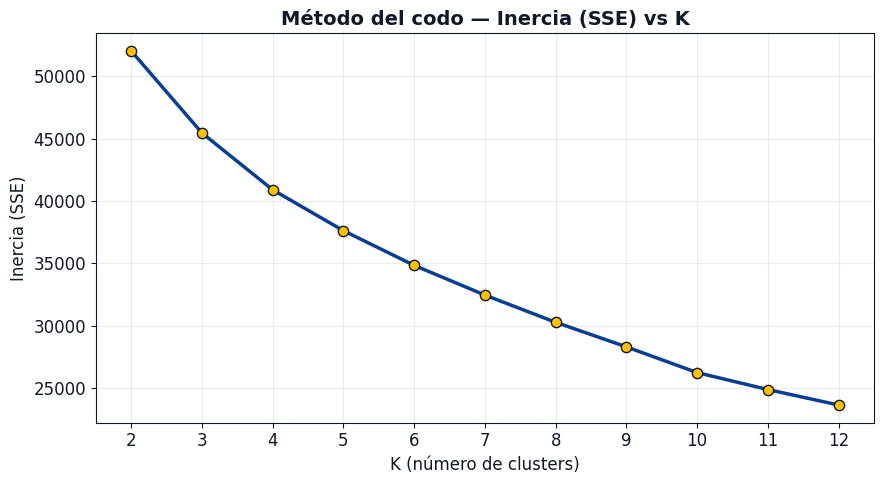


K-MEANS — RESUMEN K=2..5 (copy/paste)
 k      inertia  silhouette  min_cluster_size  ok_min_cluster_>=28
 2 52029.274013    0.242126              1057                 True
 3 45450.494732    0.256825                11                False
 4 40888.709246    0.205957                11                False
 5 37609.405233    0.174863                11                False

K-MEANS — TAMAÑOS POR CLUSTER (K=2..5) (copy/paste)
 k  cluster  n_locales  share_pct
 2        1       1721  61.951044
 2        0       1057  38.048956
 3        1       1755  63.174946
 3        0       1012  36.429086
 3        2         11   0.395968
 4        0       1484  53.419726
 4        1       1007  36.249100
 4        3        276   9.935205
 4        2         11   0.395968
 5        4       1366  49.172066
 5        1        636  22.894168
 5        2        494  17.782577
 5        0        271   9.755220
 5        3         11   0.395968

PCA (SOLO VISUAL) — Varianza explicada
PC1: 24.11% | PC2: 15.6

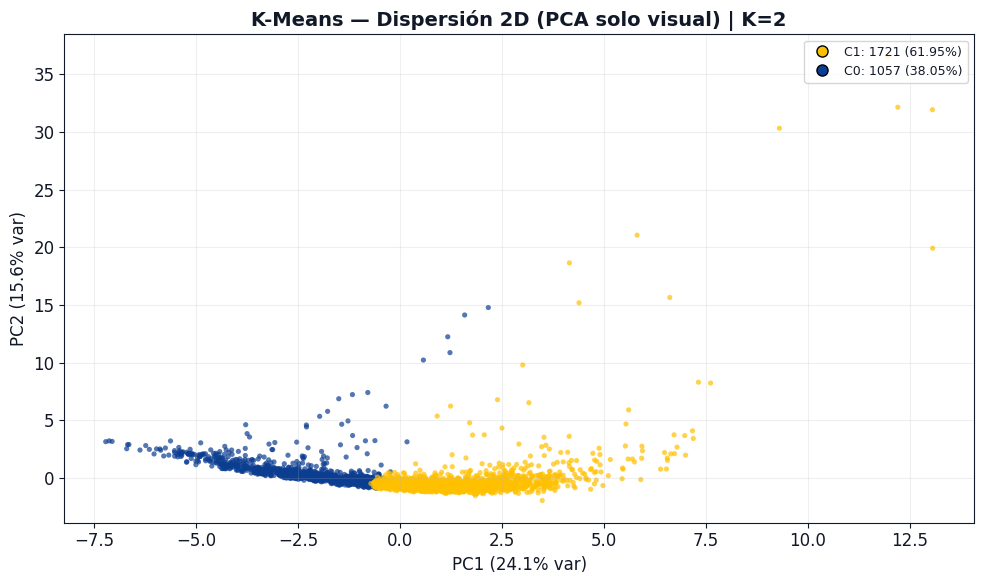

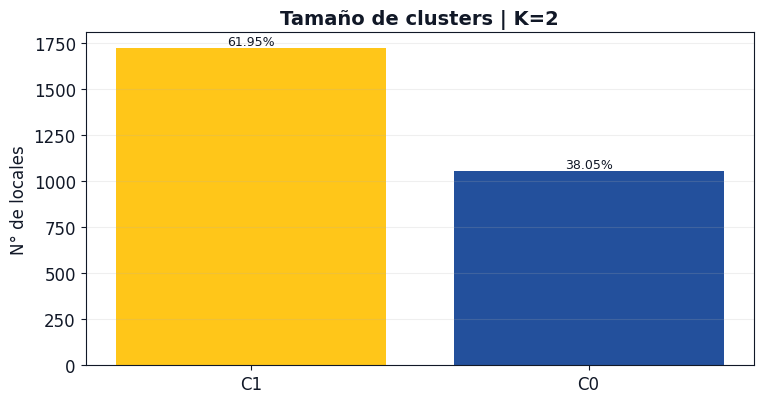

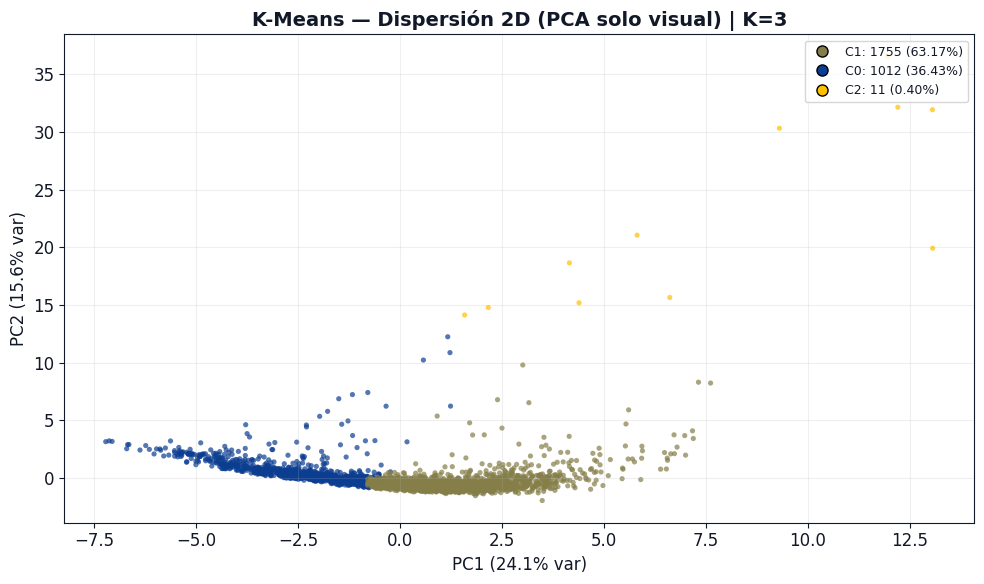

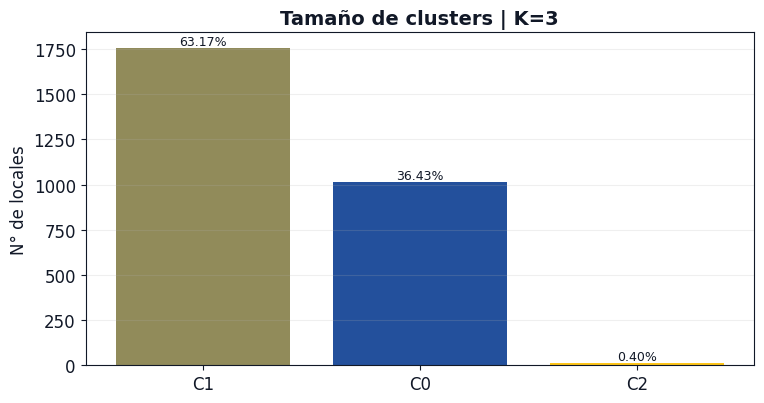


✅ Listo. Objetos en memoria:
- elbow_table, k_eval_small, sizes_by_k, labels_by_k
- profiles, separators
- pca_loadings_df


In [6]:
# =========================
# CELDA 5 — K-Means + Codo + Evaluación K=2..5 + PCA (solo visual) + Perfiles (K=2 y K=3)
# Requiere:
# - X (matriz final) y feature_names (idealmente desde Celda 3b: X FINAL sin colineales)
# - df_cluster (para perfilamiento)
# Entrega:
# - elbow_table (K=2..12)
# - k_eval_small (K=2..5: inertia, silhouette, min_cluster_size, check operabilidad)
# - sizes_by_k (tamaños por cluster)
# - PCA: varianza + loadings (pca_loadings_df)
# - profiles/separators (K=2 y K=3) para interpretación
# - Scatter PCA + barras de tamaños (K=2 y K=3)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap

# -------------------------
# 0) Validaciones
# -------------------------
if "X" not in globals() or "feature_names" not in globals():
    raise RuntimeError("No existe X/feature_names en memoria. Ejecuta Celda 3 (o mejor Celda 3b) antes.")

if "df_cluster" not in globals():
    raise RuntimeError("No existe df_cluster en memoria. Ejecuta Celda 2 antes.")

X_used = np.asarray(X)
feature_names_used = list(feature_names)
dfc = df_cluster.copy()

if X_used.shape[0] != len(dfc):
    print("WARN: X y df_cluster no tienen el mismo número de filas.")
    print("X:", X_used.shape, " df_cluster:", dfc.shape)

n_locales = X_used.shape[0]
MIN_CLUSTER_COUNT = int(np.ceil(n_locales * 0.01))  # ~1% de locales
N_INIT = 30
SEED = 42

# -------------------------
# 0.b) Estilo / colores
# -------------------------
PROV_BLUE   = "#0B3D91"
PROV_YELLOW = "#FFC000"
PROV_WHITE  = "#FFFFFF"
PROV_GRAY   = "#6B7280"
PROV_BLACK  = "#111827"
PROV_RED    = "#DC2626"

plt.rcParams.update({
    "figure.facecolor": PROV_WHITE,
    "axes.facecolor": PROV_WHITE,
    "axes.edgecolor": PROV_BLACK,
    "axes.labelcolor": PROV_BLACK,
    "text.color": PROV_BLACK,
    "xtick.color": PROV_BLACK,
    "ytick.color": PROV_BLACK,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

cmap_b2y = LinearSegmentedColormap.from_list("blue_to_yellow", [PROV_BLUE, PROV_YELLOW], N=256)

def colors_for_k(k: int):
    xs = np.linspace(0.0, 1.0, k)
    cols = [cmap_b2y(x) for x in xs]
    return ["#{0:02x}{1:02x}{2:02x}".format(int(r*255), int(g*255), int(b*255)) for r,g,b,a in cols]

print("\n" + "="*90)
print("CELDA 5 — K-MEANS + CODO + K=2..5 + PCA (solo visual) + perfiles (K=2 y K=3)")
print("="*90)
print("X_shape:", X_used.shape, "| features:", len(feature_names_used), "| min_cluster_count_1pct:", MIN_CLUSTER_COUNT)
print("Ejemplo features (primeras 20):", feature_names_used[:20])

# -------------------------
# 1) Método del codo (Inercia/SSE vs K)
# -------------------------
K_RANGE_ELBOW = list(range(2, 13))
rows_elbow = []

for k in K_RANGE_ELBOW:
    km = KMeans(n_clusters=k, n_init=N_INIT, random_state=SEED)
    km.fit(X_used)
    rows_elbow.append({"k": k, "inertia": float(km.inertia_)})

elbow_table = pd.DataFrame(rows_elbow).sort_values("k").reset_index(drop=True)
elbow_table["delta_inertia"] = elbow_table["inertia"].shift(1) - elbow_table["inertia"]
elbow_table["pct_drop"] = (elbow_table["delta_inertia"] / elbow_table["inertia"].shift(1) * 100).round(2)

print("\n" + "="*90)
print("MÉTODO DEL CODO — RESULTADOS NUMÉRICOS (copy/paste)")
print("="*90)
print(elbow_table.to_string(index=False))

plt.figure(figsize=(9, 5))
plt.plot(elbow_table["k"], elbow_table["inertia"], marker="o", linewidth=2.5, color=PROV_BLUE)
plt.scatter(elbow_table["k"], elbow_table["inertia"], s=55, color=PROV_YELLOW, edgecolor=PROV_BLACK, zorder=3)
plt.xticks(elbow_table["k"])
plt.title("Método del codo — Inercia (SSE) vs K")
plt.xlabel("K (número de clusters)")
plt.ylabel("Inercia (SSE)")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# -------------------------
# 2) Evaluación K=2..5 (silhouette + tamaños)
# -------------------------
K_CHECK = [2, 3, 4, 5]
rows_k = []
sizes_rows = []
labels_by_k = {}

for k in K_CHECK:
    km = KMeans(n_clusters=k, n_init=N_INIT, random_state=SEED)
    labels = km.fit_predict(X_used)
    labels_by_k[k] = labels

    inertia = float(km.inertia_)
    sil = float(silhouette_score(X_used, labels))

    vc = pd.Series(labels).value_counts().sort_index()
    min_size = int(vc.min())
    ok_size = (min_size >= MIN_CLUSTER_COUNT)

    rows_k.append({
        "k": k,
        "inertia": round(inertia, 6),
        "silhouette": round(sil, 6),
        "min_cluster_size": min_size,
        f"ok_min_cluster_>={MIN_CLUSTER_COUNT}": ok_size
    })

    total = int(vc.sum())
    for lab, cnt in vc.items():
        sizes_rows.append({
            "k": k,
            "cluster": int(lab),
            "n_locales": int(cnt),
            "share_pct": round(cnt / total * 100, 6)
        })

k_eval_small = pd.DataFrame(rows_k).sort_values("k").reset_index(drop=True)
sizes_by_k = (pd.DataFrame(sizes_rows)
              .sort_values(["k", "n_locales"], ascending=[True, False])
              .reset_index(drop=True))

print("\n" + "="*90)
print("K-MEANS — RESUMEN K=2..5 (copy/paste)")
print("="*90)
print(k_eval_small.to_string(index=False))

print("\n" + "="*90)
print("K-MEANS — TAMAÑOS POR CLUSTER (K=2..5) (copy/paste)")
print("="*90)
print(sizes_by_k.to_string(index=False))

# -------------------------
# 3) PCA SOLO VISUAL (scatter 2D + loadings)
# -------------------------
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_used)
evr = pca.explained_variance_ratio_

print("\n" + "="*90)
print("PCA (SOLO VISUAL) — Varianza explicada")
print("="*90)
print(f"PC1: {evr[0]*100:.2f}% | PC2: {evr[1]*100:.2f}% | Total: {(evr[0]+evr[1])*100:.2f}%")
print(f"Nota: K-Means se entrena en X ({X_used.shape[1]} dims). PCA solo dibuja en 2D.\n")

loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_names_used,
    columns=["PC1_loading", "PC2_loading"]
)
loadings["PC1_abs"] = loadings["PC1_loading"].abs()
loadings["PC2_abs"] = loadings["PC2_loading"].abs()

is_dummy = pd.Series([("Segmentacion_1_" in f) or ("REGIONDESCRIPCION_" in f) for f in feature_names_used],
                     index=feature_names_used)
loadings["tipo"] = np.where(is_dummy, "dummy", "numérica")

TOPN = 15
top_pc1 = loadings.sort_values("PC1_abs", ascending=False).head(TOPN)[["tipo","PC1_loading","PC1_abs"]]
top_pc2 = loadings.sort_values("PC2_abs", ascending=False).head(TOPN)[["tipo","PC2_loading","PC2_abs"]]

print("\n" + "="*90)
print("PCA (SOLO VISUAL) — TOP LOADINGS PC1 / PC2 (copy/paste)")
print("="*90)
print("\n--- TOP PC1 (por |loading|) ---")
print(top_pc1.to_string())
print("\n--- TOP PC2 (por |loading|) ---")
print(top_pc2.to_string())

pca_loadings_df = loadings.sort_values(["PC1_abs","PC2_abs"], ascending=False)

# -------------------------
# 4) Perfilamiento rápido (K=2 y K=3) + separadores por delta de mediana
# -------------------------
profile_vars = [v for v in [
    "Monetary","RecencyDays","FrequencyMonths","Tickets",
    "SKU_Distintos","Mundos_Distintos","UC_Distintas","Equiv_Distintas",
    "VentaMensual_Prom","VentaMensual_Std","CV_Mensual",
    "ShareWeb","ShareFoco","ShareMarcaPropia",
    "Share_UC_FARMA","Share_UC_BELLEZA_Y_CUIDADO_PERSONAL","Share_UC_BIENESTAR_Y_CONSUMO",
    "Share_UC_INSTITUCIONAL","Share_UC_INSUMO","Share_UC_POR_CLASIFICAR"
] if v in dfc.columns]

def profile_table(dfp, cluster_col="_cluster"):
    g = dfp.groupby(cluster_col)[profile_vars]
    return pd.concat([
        g.median(numeric_only=True).add_suffix("_p50"),
        g.mean(numeric_only=True).add_suffix("_mean"),
    ], axis=1)

def top_separators(dfp, cluster_col="_cluster", topn=12):
    meds = dfp.groupby(cluster_col)[profile_vars].median(numeric_only=True)
    spread = (meds.max(axis=0) - meds.min(axis=0)).sort_values(ascending=False)
    return pd.DataFrame({"variable": spread.index[:topn], "delta_median_max_min": spread.values[:topn]})

profiles = {}
separators = {}

for k in [2, 3]:
    dfp = dfc.copy()
    dfp["_cluster"] = labels_by_k[k]
    profiles[k] = profile_table(dfp, "_cluster")
    separators[k] = top_separators(dfp, "_cluster", topn=12)

print("\n" + "="*90)
print("PERFILES POR CLUSTER (copy/paste) — MEDIANA(p50) y PROMEDIO(mean) — SOLO K=2 y K=3")
print("="*90)
for k in [2, 3]:
    print(f"\n--- PERFIL K={k} ---")
    print(profiles[k].to_string())

print("\n" + "="*90)
print("TOP VARIABLES QUE MÁS SEPARAN (copy/paste) — delta(mediana max-min) — SOLO K=2 y K=3")
print("="*90)
for k in [2, 3]:
    print(f"\n--- TOP SEPARADORES K={k} ---")
    print(separators[k].to_string(index=False))

# -------------------------
# 5) Gráficos: scatter PCA + barras de tamaños (K=2 y K=3)
# -------------------------
def plot_scenario_scatter_and_sizes(k: int):
    labels = labels_by_k[k]
    palette = colors_for_k(k)

    s = (sizes_by_k[sizes_by_k["k"] == k]
         .copy()
         .sort_values("n_locales", ascending=False)
         .reset_index(drop=True))

    # Scatter PCA
    fig, ax = plt.subplots(figsize=(10, 6))
    for cl in range(k):
        mask = (labels == cl)
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=14, alpha=0.70,
                   color=palette[cl], edgecolor="none")

    ax.set_title(f"K-Means — Dispersión 2D (PCA solo visual) | K={k}")
    ax.set_xlabel(f"PC1 ({evr[0]*100:.1f}% var)")
    ax.set_ylabel(f"PC2 ({evr[1]*100:.1f}% var)")
    ax.grid(True, alpha=0.20)

    handles = []
    for _, row in s.iterrows():
        cl = int(row["cluster"])
        label_txt = f"C{cl}: {int(row['n_locales'])} ({row['share_pct']:.2f}%)"
        handles.append(Line2D([0],[0], marker='o', color='none',
                              markerfacecolor=palette[cl], markersize=8,
                              label=label_txt))
    ax.legend(handles=handles, loc="upper right", frameon=True, fontsize=9)
    plt.tight_layout()
    plt.show()

    # Barras tamaños
    fig, ax2 = plt.subplots(figsize=(7.8, 4.2))
    xs = np.arange(len(s))
    ax2.bar(xs, s["n_locales"].values,
            color=[palette[int(c)] for c in s["cluster"].values], alpha=0.90)
    ax2.set_xticks(xs)
    ax2.set_xticklabels([f"C{int(c)}" for c in s["cluster"].values])
    ax2.set_title(f"Tamaño de clusters | K={k}")
    ax2.set_ylabel("N° de locales")
    ax2.grid(True, axis="y", alpha=0.20)
    for i in range(len(s)):
        ax2.text(i, s["n_locales"].iloc[i], f"{s['share_pct'].iloc[i]:.2f}%",
                 ha="center", va="bottom", fontsize=9, color=PROV_BLACK)
    plt.tight_layout()
    plt.show()

print("\n" + "="*90)
print("GRÁFICOS (SCATTER + BARRAS) — SOLO K=2 y K=3")
print("="*90)
plot_scenario_scatter_and_sizes(2)
plot_scenario_scatter_and_sizes(3)

print("\n✅ Listo. Objetos en memoria:")
print("- elbow_table, k_eval_small, sizes_by_k, labels_by_k")
print("- profiles, separators")
print("- pca_loadings_df")


## Celda 6 — Perfilamiento de Clusters (K‑Means, K=2) — MKD FINAL (actualizado con resultados reales, versión `X_final` sin colineales)

### 0) Objetivo
Esta celda toma `df_cluster_kmeans` (dataset por local con la etiqueta `cluster_kmeans`) y produce tablas “tesis‑friendly” para:
1) validar operabilidad (tamaños de clusters),
2) interpretar cada cluster con perfiles numéricos (p25/p50/p75/mean),
3) contextualizar con distribuciones de Segmentación y Región,
4) cuantificar qué variables separan más los clusters (ranking por delta de medianas).

**Contexto de versión:** el clustering K‑Means fue entrenado en `X_final` (Celda 3b) eliminando colineales/redundantes (`VentaTotal`, `Marcas_Distintas`).  
**Importante:** aunque esas variables no estén en `X_final`, **sí siguen existiendo en `df_cluster_kmeans`** (porque vienen de `df_cluster`) y pueden mostrarse en el perfil por interpretabilidad. No afecta al entrenamiento; solo enriquece el análisis descriptivo.

---

### 1) Inputs y verificación
- `df_cluster_kmeans`: (2778, 28)
- `cluster_kmeans`: 2 clusters (0 y 1)
- `Share_UC_*` detectadas: 6 columnas
- Nulos relevantes en variables clave:
  - `VentaMensual_Std`: 7.42%
  - `CV_Mensual`: 7.42%

---

### 2) Tamaños por cluster (operabilidad)
**Tabla (copy/paste)**
 cluster_kmeans  n_locales  share_%
              0       1057    38.05
              1       1721    61.95

**Lectura:**
- Ambos clusters son grandes y operables.
- No hay micro‑clusters en K=2.

---

### 3) Variables usadas para perfilamiento (key_vars)
Se perfila con 23 variables (todas detectadas como numéricas y/o shares), incluyendo:
- Tamaño/estabilidad: `Monetary`, `VentaMensual_Prom`, `VentaMensual_Std`, `CV_Mensual`, `VentaTotal`
- Conducta: `RecencyDays`, `FrequencyMonths`
- Intensidad/amplitud: `Tickets`, `Units`, `SKU_Distintos`, `Mundos_Distintos`, `UC_Distintas`, `Marcas_Distintas`, `Equiv_Distintas`
- Estrategia: `ShareWeb`, `ShareFoco`, `ShareMarcaPropia`
- Mix UC: `Share_UC_*` (6 columnas)

**Nota metodológica:** `VentaTotal` y `Marcas_Distintas` aparecen en el perfil por interpretación, pero **no fueron usadas en `X_final` para entrenar K‑Means** (se eliminaron en Celda 3b para evitar peso duplicado).

---

### 4) Perfil numérico por cluster (p25 / p50 / p75 / mean)
Formato:
- Ventas: **MM CLP**
- Shares: **%**
- RFM / conteos: escala natural

#### 4.1 Cluster 0 (38.05%) — “Más pequeños / más fríos / menos intensivos / más volátiles”
Valores medianos (p50) destacados:
- `Monetary_p50`: 6.41 MM
- `RecencyDays_p50`: 23
- `FrequencyMonths_p50`: 5
- `Tickets_p50`: 346
- `SKU_Distintos_p50`: 240
- `Mundos_Distintos_p50`: 10
- `Equiv_Distintas_p50`: 119
- `CV_Mensual_p50`: 0.574
- `ShareWeb_p50`: 0.00%
- `ShareFoco_p50`: 11.37%
- `ShareMarcaPropia_p50`: 2.02%
- Mix UC (p50): FARMA ~75.74%, ByCP ~18.01%, Bienestar ~2.07%

Lectura ejecutiva:
- Cluster con menor tamaño, menor amplitud y menor intensidad, con locales menos “vivos” (recencia alta) y más volátiles (CV alto).

#### 4.2 Cluster 1 (61.95%) — “Más grandes / muy recurrentes / vivos / intensivos / más estables”
Valores medianos (p50) destacados:
- `Monetary_p50`: 62.43 MM
- `RecencyDays_p50`: 1
- `FrequencyMonths_p50`: 13
- `Tickets_p50`: 3986
- `SKU_Distintos_p50`: 1263
- `Mundos_Distintos_p50`: 15
- `Equiv_Distintas_p50`: 581
- `CV_Mensual_p50`: 0.277
- `ShareWeb_p50`: 11.59%
- `ShareFoco_p50`: 16.03%
- `ShareMarcaPropia_p50`: 2.01%
- Mix UC (p50): FARMA ~78.18%, ByCP ~18.05%, Bienestar ~3.07%

Lectura ejecutiva:
- Cluster con clientes grandes, muy activos y recurrentes, mayor amplitud, mayor adopción web (mediana > 0), más estables (CV menor) y con mayor share foco.

---

### 5) Distribución de categóricas por cluster (contexto)

#### 5.1 Segmentación (`Segmentacion_1`) — TOP por cluster
- En ambos clusters domina “Minorista Pequeño” (~72–73%).
- Cluster 1 tiene mayor proporción relativa de “Mediano/Grande”, consistente con ser el cluster de mayor tamaño.

#### 5.2 Región (`REGIONDESCRIPCION`) — TOP por cluster
- Metropolitana domina en ambos clusters (~39% en cluster 0; ~42% en cluster 1).
- El patrón regional es similar; la separación principal es conductual/tamaño más que geográfica.

---

### 6) Ranking: variables que más separan clusters (delta de medianas)
Se calcula `delta_p50_(c1 - c0)` y su magnitud, además de `delta_std_units` (delta expresado en desviaciones estándar globales).

**Top separadores (resumen interpretativo):**
1) `Monetary` (cluster 1 mucho mayor)
2) `VentaMensual_Prom` (cluster 1 mucho mayor)
3) `Tickets` y `SKU_Distintos` (cluster 1 mucho más intensivo y amplio)
4) `Equiv_Distintas` (cluster 1 más amplitud comercial)
5) `RecencyDays` (negativo: cluster 1 más “vivo”)
6) `FrequencyMonths` (cluster 1 compra en más meses)
7) `CV_Mensual` (negativo: cluster 1 más estable)
8) `ShareWeb` y `ShareFoco` (cluster 1 mayor adopción web y foco)

**Nota de consistencia:** el ranking incluye `VentaTotal` y `Marcas_Distintas` porque existen en `df_cluster_kmeans`, pero recuerda: **no fueron usadas para entrenar K‑Means** en `X_final`. Si quieres que el ranking refleje solo variables usadas para entrenar, se puede excluirlas en la celda (no es obligatorio para tesis, pero reduce confusión).

---

### 7) Outputs (objetos listos en memoria)
- `sizes8`: tamaños por cluster
- `profile_key`: perfiles p25/p50/p75/mean
- `dist_seg`: distribución Segmentacion_1 por cluster
- `dist_reg`: distribución REGIONDESCRIPCION por cluster
- `diff_rank`: ranking separadores (delta p50)

---

### 8) Conclusión (lista para tesis)
La segmentación K‑Means (K=2) divide la base en dos grupos operables:
- **Cluster 0**: locales más pequeños, menos intensivos, más fríos y más volátiles.
- **Cluster 1**: locales más grandes, muy recurrentes, vivos, intensivos y más estables.

Este resultado es coherente con el EDA y con el espacio de features final (`X_final` sin colineales), y deja una variable de cluster interpretable para enriquecer la etapa de recomendación Local–SKU.

FIN.

In [7]:
# =========================
# CELDA 6 — PERFILAMIENTO DE CLUSTERS (K-Means) [CORREGIDA]
# - Si NO existe df_cluster_kmeans, lo construye desde df_cluster + labels_by_k[2] (K=2)
# - Robusta a pd.NA (convierte a np.nan)
# - Variables Share_UC_* detectadas automáticamente (evita nombres inconsistentes)
# - Entrega:
#   1) sizes8
#   2) profile_key (p25/p50/p75/mean)
#   3) dist_seg, dist_reg (TOPN por cluster)
#   4) diff_rank (separadores por delta de medianas + delta en std units)
# =========================

import numpy as np
import pandas as pd

# -------------------------
# 0) Construir df_cluster_kmeans si falta
# -------------------------
if "df_cluster_kmeans" not in globals():
    if "labels_by_k" in globals() and isinstance(labels_by_k, dict) and (2 in labels_by_k):
        df_cluster_kmeans = df_cluster.copy()
        df_cluster_kmeans["cluster_kmeans"] = labels_by_k[2]
        print("OK | df_cluster_kmeans creado desde labels_by_k[2] (K=2)")
    else:
        raise RuntimeError(
            "No existe 'df_cluster_kmeans' en memoria y tampoco encontré labels_by_k[2]. "
            "Ejecuta primero la Celda 5 (K-Means) o crea df_cluster_kmeans."
        )

dfp = df_cluster_kmeans.copy()

cluster_col = "cluster_kmeans"
id_col = "IDLOCALCODIGO"

if cluster_col not in dfp.columns:
    raise RuntimeError(f"No existe la columna '{cluster_col}' en df_cluster_kmeans.")

# Robustez: pd.NA -> np.nan
dfp = dfp.replace({pd.NA: np.nan})

print("\n" + "="*95)
print("CELDA 6 — PERFILAMIENTO DE CLUSTERS (K-Means)")
print("="*95)
print("OK | Inputs")
print("df_cluster_kmeans:", dfp.shape, "| clusters:", dfp[cluster_col].nunique())

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

# -------------------------
# 1) Tamaños por cluster
# -------------------------
sizes8 = (dfp[cluster_col].value_counts()
          .rename_axis(cluster_col).reset_index(name="n_locales"))
sizes8["share_%"] = (sizes8["n_locales"] / sizes8["n_locales"].sum() * 100).round(2)
sizes8 = sizes8.sort_values(cluster_col).reset_index(drop=True)

print("\n" + "-"*95)
print("1) TAMAÑOS POR CLUSTER (copy/paste)")
print("-"*95)
print(sizes8.to_string(index=False))

# -------------------------
# 2) Detectar columnas (numéricas vs categóricas)
# -------------------------
cat_cols = [c for c in ["Segmentacion_1", "REGIONDESCRIPCION", "COMUNADESCRIPCION"] if c in dfp.columns]

num_cols = [c for c in dfp.columns
            if c not in ([id_col, cluster_col] + cat_cols)
            and pd.api.types.is_numeric_dtype(dfp[c])]

# Detectar dinámicamente todas las Share_UC_* existentes
uc_share_cols = sorted([c for c in dfp.columns if isinstance(c, str) and c.startswith("Share_UC_")])

# Variables clave base (si existen)
key_vars_base = [
    "Monetary", "VentaMensual_Prom", "VentaMensual_Std", "CV_Mensual",
    "RecencyDays", "FrequencyMonths",
    "Tickets", "Units",
    "SKU_Distintos", "Mundos_Distintos", "UC_Distintas", "Marcas_Distintas", "Equiv_Distintas",
    "ShareWeb", "ShareFoco", "ShareMarcaPropia",
    "VentaTotal",
]

# Key vars final = base + Share_UC_* (sin duplicar)
key_vars = [v for v in key_vars_base if v in dfp.columns] + [v for v in uc_share_cols if v in dfp.columns]

print("\n" + "-"*95)
print("2) COLUMNAS DETECTADAS")
print("-"*95)
print("Numéricas detectadas:", len(num_cols))
print("Key vars usadas:", len(key_vars))
print("Key vars (primeras 30):", key_vars[:30])
if len(uc_share_cols) > 0:
    print("Share_UC_* detectadas:", len(uc_share_cols), "| Ejemplo:", uc_share_cols[:8])

# Nulos en key vars
nulls = (dfp[key_vars].isna().mean() * 100).round(2).sort_values(ascending=False)
print("\n% nulos en key vars (top):")
nz = nulls[nulls > 0]
print(nz.to_string() if not nz.empty else "0% nulos en key vars")

# -------------------------
# 3) Perfil numérico por cluster (p25 / p50 / p75 / mean)
# -------------------------
def agg_profile(df, cols):
    g = df.groupby(cluster_col)[cols]
    p25 = g.quantile(0.25, numeric_only=True).add_suffix("_p25")
    p50 = g.median(numeric_only=True).add_suffix("_p50")
    p75 = g.quantile(0.75, numeric_only=True).add_suffix("_p75")
    mean = g.mean(numeric_only=True).add_suffix("_mean")
    out = pd.concat([p25, p50, p75, mean], axis=1).reset_index()
    return out

profile_key = agg_profile(dfp, key_vars)

# Formateo amigable:
# - Ventas a MM CLP
money_bases = ["Monetary", "VentaMensual_Prom", "VentaMensual_Std", "VentaTotal"]
for base in money_bases:
    for suf in ["_p25", "_p50", "_p75", "_mean"]:
        col = base + suf
        if col in profile_key.columns:
            profile_key[col] = profile_key[col] / 1_000_000.0

# - Shares a porcentaje (incluye ShareWeb/ShareFoco/ShareMarcaPropia y Share_UC_*)
share_bases = [c for c in key_vars if isinstance(c, str) and c.startswith("Share")]
for base in share_bases:
    for suf in ["_p25", "_p50", "_p75", "_mean"]:
        col = base + suf
        if col in profile_key.columns:
            profile_key[col] = profile_key[col] * 100.0

profile_key = profile_key.sort_values(cluster_col).reset_index(drop=True)

print("\n" + "-"*95)
print("3) PERFIL NUMÉRICO POR CLUSTER (copy/paste)")
print("   - Ventas: MM CLP | Shares: %")
print("-"*95)
print(profile_key.to_string(index=False))

# -------------------------
# 4) Distribución de categóricas por cluster (Segmentación y Región)
# -------------------------
def cat_distribution(df, col):
    d = df[[cluster_col, col]].copy()
    # para que groupby no pierda nulos
    d[col] = d[col].astype("object")
    d[col] = d[col].where(pd.notna(d[col]), "NA")
    tab = (d.groupby([cluster_col, col]).size()
           .rename("n").reset_index())
    tab["share_%"] = tab.groupby(cluster_col)["n"].transform(lambda s: (s / s.sum() * 100)).round(2)
    return tab.sort_values([cluster_col, "share_%"], ascending=[True, False]).reset_index(drop=True)

TOPN = 10

dist_seg = None
if "Segmentacion_1" in dfp.columns:
    dist_seg = cat_distribution(dfp, "Segmentacion_1")
    print("\n" + "-"*95)
    print("4.a) DISTRIBUCIÓN Segmentacion_1 POR CLUSTER (%) — TOP 10 (copy/paste)")
    print("-"*95)
    print(dist_seg.groupby(cluster_col).head(TOPN).to_string(index=False))
else:
    print("\n(No existe Segmentacion_1 en df_cluster_kmeans)")

dist_reg = None
if "REGIONDESCRIPCION" in dfp.columns:
    dist_reg = cat_distribution(dfp, "REGIONDESCRIPCION")
    print("\n" + "-"*95)
    print("4.b) DISTRIBUCIÓN REGIONDESCRIPCION POR CLUSTER (%) — TOP 10 (copy/paste)")
    print("-"*95)
    print(dist_reg.groupby(cluster_col).head(TOPN).to_string(index=False))
else:
    print("\n(No existe REGIONDESCRIPCION en df_cluster_kmeans)")

# -------------------------
# 5) Ranking: variables que más separan clusters (delta de medianas)
# -------------------------
clusters = sorted(dfp[cluster_col].dropna().unique().tolist())

if len(clusters) == 2:
    c0, c1 = clusters[0], clusters[1]
    med0 = dfp[dfp[cluster_col] == c0][key_vars].median(numeric_only=True)
    med1 = dfp[dfp[cluster_col] == c1][key_vars].median(numeric_only=True)

    diff = (med1 - med0).to_frame("delta_p50_(c1-c0)")
    diff["abs_delta"] = diff["delta_p50_(c1-c0)"].abs()

    # normalizar por desviación estándar global (para comparar escalas distintas)
    std_all = dfp[key_vars].std(numeric_only=True).replace(0, np.nan)
    diff["delta_std_units"] = (diff["delta_p50_(c1-c0)"] / std_all).replace([np.inf, -np.inf], np.nan)

    diff_rank = (diff.sort_values("abs_delta", ascending=False)
                 .reset_index()
                 .rename(columns={"index": "variable"}))
else:
    # fallback para k>2: separación vs mediana global
    med_all = dfp[key_vars].median(numeric_only=True)
    rows = []
    for c in clusters:
        med_c = dfp[dfp[cluster_col] == c][key_vars].median(numeric_only=True)
        d = (med_c - med_all).abs().sort_values(ascending=False).head(15)
        for v, val in d.items():
            rows.append({"cluster": c, "variable": v, "abs_delta_vs_global_p50": float(val)})
    diff_rank = pd.DataFrame(rows).sort_values(["cluster", "abs_delta_vs_global_p50"], ascending=[True, False])

print("\n" + "-"*95)
print("5) RANKING VARIABLES QUE MÁS SEPARAN CLUSTERS (copy/paste) — top 25")
print("-"*95)
print(diff_rank.head(25).to_string(index=False))

print("\nOK | Tablas listas en memoria: sizes8, profile_key, dist_seg, dist_reg, diff_rank")

OK | df_cluster_kmeans creado desde labels_by_k[2] (K=2)

CELDA 6 — PERFILAMIENTO DE CLUSTERS (K-Means)
OK | Inputs
df_cluster_kmeans: (2778, 28) | clusters: 2

-----------------------------------------------------------------------------------------------
1) TAMAÑOS POR CLUSTER (copy/paste)
-----------------------------------------------------------------------------------------------
 cluster_kmeans  n_locales  share_%
              0       1057    38.05
              1       1721    61.95

-----------------------------------------------------------------------------------------------
2) COLUMNAS DETECTADAS
-----------------------------------------------------------------------------------------------
Numéricas detectadas: 23
Key vars usadas: 23
Key vars (primeras 30): ['Monetary', 'VentaMensual_Prom', 'VentaMensual_Std', 'CV_Mensual', 'RecencyDays', 'FrequencyMonths', 'Tickets', 'Units', 'SKU_Distintos', 'Mundos_Distintos', 'UC_Distintas', 'Marcas_Distintas', 'Equiv_Distintas', 'Sha

## Celda 7 — DBSCAN (clustering por densidad) — MKD FINAL (actualizado con resultados reales, usando `X_final` sin colineales)

### 0) Objetivo
Esta celda aplica **DBSCAN** sobre `X` (matriz numérica final para clustering) para:
1) estimar un rango razonable de `eps` mediante **k-distance plot**,
2) evaluar combinaciones (`eps`, `min_samples`) con un **grid** y métricas operativas,
3) seleccionar parámetros finales de manera **explicable**,
4) obtener clusters DBSCAN + ruido (`-1`),
5) perfilar clusters con estadísticos (p25/p50/p75/mean),
6) rankear variables que más separan clusters,
7) visualizar clusters en 2D con **PCA solo visual**.

**Nota metodológica:** DBSCAN se entrena en el espacio completo `X` (aquí `X_final`), y PCA se usa únicamente para graficar en 2D.

---

### 1) Inputs (estado real de la corrida)
- `X shape`: (2778, 45)  *(coherente con `X_final` tras eliminar colineales/redundantes)*  
- `df_cluster`: (2778, …)

Guardrail operativo utilizado:
- Umbral micro-cluster ≈ 1% de locales → **28** locales (se utiliza para descartar clusters demasiado pequeños).

---

### 2) k-distance plot (orientación para `eps`)
Se usa `k = min_samples` como guía (estándar) y se grafica la distancia al k‑ésimo vecino ordenada. El “quiebre” sugiere valores plausibles para `eps`.

**Percentiles k-distance (copy/paste)**
- p50: 1.935799  
- p70: 2.321357  
- p80: 2.590105  
- p85: 2.796610  
- p90: 3.215812  
- p95: 4.247329  
- p97: 5.249015  
- p99: 8.780369  

**Cómo se usa esto:**
- Se proponen `eps` candidatos alrededor de p80–p95 para no quedar ni demasiado “estricto” (mucho ruido) ni demasiado “laxo” (1 cluster gigante).

---

### 3) Grid DBSCAN (eps/min_samples) + métricas
Se evalúa un conjunto de combinaciones con:
- `n_clusters` (sin contar ruido),
- `noise_%`,
- `min_cluster_size` (mínimo tamaño de cluster real),
- `silhouette_no_noise` (silhouette calculada solo sobre puntos no-ruido; solo existe si hay ≥2 clusters).

**Tabla GRID (copy/paste) — resultado real**
     eps  min_samples  n_clusters  noise_%  min_cluster_size  silhouette_no_noise
4.247329           10           2     1.91                14             0.610716
2.590105           15           2    10.58                52             0.425649
2.796610           28           2    10.58                38             0.420499
2.590105           20           2    11.88                41             0.440266
4.247329           15           1     2.99              2695                  NaN
4.247329           20           1     3.10              2692                  NaN
4.247329           28           1     3.24              2688                  NaN
3.215812           10           1     4.97              2640                  NaN
3.215812           15           1     5.58              2623                  NaN
3.215812           20           1     5.87              2615                  NaN
3.215812           28           1     6.37              2601                  NaN
2.796610           10           1     7.34              2574                  NaN
2.796610           15           1     7.99              2556                  NaN
2.590105           10           1     8.78              2534                  NaN
2.796610           20           1     8.78              2534                  NaN
2.590105           28           1    15.15              2357                  NaN

**Lectura clave del grid:**
- Existe una combinación con silhouette muy alta (0.6107) en `eps=4.247329, min_samples=10`, PERO su `min_cluster_size=14` **viola el guardrail** (micro‑cluster < 28), por lo que se descarta por operabilidad.
- Las combinaciones “operables” con 2 clusters y min_cluster_size ≥ 28 quedan alrededor de `eps≈2.59–2.80` y `min_samples≥15`.

---

### 4) Selección automática final (explicable)
Regla aplicada (tesis-friendly):
- Preferir 1..10 clusters,
- evitar ruido extremo (`noise_% ≤ 60`),
- evitar micro‑clusters (`min_cluster_size ≥ 28`) cuando sea posible,
- **maximizar** `silhouette_no_noise` si existe.

**Parámetros elegidos (resultado real)**
- `eps_final`: **2.590105**
- `min_samples_final`: **20**
- `n_clusters`: **2**
- `noise_%`: **11.88**
- `min_cluster_size`: **41**
- `silhouette_no_noise`: **0.440266**

**Justificación:**
- Esta solución mantiene 2 clusters reales, con un cluster mínimo de 41 (supera 28), y un silhouette razonable.
- Se prefiere sobre la solución de silhouette 0.6107 porque esa genera un micro‑cluster (14).

---

### 5) Tamaños por cluster (incluye ruido)
DBSCAN devuelve etiquetas:
- `-1` = ruido (outliers)
- `0..k` = clusters densos

**Tabla tamaños (copy/paste) — resultado real**
 cluster_dbscan  n_locales  share_%
             -1        330    11.88
              0       2407    86.65
              1         41     1.48

**Lectura:**
- Hay un cluster dominante (0) con 86.65% de locales.
- Existe un cluster pequeño (1) con 1.48% (41 locales), que **sí es operable** bajo el guardrail de 28.
- Ruido: 11.88% (330 locales) interpretables como outliers o casos sin densidad suficiente.

---

### 6) Perfil numérico por cluster (sin ruido)
Por defecto, el perfil excluye ruido (`cluster_dbscan != -1`) para describir solo clusters “reales”.

**Resultados cualitativos de tu tabla (p50)**
- Cluster 0 (dominante) muestra un perfil “normal” del negocio:
  - Monetary p50 ≈ 36.42 MM
  - FrequencyMonths p50 = 13
  - Tickets p50 ≈ 2481
  - SKU_Distintos p50 ≈ 977
  - ShareWeb p50 ≈ 12.61%
  - Mix UC: FARMA dominante (~78.88% p50)

- Cluster 1 (41 locales) es un **nicho muy extremo**:
  - Mix ByCP ~ **100%** (Share_UC_BELLEZA... p50 ≈ 100%)
  - FARMA ~0%
  - ShareWeb p50 = 0
  - FrequencyMonths p50 ≈ 2
  - RecencyDays p50 muy alto (≈127) → comportamiento “frío/irregular”
  - Amplitud muy baja (SKU/Equiv p50 ~ 14/1)

**Interpretación:**
DBSCAN está detectando:
- un gran grupo denso (clientes “normales”),
- un grupo pequeño y muy especializado (ByCP puro),
- y ruido (casos raros o dispersos).

---

### 7) Variables que más separan clusters (sin ruido)
Se calcula `delta_median_max_min` entre clusters reales (excluyendo ruido).

**Top separadores (copy/paste) — resultado real**
- Monetary (3.35e+07)
- VentaMensual_Prom (2.27e+06)
- Units (1.25e+04)
- Tickets (2.46e+03)
- SKU_Distintos (963)
- Equiv_Distintas (471)
- RecencyDays (126)
- Mix UC: Share_UC_BELLEZA... (0.826) y Share_UC_FARMA (0.789)
- CV_Mensual (0.355)
- ShareFoco (0.157)
- ShareWeb (0.126)

**Lectura:**
- La separación DBSCAN no solo es “tamaño”, es fuertemente **mix UC** (ByCP vs FARMA), además de regularidad y amplitud.

---

### 8) PCA (solo visual) para scatter
**Varianza explicada (resultado real)**
- PC1: 24.11%
- PC2: 15.60%
- Total: 39.71%

**Nota:**
- PCA se usa solo para visualizar clusters en 2D, no para entrenar DBSCAN.

---

### 9) Outputs (objetos en memoria)
- `df_cluster_dbscan` (df_cluster + `cluster_dbscan`)
- `dbscan_params_final` (eps, min_samples)
- `dbscan_sizes` (tamaños incluyendo ruido)
- `dbscan_profile` (perfil por cluster sin ruido)
- `dbscan_diff_rank` (ranking separadores)

---

### 10) Conclusión (lista para tesis)
DBSCAN, sobre `X_final`, identifica una estructura distinta a K‑Means:
- K‑Means segmenta por un eje grande “tamaño/intensidad/recurrencia”.
- DBSCAN detecta un gran cluster denso, un nicho pequeño altamente especializado (ByCP puro), y un conjunto de outliers como ruido.

El valor metodológico de DBSCAN aquí es complementar K‑Means:
- aporta detección de nichos densos y outliers,
- y entrega una lectura alternativa de segmentación basada en densidad, especialmente útil para entender especialización extrema y casos no agrupables.

FIN.


CELDA 7 — DBSCAN (clustering por densidad) — Inputs
X shape: (2778, 45) | df_cluster: (2778, 27) | MIN_CLUSTER_COUNT (1%): 28

1) k-distance plot (para orientar eps)
Usando k (min_samples guía) = 15. eps suele elegirse cerca del 'codo' de este gráfico.


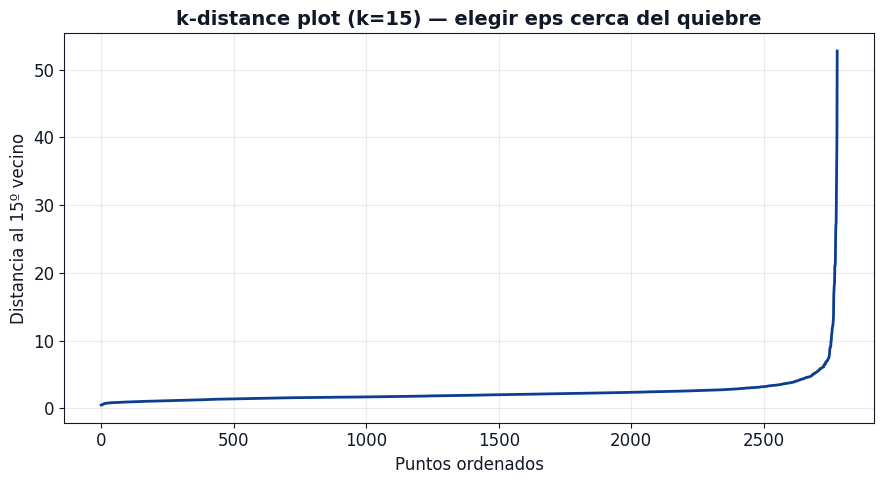


Percentiles de k-distance (copy/paste):
     kdist_value
p50     1.935799
p70     2.321357
p80     2.590105
p85     2.796610
p90     3.215812
p95     4.247329
p97     5.249015
p99     8.780369

2) GRID DBSCAN (copy/paste) — eps/min_samples → #clusters, %ruido, min_cluster, silhouette(sin ruido)
     eps  min_samples  n_clusters  noise_%  min_cluster_size  silhouette_no_noise
4.247329           10           2     1.91                14             0.610716
2.590105           15           2    10.58                52             0.425649
2.796610           28           2    10.58                38             0.420499
2.590105           20           2    11.88                41             0.440266
4.247329           15           1     2.99              2695                  NaN
4.247329           20           1     3.10              2692                  NaN
4.247329           28           1     3.24              2688                  NaN
3.215812           10           1     4.97     

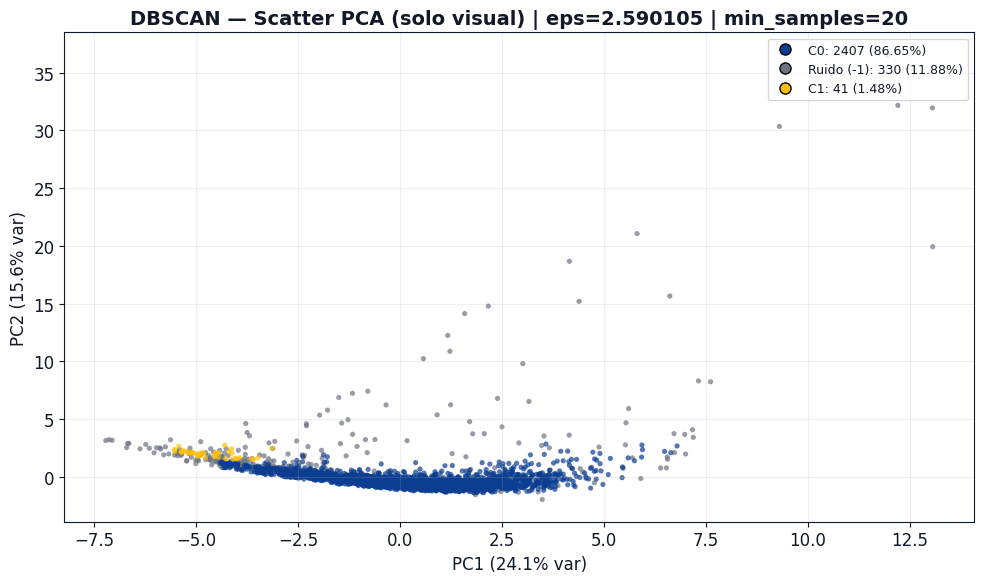

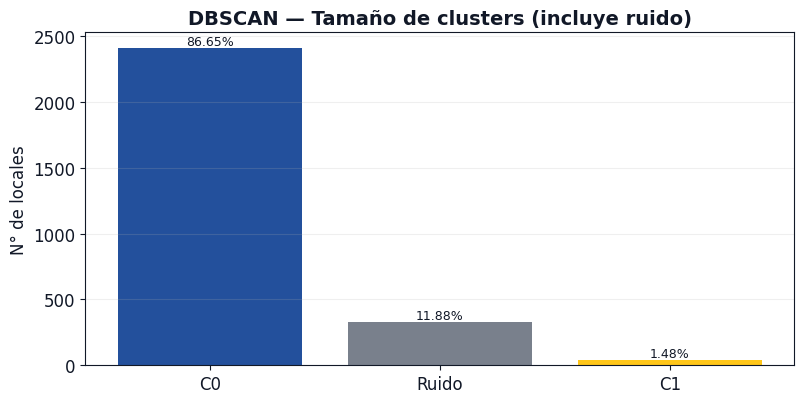


✅ Listo. Objetos en memoria: df_cluster_dbscan, dbscan_params_final, dbscan_sizes, dbscan_profile, dbscan_diff_rank


In [8]:
# =========================
# CELDA 7 — DBSCAN (tesis-friendly + copy/paste) [100% CORREGIDA]
# Requiere: X, df_cluster
# Entrega:
# 1) k-distance plot (orienta eps)
# 2) grid eps/min_samples: #clusters, %ruido, min_cluster, silhouette(sin ruido)
# 3) selección automática (explicable) + modelo final
# 4) tamaños por cluster (incluye ruido=-1)
# 5) perfil numérico por cluster (p25/p50/p75/mean) (sin ruido)
# 6) ranking variables separadoras (sin ruido)
# 7) scatter PCA 2D (solo visual) + barras tamaños
# Objetos:
# - df_cluster_dbscan, dbscan_params_final, dbscan_sizes, dbscan_profile, dbscan_diff_rank
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D

# -------------------------
# 0) Validaciones
# -------------------------
if "X" not in globals():
    raise RuntimeError("No existe 'X' en memoria. Ejecuta primero la celda que construye X (idealmente Celda 3b).")
if "df_cluster" not in globals():
    raise RuntimeError("No existe 'df_cluster' en memoria. Ejecuta primero la celda que construye df_cluster.")

# Asegurar X como numpy array (por seguridad)
X_ = np.asarray(X, dtype=float)
df_base = df_cluster.copy().replace({pd.NA: np.nan})

n = X_.shape[0]
SEED = 42

# Guardrail micro-cluster ~1% (consistente con K-Means)
MIN_CLUSTER_COUNT = int(np.ceil(n * 0.01))  # con 2778 => 28

# Colores identidad visual
PROV_BLUE   = "#0B3D91"
PROV_YELLOW = "#FFC000"
PROV_WHITE  = "#FFFFFF"
PROV_GRAY   = "#6B7280"
PROV_BLACK  = "#111827"
PROV_RED    = "#DC2626"

plt.rcParams.update({
    "figure.facecolor": PROV_WHITE,
    "axes.facecolor": PROV_WHITE,
    "axes.edgecolor": PROV_BLACK,
    "axes.labelcolor": PROV_BLACK,
    "text.color": PROV_BLACK,
    "xtick.color": PROV_BLACK,
    "ytick.color": PROV_BLACK,
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

# Colormap azul->amarillo para clusters
cmap_b2y = LinearSegmentedColormap.from_list("blue_to_yellow", [PROV_BLUE, PROV_YELLOW], N=256)

def colors_for_n(nc):
    xs = np.linspace(0.0, 1.0, max(1, nc))
    cols = [cmap_b2y(x) for x in xs]
    return ["#{0:02x}{1:02x}{2:02x}".format(int(r*255), int(g*255), int(b*255)) for r,g,b,a in cols]

print("\n" + "="*95)
print("CELDA 7 — DBSCAN (clustering por densidad) — Inputs")
print("="*95)
print("X shape:", X_.shape, "| df_cluster:", df_base.shape, "| MIN_CLUSTER_COUNT (1%):", MIN_CLUSTER_COUNT)

# -------------------------
# 1) k-distance plot (orientación para eps)
# -------------------------
MIN_SAMPLES_DEFAULT = 15
k = min(MIN_SAMPLES_DEFAULT, max(2, n - 1))  # evita error si n es pequeño

nn = NearestNeighbors(n_neighbors=k)
nn.fit(X_)
distances, _ = nn.kneighbors(X_)
kdist = np.sort(distances[:, -1])  # distancia al k-ésimo vecino

print("\n" + "="*95)
print("1) k-distance plot (para orientar eps)")
print("="*95)
print(f"Usando k (min_samples guía) = {k}. eps suele elegirse cerca del 'codo' de este gráfico.")

plt.figure(figsize=(9, 5))
plt.plot(kdist, color=PROV_BLUE, linewidth=2)
plt.title(f"k-distance plot (k={k}) — elegir eps cerca del quiebre")
plt.xlabel("Puntos ordenados")
plt.ylabel(f"Distancia al {k}º vecino")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# Percentiles para proponer eps
kdist_pct = pd.Series(kdist).quantile([0.50,0.70,0.80,0.85,0.90,0.95,0.97,0.99]).to_frame("kdist_value")
kdist_pct.index = [f"p{int(x*100)}" for x in kdist_pct.index]

print("\nPercentiles de k-distance (copy/paste):")
print(kdist_pct.to_string())

# -------------------------
# 2) Grid eps/min_samples + métricas
# -------------------------
eps_candidates = sorted(set([
    float(kdist_pct.loc["p80","kdist_value"]),
    float(kdist_pct.loc["p85","kdist_value"]),
    float(kdist_pct.loc["p90","kdist_value"]),
    float(kdist_pct.loc["p95","kdist_value"]),
]))

min_samples_candidates = sorted(set([10, 15, 20, MIN_CLUSTER_COUNT]))  # consistente con guardrail

def summarize_dbscan(labels):
    labels = np.asarray(labels)
    n_noise = int(np.sum(labels == -1))
    noise_pct = float(n_noise / len(labels) * 100.0)

    clusters = sorted([c for c in set(labels) if c != -1])
    n_clusters = len(clusters)

    vc = pd.Series(labels).value_counts()
    min_cluster = int(vc[[c for c in vc.index if c != -1]].min()) if n_clusters > 0 else 0

    # silhouette sin ruido (solo si hay >=2 clusters y suficientes puntos)
    sil = np.nan
    mask = labels != -1
    if n_clusters >= 2 and mask.sum() >= 50:
        try:
            sil = float(silhouette_score(X_[mask], labels[mask]))
        except Exception:
            sil = np.nan

    return n_clusters, noise_pct, min_cluster, sil

grid_rows = []
grid_labels = {}

print("\n" + "="*95)
print("2) GRID DBSCAN (copy/paste) — eps/min_samples → #clusters, %ruido, min_cluster, silhouette(sin ruido)")
print("="*95)

for ms in min_samples_candidates:
    for eps in eps_candidates:
        model = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1)
        labels = model.fit_predict(X_)
        grid_labels[(eps, ms)] = labels

        n_clusters, noise_pct, min_cluster, sil = summarize_dbscan(labels)

        grid_rows.append({
            "eps": round(float(eps), 6),
            "min_samples": int(ms),
            "n_clusters": int(n_clusters),
            "noise_%": round(float(noise_pct), 2),
            "min_cluster_size": int(min_cluster),
            "silhouette_no_noise": None if np.isnan(sil) else round(float(sil), 6),
        })

grid_table = pd.DataFrame(grid_rows).sort_values(["n_clusters","noise_%"], ascending=[False, True]).reset_index(drop=True)
print(grid_table.to_string(index=False))

# -------------------------
# 3) Selección automática simple (explicable)
# -------------------------
# Regla:
# - Preferir 1..10 clusters
# - ruido <= 60%
# - idealmente min_cluster_size >= MIN_CLUSTER_COUNT
# - maximizar silhouette_no_noise cuando exista
cand = grid_table.copy()
cand = cand[(cand["n_clusters"] >= 1) & (cand["n_clusters"] <= 10) & (cand["noise_%"] <= 60)].copy()

if cand.empty:
    # fallback: elegir el mejor con n_clusters>=1 aunque ruido sea alto
    cand = grid_table[grid_table["n_clusters"] >= 1].copy()

cand_sil = cand.dropna(subset=["silhouette_no_noise"]).copy()
if not cand_sil.empty:
    cand_ok = cand_sil[cand_sil["min_cluster_size"] >= MIN_CLUSTER_COUNT].copy()
    if cand_ok.empty:
        cand_ok = cand_sil.copy()
    best = cand_ok.sort_values(["silhouette_no_noise","n_clusters","noise_%"],
                               ascending=[False, True, True]).iloc[0]
else:
    # sin silhouette (1 cluster o demasiado ruido): minimizar ruido, luego maximizar clusters
    best = cand.sort_values(["noise_%","n_clusters"], ascending=[True, False]).iloc[0]

eps_final = float(best["eps"])
ms_final = int(best["min_samples"])

print("\n" + "="*95)
print("3) DBSCAN — Parámetros elegidos (automático, explicado)")
print("="*95)
print("eps_final:", eps_final, "| min_samples_final:", ms_final)
print("n_clusters:", int(best["n_clusters"]),
      "| noise_%:", float(best["noise_%"]),
      "| min_cluster_size:", int(best["min_cluster_size"]),
      "| silhouette_no_noise:", best["silhouette_no_noise"])

dbscan_params_final = {"eps": eps_final, "min_samples": ms_final}

# Entrenar modelo final
dbscan_model = DBSCAN(eps=eps_final, min_samples=ms_final, n_jobs=-1)
labels_final = dbscan_model.fit_predict(X_)

# -------------------------
# 4) Tamaños por cluster (incluye ruido=-1)
# -------------------------
vc = pd.Series(labels_final).value_counts().sort_index()
sizes = vc.rename_axis("cluster_dbscan").reset_index(name="n_locales")
sizes["share_%"] = (sizes["n_locales"] / sizes["n_locales"].sum() * 100.0).round(2)

print("\n" + "="*95)
print("4) DBSCAN — Tamaños por cluster (incluye ruido=-1) (copy/paste)")
print("="*95)
print(sizes.to_string(index=False))

dbscan_sizes = sizes.copy()

# -------------------------
# 5) Adjuntar labels a df_cluster
# -------------------------
df_cluster_dbscan = df_base.copy()
df_cluster_dbscan["cluster_dbscan"] = labels_final

# -------------------------
# 6) Perfil numérico por cluster (sin ruido por defecto)
# -------------------------
cluster_col = "cluster_dbscan"

# Auto-detect Share_UC_* para que no se pierdan
uc_cols = sorted([c for c in df_cluster_dbscan.columns if isinstance(c, str) and c.startswith("Share_UC_")])

key_vars_base = [
    "Monetary","VentaMensual_Prom","VentaMensual_Std","CV_Mensual",
    "RecencyDays","FrequencyMonths",
    "Tickets","Units",
    "SKU_Distintos","Mundos_Distintos","UC_Distintas","Equiv_Distintas",
    "ShareWeb","ShareFoco","ShareMarcaPropia",
]
key_vars = [v for v in key_vars_base if v in df_cluster_dbscan.columns] + [v for v in uc_cols if v in df_cluster_dbscan.columns]

def agg_profile(df, cols, include_noise=False):
    d = df.copy()
    if not include_noise:
        d = d[d[cluster_col] != -1].copy()
    g = d.groupby(cluster_col)[cols]
    p25 = g.quantile(0.25, numeric_only=True).add_suffix("_p25")
    p50 = g.median(numeric_only=True).add_suffix("_p50")
    p75 = g.quantile(0.75, numeric_only=True).add_suffix("_p75")
    mean = g.mean(numeric_only=True).add_suffix("_mean")
    return pd.concat([p25,p50,p75,mean], axis=1).reset_index()

profile = agg_profile(df_cluster_dbscan, key_vars, include_noise=False)

# Formateo:
money_cols = ["Monetary","VentaMensual_Prom","VentaMensual_Std"]
for base in money_cols:
    for suf in ["_p25","_p50","_p75","_mean"]:
        col = base + suf
        if col in profile.columns:
            profile[col] = profile[col] / 1_000_000.0

share_like = [c for c in key_vars if c.startswith("Share")]
for base in share_like:
    for suf in ["_p25","_p50","_p75","_mean"]:
        col = base + suf
        if col in profile.columns:
            profile[col] = profile[col] * 100.0

print("\n" + "="*95)
print("5) DBSCAN — Perfil numérico por cluster (sin ruido) (copy/paste)")
print("   Ventas: MM CLP | Shares: %")
print("="*95)
print(profile.to_string(index=False))

dbscan_profile = profile.copy()

# -------------------------
# 7) Ranking separadores (sin ruido)
# -------------------------
dfp = df_cluster_dbscan[df_cluster_dbscan[cluster_col] != -1].copy()

if dfp[cluster_col].nunique() >= 2:
    meds = dfp.groupby(cluster_col)[key_vars].median(numeric_only=True)
    spread = (meds.max(axis=0) - meds.min(axis=0)).sort_values(ascending=False)
    diff_rank = pd.DataFrame({"variable": spread.index[:20], "delta_median_max_min": spread.values[:20]})
else:
    diff_rank = pd.DataFrame({"variable": [], "delta_median_max_min": []})

print("\n" + "="*95)
print("6) DBSCAN — Top variables que más separan clusters (sin ruido) (copy/paste)")
print("="*95)
print(diff_rank.to_string(index=False))

dbscan_diff_rank = diff_rank.copy()

# -------------------------
# 8) Scatter PCA 2D (solo visual) + barras de tamaños
# -------------------------
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_)
evr = pca.explained_variance_ratio_

print("\n" + "="*95)
print("7) PCA (solo visual para scatter) — Varianza explicada")
print("="*95)
print(f"PC1: {evr[0]*100:.2f}% | PC2: {evr[1]*100:.2f}% | Total: {(evr[0]+evr[1])*100:.2f}%")

# Colores por cluster (ruido = gris)
clusters = sorted([c for c in set(labels_final) if c != -1])
palette = colors_for_n(len(clusters))
color_map = {c: palette[i] for i,c in enumerate(clusters)}
color_map[-1] = PROV_GRAY

# Scatter
fig, ax = plt.subplots(figsize=(10, 6))
for c in [-1] + clusters:
    mask = labels_final == c
    if mask.sum() == 0:
        continue
    ax.scatter(X_pca[mask,0], X_pca[mask,1], s=14, alpha=0.70,
               color=color_map[c], edgecolor="none",
               label=("Ruido (-1)" if c == -1 else f"C{c}"))

ax.set_title(f"DBSCAN — Scatter PCA (solo visual) | eps={eps_final} | min_samples={ms_final}")
ax.set_xlabel(f"PC1 ({evr[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({evr[1]*100:.1f}% var)")
ax.grid(True, alpha=0.20)

handles = []
for _, row in sizes.sort_values("n_locales", ascending=False).iterrows():
    c = int(row["cluster_dbscan"])
    name = "Ruido (-1)" if c == -1 else f"C{c}"
    handles.append(Line2D([0],[0], marker='o', color='none',
                          markerfacecolor=color_map[c], markersize=8,
                          label=f"{name}: {int(row['n_locales'])} ({row['share_%']:.2f}%)"))
ax.legend(handles=handles, loc="upper right", frameon=True, fontsize=9)
plt.tight_layout()
plt.show()

# Barras tamaños
fig, ax2 = plt.subplots(figsize=(8.2, 4.2))
s2 = sizes.sort_values("n_locales", ascending=False).reset_index(drop=True)
xs = np.arange(len(s2))
ax2.bar(xs, s2["n_locales"].values, color=[color_map[int(c)] for c in s2["cluster_dbscan"].values], alpha=0.90)
ax2.set_xticks(xs)
ax2.set_xticklabels(["Ruido" if int(c)==-1 else f"C{int(c)}" for c in s2["cluster_dbscan"].values])
ax2.set_title("DBSCAN — Tamaño de clusters (incluye ruido)")
ax2.set_ylabel("N° de locales")
ax2.grid(True, axis="y", alpha=0.20)
for i in range(len(s2)):
    ax2.text(i, s2["n_locales"].iloc[i], f"{s2['share_%'].iloc[i]:.2f}%",
             ha="center", va="bottom", fontsize=9, color=PROV_BLACK)
plt.tight_layout()
plt.show()

print("\n✅ Listo. Objetos en memoria: df_cluster_dbscan, dbscan_params_final, dbscan_sizes, dbscan_profile, dbscan_diff_rank")

## Celda 8 — Dataset supervisado Local–SKU (`df_ls`) para recomendación — Documentación FINAL (actualizada con resultados reales)

### 0) Objetivo
Construir el dataset supervisado **a nivel Local–SKU** para un recomendador basado en clasificación/ranking, donde:
- Cada fila representa un par **(IDLOCALCODIGO, IDINTERNOCODIGO)** que **tuvo actividad en la ventana lookback**.
- Se crean **features** del historial reciente (90 días).
- Se crean **targets** de recompra en el futuro:
  - `y_week`: compra en los próximos 7 días.
  - `y_month`: compra en los próximos 30 días.
- Se agrega **contexto del local** mediante `cluster_kmeans`.

Este dataset deja listo el insumo para entrenar modelos (ej. Random Forest/GBM/logística) y evaluar recomendación Top‑K por local.

---

### 1) Inputs requeridos
Requiere en memoria:
- `df`: transaccional enriquecido día × local × SKU (con ventas, flags, atributos de producto).
- `df_cluster_kmeans`: dataset por local con la columna `cluster_kmeans`.

Columnas mínimas requeridas en `df`:
- Identificadores: `IDLOCALCODIGO`, `IDINTERNOCODIGO`
- Fecha: `Fecha`
- Medidas: `VENTAFINALVALOR`, `VENTAFINALUNIDADES`
- Flags/canal: `Canal_Venta`, `EsFoco`, `EsMarcaPropia`
- Atributos de producto: `UC_FCV`, `Mundo`, `Laboratorio`, `Marca`, `EquivalenciaComercial`

---

### 2) Parámetros temporales usados (resultado real de tu corrida)
- `max_fecha`: **2026-04-30**
- `HORIZON_MONTH`: 30 días → `fecha_corte = max_fecha - 30d` = **2026-03-31**
- `LOOKBACK_DAYS`: 90 días

Ventanas definidas:
- **Lookback (histórico features):** 2025-12-31 → 2026-03-31  
- **Futuro para targets (y_month):** 2026-04-01 → 2026-04-30  
- **Futuro para y_week:** 2026-04-01 → 2026-04-07  

Volúmenes:
- `df` filas (transaccional): **9,154,156**
- `hist` filas (lookback): **2,125,653**
- `future` filas (futuro 30d): **718,115**

---

### 3) Construcción del set de candidatos (qué pares Local–SKU aparecen)
La celda construye `df_ls` **solo para los pares Local–SKU que existen en la ventana lookback**.  
Es decir:
- Si un local **nunca compró** un SKU en los últimos 90 días, ese par **no aparece** en `df_ls`.
- Esto funciona como **candidate generation** implícita (recomendación sobre SKUs “con historia reciente”).

> Implicación: El modelo resultante es muy adecuado para “reorden/repurchase” (recompras) y pedido sugerido basado en historial reciente.

---

### 4) Features creadas (desde `hist`, agregadas por Local–SKU)
Se agregan por `(IDLOCALCODIGO, IDINTERNOCODIGO)`:

#### 4.1 Intensidad y valor
- `f_freq_days`: # de días distintos con compra del SKU en el local (90d).
- `f_units`: unidades totales (90d).
- `f_value`: valor total (90d).
- `f_tickets`: # de registros/ocurrencias (proxy de tickets).

#### 4.2 Recencia
- `f_recency_days`: días desde la última compra del SKU en el local respecto a `fecha_corte` (más chico = más reciente).

#### 4.3 Shares estratégicos (en valor)
Se calcula valor condicionado y luego proporción sobre `f_value`:
- `f_share_web`: share del valor por canal Web.
- `f_share_foco`: share del valor en productos foco.
- `f_share_mp`: share del valor en marca propia.

#### 4.4 Precio promedio
- `f_price_avg`: aproximación de precio medio = `f_value / f_units` (si unidades > 0, si no 0).

---

### 5) Atributos de producto (por SKU)
Para añadir contexto de producto sin explotar dimensionalidad por Local–SKU, se calculan atributos **por SKU** usando la **moda** en el lookback:

- `UC_FCV`, `Mundo`, `Laboratorio`, `Marca`, `EquivalenciaComercial`

Esto:
- reduce ruido (atributos “estables”),
- evita recalcular atributos por cada local‑sku,
- y mantiene un esquema de features mixto: numéricas + categóricas.

---

### 6) Targets (desde `future`)
Se asigna target 1 si existe al menos una compra del par Local–SKU en el futuro definido:

- `y_week = 1` si compra en 2026-04-01 → 2026-04-07
- `y_month = 1` si compra en 2026-04-01 → 2026-04-30

Si no aparece en el futuro, se asigna 0.

---

### 7) Contexto del local: `cluster_kmeans`
Se hace merge por `IDLOCALCODIGO` desde `df_cluster_kmeans`:
- `cluster_kmeans` queda como feature contextual del cliente (segmentación).

> Nota metodológica (potencial leakage):
> - `df_ls` define `fecha_corte` para crear targets futuros.
> - Si `cluster_kmeans` fue calculado con datos que incluyen fechas posteriores a `fecha_corte` (por ejemplo hasta `max_fecha`), puede existir fuga de información.
> - Dos soluciones defendibles:
>   1) recalcular `cluster_kmeans` usando solo transacciones `<= fecha_corte`, o
>   2) mantenerlo y declararlo como limitación, o directamente excluirlo como feature en el modelo supervisado.

---

### 8) Resultado final (`df_ls`) — métricas reales
**Dimensión**
- Filas: **1,198,797**
- Columnas: **19**
- Locales únicos: **2,280**
- SKUs únicos: **9,822**

**Balance de clases**
- `y_week` positivos: **89,790**  → tasa **7.49%**
- `y_month` positivos: **323,202** → tasa **26.96%**

**Columnas finales**
`['IDLOCALCODIGO', 'IDINTERNOCODIGO', 'f_freq_days', 'f_units', 'f_value', 'f_tickets', 'f_recency_days', 'f_share_web', 'f_share_foco', 'f_share_mp', 'f_price_avg', 'UC_FCV', 'Mundo', 'Laboratorio', 'Marca', 'EquivalenciaComercial', 'y_week', 'y_month', 'cluster_kmeans']`

**Esquema y nulos**
- Todas las columnas tienen **0% nulos** en esta corrida (incluyendo `cluster_kmeans`).
- Tipos: numéricas (int/float) + categóricas (object) + targets (int).

**Distribución de cluster_kmeans (por filas Local–SKU)**
- Cluster 1: **1,115,910** filas (**93.09%**)
- Cluster 0: **82,887** filas (**6.91%**)

Interpretación: la mayoría de pares Local–SKU (con historia lookback) pertenecen a locales del cluster 1, consistente con que ese cluster concentra los locales más activos/intensivos.

---

### 9) Gráficos generados (diagnóstico rápido)
La celda incluye:
- barras de balance para `y_week` y `y_month`,
- histograma de `f_recency_days` (con cap p99) para verificar dispersión de recencia.

---

### 10) Outputs listos para siguientes celdas
Quedan en memoria:
- `df_ls` listo para:
  - split train/test por locales,
  - entrenamiento de modelo supervisado,
  - evaluación tipo recomendación (Precision@K, Recall@K, HitRate@K).

FIN.



CELDA 8 — DATASET SUPERVISADO Local–SKU (df_ls) — RESUMEN (copy/paste)
df (transaccional) filas: 9,154,156
max_fecha: 2026-04-30 | fecha_corte: 2026-03-31
LOOKBACK_DAYS=90 | HORIZON_WEEK=7 | HORIZON_MONTH=30
lookback: 2025-12-31 → 2026-03-31 | hist filas: 2,125,653
future:   2026-04-01 → 2026-04-30 | future filas: 718,115

Resultado df_ls:
- filas: 1,198,797 | cols: 19
- locales únicos: 2,280 | skus únicos: 9,822
- positivos y_week: 89,790  (tasa 7.49%)
- positivos y_month: 323,202 (tasa 26.96%)

COLUMNAS df_ls (copy/paste)
['IDLOCALCODIGO', 'IDINTERNOCODIGO', 'f_freq_days', 'f_units', 'f_value', 'f_tickets', 'f_recency_days', 'f_share_web', 'f_share_foco', 'f_share_mp', 'f_price_avg', 'UC_FCV', 'Mundo', 'Laboratorio', 'Marca', 'EquivalenciaComercial', 'y_week', 'y_month', 'cluster_kmeans']

ESQUEMA df_ls (dtype y %nulos) (copy/paste)
                  col   dtype  null_%
        IDLOCALCODIGO   int64     0.0
      IDINTERNOCODIGO   int64     0.0
          f_freq_days   int64     0.0


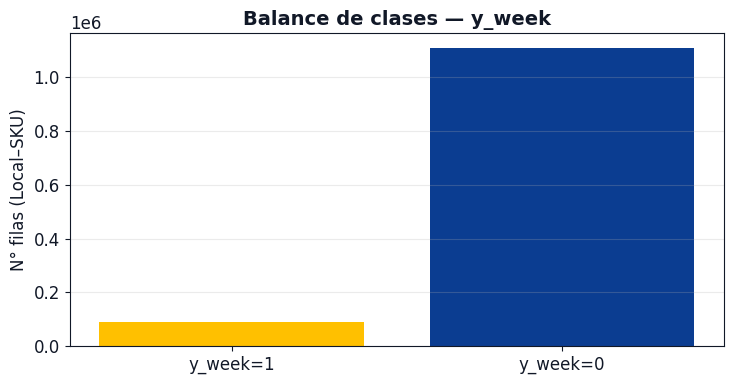

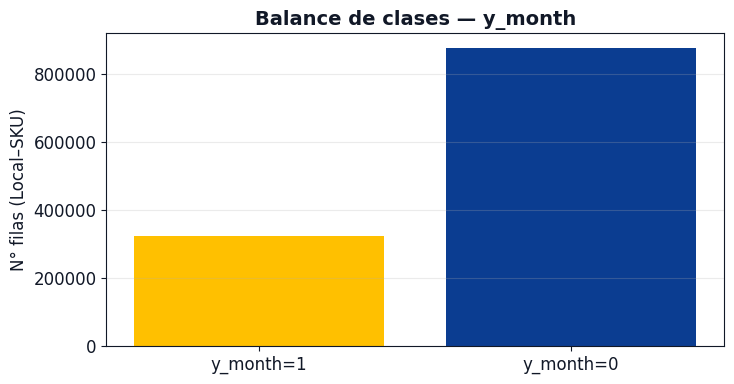

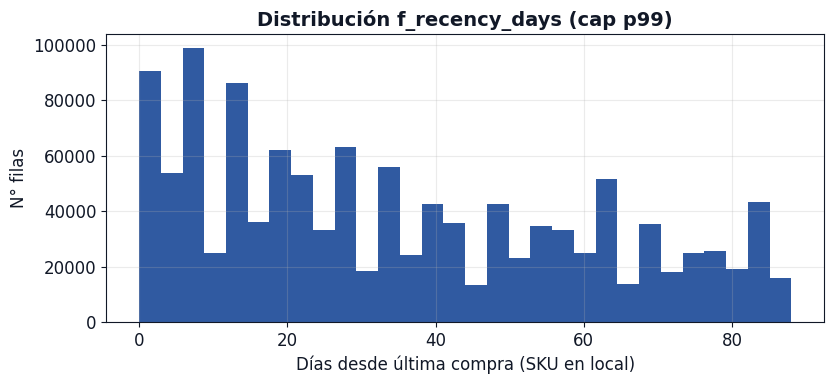


✅ OK | df_ls listo en memoria (Local–SKU).


,IDLOCALCODIGO,IDINTERNOCODIGO,f_freq_days,f_units,f_value,f_tickets,f_recency_days,f_share_web,f_share_foco,f_share_mp,f_price_avg,UC_FCV,Mundo,Laboratorio,Marca,EquivalenciaComercial,y_week,y_month,cluster_kmeans
0,6354008,1006,3,7.0,77795.0,3,0,0.0,0.0,0.0,11113.571429,FARMA,ETICO,DEUTSCHE PHARMA,MORELIN,1080,0,0,1
1,6354013,1006,5,7.0,76640.0,5,0,0.0,0.0,0.0,10948.571429,FARMA,ETICO,DEUTSCHE PHARMA,MORELIN,1080,0,0,1
2,6354027,1006,2,3.0,34200.0,2,49,0.0,0.0,0.0,11400.000000,FARMA,ETICO,DEUTSCHE PHARMA,MORELIN,1080,0,0,1
3,8311301,1006,3,13.0,145345.0,3,19,0.0,0.0,0.0,11180.384615,FARMA,ETICO,DEUTSCHE PHARMA,MORELIN,1080,0,0,1
4,8444205,1006,1,1.0,11785.0,1,64,0.0,0.0,0.0,11785.000000,FARMA,ETICO,DEUTSCHE PHARMA,MORELIN,1080,0,0,1


In [9]:
# =========================
# CELDA 8 — DATASET SUPERVISADO Local–SKU (df_ls) PARA RECOMENDACIÓN [100% CORREGIDA]
# - Features en ventana lookback (90 días)
# - Targets y_week (7d) y y_month (30d) en ventana futura
# - Agrega contexto del cliente: cluster_kmeans (desde df_cluster_kmeans)
# - Excluye SKU dummy -99999 (si existe)
# - Sin entities HTML, robusta a tipos y nulos
# - Imprime resumen + columnas + esquema + distribución de cluster_kmeans + gráficos básicos
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# 0) Validaciones
# -------------------------
if "df" not in globals():
    raise RuntimeError("No existe 'df' en memoria. Ejecuta primero la celda que construye df (transaccional).")

if "df_cluster_kmeans" not in globals():
    raise RuntimeError("No existe 'df_cluster_kmeans' en memoria. Ejecuta primero K-Means (y crea df_cluster_kmeans).")

dfx = df.copy().replace({pd.NA: np.nan})
dfk = df_cluster_kmeans.copy().replace({pd.NA: np.nan})

required = [
    "IDLOCALCODIGO","IDINTERNOCODIGO","Fecha","VENTAFINALVALOR","VENTAFINALUNIDADES",
    "Canal_Venta","EsFoco","EsMarcaPropia",
    "UC_FCV","Mundo","Laboratorio","Marca","EquivalenciaComercial"
]
missing = [c for c in required if c not in dfx.columns]
if missing:
    raise RuntimeError(f"Faltan columnas en df para construir df_ls: {missing}")

if "IDLOCALCODIGO" not in dfk.columns or "cluster_kmeans" not in dfk.columns:
    raise RuntimeError("df_cluster_kmeans debe contener: IDLOCALCODIGO y cluster_kmeans.")

# Tipos
dfx["Fecha"] = pd.to_datetime(dfx["Fecha"], errors="coerce")
dfx = dfx.dropna(subset=["Fecha"]).copy()

# -------------------------
# 0.b) Filtro de seguridad: excluir SKU dummy -99999 si aparece
# -------------------------
sku_num = pd.to_numeric(dfx["IDINTERNOCODIGO"], errors="coerce")
if (sku_num == -99999).any():
    dfx = dfx[sku_num.ne(-99999)].copy()
    print("OK | Se excluyó IDINTERNOCODIGO = -99999 del transaccional para df_ls.")

# -------------------------
# 1) Parámetros de ventanas
# -------------------------
LOOKBACK_DAYS = 90
HORIZON_WEEK  = 7
HORIZON_MONTH = 30

max_fecha = dfx["Fecha"].max().normalize()
fecha_corte = (max_fecha - pd.Timedelta(days=HORIZON_MONTH)).normalize()

lookback_start = (fecha_corte - pd.Timedelta(days=LOOKBACK_DAYS)).normalize()
lookback_end   = fecha_corte.normalize()

future_start     = (fecha_corte + pd.Timedelta(days=1)).normalize()
future_end_week  = (fecha_corte + pd.Timedelta(days=HORIZON_WEEK)).normalize()
future_end_month = (fecha_corte + pd.Timedelta(days=HORIZON_MONTH)).normalize()

# -------------------------
# 2) Filtrar ventanas (hist y futuro)
# -------------------------
hist = dfx[(dfx["Fecha"] >= lookback_start) & (dfx["Fecha"] <= lookback_end)].copy()
future = dfx[(dfx["Fecha"] >= future_start) & (dfx["Fecha"] <= future_end_month)].copy()

# Si hist queda vacío, no se puede construir df_ls
if hist.empty:
    raise RuntimeError("La ventana hist (lookback) quedó vacía. Revisa fechas y parámetros.")

# -------------------------
# 3) Construcción de FEATURES (Local–SKU) desde hist
# -------------------------
hist["val_total"]   = pd.to_numeric(hist["VENTAFINALVALOR"], errors="coerce").fillna(0.0)
hist["units_total"] = pd.to_numeric(hist["VENTAFINALUNIDADES"], errors="coerce").fillna(0.0)

# Flags de condición
is_web = hist["Canal_Venta"].astype(str).str.upper().eq("WEB").astype(float)
is_foco = pd.to_numeric(hist["EsFoco"], errors="coerce").fillna(0.0).astype(float)
is_mp   = pd.to_numeric(hist["EsMarcaPropia"], errors="coerce").fillna(0.0).astype(float)

hist["val_web"]  = hist["val_total"] * is_web
hist["val_foco"] = hist["val_total"] * is_foco
hist["val_mp"]   = hist["val_total"] * is_mp

grp = hist.groupby(["IDLOCALCODIGO","IDINTERNOCODIGO"], sort=False)

feat = grp.agg(
    last_date=("Fecha","max"),
    f_freq_days=("Fecha", pd.Series.nunique),
    f_units=("units_total","sum"),
    f_value=("val_total","sum"),
    f_tickets=("val_total","size"),
    f_value_web=("val_web","sum"),
    f_value_foco=("val_foco","sum"),
    f_value_mp=("val_mp","sum"),
).reset_index()

feat["f_recency_days"] = (fecha_corte - feat["last_date"]).dt.days.astype(int)
feat.drop(columns=["last_date"], inplace=True)

feat["f_share_web"]  = np.where(feat["f_value"] > 0, feat["f_value_web"]  / feat["f_value"], 0.0)
feat["f_share_foco"] = np.where(feat["f_value"] > 0, feat["f_value_foco"] / feat["f_value"], 0.0)
feat["f_share_mp"]   = np.where(feat["f_value"] > 0, feat["f_value_mp"]   / feat["f_value"], 0.0)
feat["f_price_avg"]  = np.where(feat["f_units"] > 0, feat["f_value"]      / feat["f_units"], 0.0)

feat.drop(columns=["f_value_web","f_value_foco","f_value_mp"], inplace=True)

# -------------------------
# 4) Atributos de producto (por SKU) desde hist: moda (most frequent)
# -------------------------
prod_cols = ["UC_FCV","Mundo","Laboratorio","Marca","EquivalenciaComercial"]

def mode_safe(s):
    s = s.dropna()
    if s.empty:
        return np.nan
    return s.value_counts().index[0]

sku_attr = (hist.groupby("IDINTERNOCODIGO", sort=False)[prod_cols]
              .agg(mode_safe)
              .reset_index())

feat = feat.merge(sku_attr, on="IDINTERNOCODIGO", how="left")

# -------------------------
# 5) Targets (y_week, y_month) desde future
# -------------------------
# y_month: compra en [future_start, future_end_month]
future_pairs_month = (future.groupby(["IDLOCALCODIGO","IDINTERNOCODIGO"], sort=False)
                      .size().reset_index(name="n"))
future_pairs_month["y_month"] = 1
future_pairs_month = future_pairs_month[["IDLOCALCODIGO","IDINTERNOCODIGO","y_month"]]

# y_week: compra en [future_start, future_end_week]
future_week = future[future["Fecha"] <= future_end_week].copy()
future_pairs_week = (future_week.groupby(["IDLOCALCODIGO","IDINTERNOCODIGO"], sort=False)
                     .size().reset_index(name="n"))
future_pairs_week["y_week"] = 1
future_pairs_week = future_pairs_week[["IDLOCALCODIGO","IDINTERNOCODIGO","y_week"]]

df_ls = feat.merge(future_pairs_week, on=["IDLOCALCODIGO","IDINTERNOCODIGO"], how="left")
df_ls = df_ls.merge(future_pairs_month, on=["IDLOCALCODIGO","IDINTERNOCODIGO"], how="left")

df_ls["y_week"]  = df_ls["y_week"].fillna(0).astype(int)
df_ls["y_month"] = df_ls["y_month"].fillna(0).astype(int)

# -------------------------
# 6) Contexto cliente: cluster_kmeans
# -------------------------
df_ls = df_ls.merge(
    dfk[["IDLOCALCODIGO","cluster_kmeans"]].drop_duplicates(),
    on="IDLOCALCODIGO",
    how="left"
)

# -------------------------
# 7) Métricas finales (copy/paste)
# -------------------------
n_df = int(len(dfx))
n_hist = int(len(hist))
n_future = int(len(future))

n_df_ls = int(len(df_ls))
n_loc_df_ls = int(df_ls["IDLOCALCODIGO"].nunique())
n_sku_df_ls = int(df_ls["IDINTERNOCODIGO"].nunique())

pos_week  = int(df_ls["y_week"].sum())
pos_month = int(df_ls["y_month"].sum())
rate_week  = float(pos_week / n_df_ls * 100.0) if n_df_ls else 0.0
rate_month = float(pos_month / n_df_ls * 100.0) if n_df_ls else 0.0

print("\n" + "="*95)
print("CELDA 8 — DATASET SUPERVISADO Local–SKU (df_ls) — RESUMEN (copy/paste)")
print("="*95)
print(f"df (transaccional) filas: {n_df:,}")
print(f"max_fecha: {max_fecha.date()} | fecha_corte: {fecha_corte.date()}")
print(f"LOOKBACK_DAYS={LOOKBACK_DAYS} | HORIZON_WEEK={HORIZON_WEEK} | HORIZON_MONTH={HORIZON_MONTH}")
print(f"lookback: {lookback_start.date()} → {lookback_end.date()} | hist filas: {n_hist:,}")
print(f"future:   {future_start.date()} → {future_end_month.date()} | future filas: {n_future:,}")

print("\nResultado df_ls:")
print(f"- filas: {n_df_ls:,} | cols: {df_ls.shape[1]}")
print(f"- locales únicos: {n_loc_df_ls:,} | skus únicos: {n_sku_df_ls:,}")
print(f"- positivos y_week: {pos_week:,}  (tasa {rate_week:.2f}%)")
print(f"- positivos y_month: {pos_month:,} (tasa {rate_month:.2f}%)")

print("\n" + "="*95)
print("COLUMNAS df_ls (copy/paste)")
print("="*95)
print(df_ls.columns.tolist())

# Esquema (dtype + % nulos)
schema_df = pd.DataFrame([{
    "col": c,
    "dtype": str(df_ls[c].dtype),
    "null_%": round(float(df_ls[c].isna().mean() * 100.0), 3)
} for c in df_ls.columns])

print("\n" + "="*95)
print("ESQUEMA df_ls (dtype y %nulos) (copy/paste)")
print("="*95)
print(schema_df.to_string(index=False))

# Distribución de cluster_kmeans en df_ls (por pares local-sku)
cl_tab = (df_ls["cluster_kmeans"].value_counts(dropna=False)
          .rename_axis("cluster_kmeans").reset_index(name="n_rows"))
cl_tab["share_%"] = (cl_tab["n_rows"] / cl_tab["n_rows"].sum() * 100.0).round(2)

print("\n" + "="*95)
print("DISTRIBUCIÓN cluster_kmeans EN df_ls (por filas Local–SKU) (copy/paste)")
print("="*95)
print(cl_tab.to_string(index=False))

# -------------------------
# 8) Gráficos básicos
# -------------------------
plt.figure(figsize=(7.5,4))
plt.bar(["y_week=1","y_week=0"], [pos_week, n_df_ls-pos_week], color=[PROV_YELLOW, PROV_BLUE])
plt.title("Balance de clases — y_week")
plt.ylabel("N° filas (Local–SKU)")
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7.5,4))
plt.bar(["y_month=1","y_month=0"], [pos_month, n_df_ls-pos_month], color=[PROV_YELLOW, PROV_BLUE])
plt.title("Balance de clases — y_month")
plt.ylabel("N° filas (Local–SKU)")
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

cap = df_ls["f_recency_days"].quantile(0.99)
plt.figure(figsize=(8.5,4))
plt.hist(df_ls["f_recency_days"].clip(upper=cap), bins=30, color=PROV_BLUE, alpha=0.85)
plt.title("Distribución f_recency_days (cap p99)")
plt.xlabel("Días desde última compra (SKU en local)")
plt.ylabel("N° filas")
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# -------------------------
# 9) Guardar objeto final
# -------------------------
print("\n✅ OK | df_ls listo en memoria (Local–SKU).")
df_ls.head()

## Celda 9 — Random Forest para “pedido sugerido” (semanal + mensual) — Documentación FINAL (con resultados reales)

### 0) Objetivo
Entrenar y evaluar un **Random Forest** que predice la probabilidad de recompra de un SKU por local, y usar esa probabilidad como **score** para ordenar SKUs dentro de cada local y generar un **Top‑K** (pedido sugerido).  
Esta celda entrena **dos horizontes** usando el **mismo split por locales**:
- **Semanal:** `y_week` (7 días)
- **Mensual:** `y_month` (30 días)

---

### 1) Datos de entrada
Se utiliza `df_ls` (Local–SKU) generado en la Celda 8.

**Base (común para ambos targets)**
- Filas: **1,198,797**
- Locales: **2,280**
- SKUs: **9,822**
- Positivos:
  - `y_week`: **89,790** (tasa **7.490%**)
  - `y_month`: **323,202** (tasa **26.961%**)

**Features**
- Numéricas (9):
  - `f_recency_days`, `f_freq_days`, `f_units`, `f_value`, `f_tickets`,
  - `f_share_web`, `f_share_foco`, `f_share_mp`, `f_price_avg`
- Categóricas (3, One‑Hot sparse):
  - `UC_FCV`, `Mundo`, `cluster_kmeans`

**Filtros/limpieza**
- Se excluye SKU dummy `IDINTERNOCODIGO = -99999` (seguridad).
- Numéricas a `float32` (RAM).
- Categóricas a `object` + imputación con “NA”.

---

### 2) Split Train/Test (común y justo) — por LOCALES
Para evitar fuga por identidad (mismo local en train y test), se divide por locales (80/20), igual para y_week y y_month:

- Train:
  - Locales: **1,824**
  - Filas: **956,255**
- Test:
  - Locales: **456**
  - Filas: **242,542**

Tasas por target (en este split):
- `y_week`: train **7.518%**, test **7.379%**
- `y_month`: train **26.815%**, test **27.534%**

---

### 3) Control de memoria: Downsampling de negativos por local (solo TRAIN)
Para evitar MemoryError y reducir tiempo:
- Se mantienen **todos los positivos**
- Se muestrean negativos por local con tope:
  - `MAX_NEG_PER_LOCAL = 80`

Esto reduce filas de entrenamiento y acelera Random Forest.

**Resultado real del muestreo**
- Para `y_week`:
  - Train original: **956,255**
  - Train muestreado: **207,274**
  - Positivos: **71,893**
  - Tasa muestreada: **34.685%**
- Para `y_month`:
  - Train original: **956,255**
  - Train muestreado: **390,919**
  - Positivos: **256,421**
  - Tasa muestreada: **65.594%**

**Nota metodológica importante**
Este muestreo cambia la prevalencia de clase en train (score puede no ser “probabilidad calibrada”), pero es válido y práctico para **ranking Top‑K**. Si se requiere calibración de probabilidades, se puede calibrar posteriormente (no es requisito para ranking).

---

### 4) Preprocesamiento (SPARSE)
Se usa `ColumnTransformer` con salida sparse para no explotar RAM:

- Numéricas:
  - `SimpleImputer(strategy="median")`
- Categóricas:
  - `SimpleImputer(strategy="most_frequent")`
  - `OneHotEncoder(handle_unknown="ignore", sparse=True)`

**Matrices reales**
- `X_test` (ambos targets): **(242,542, 33)** CSR
- `X_train`:
  - `y_week`: **(207,274, 33)**
  - `y_month`: **(390,919, 33)**

---

### 5) Modelo: Random Forest (hiperparámetros reales)
Configuración usada en ambos targets:

- `n_estimators = 140`
- `max_depth = 18`
- `max_features = "sqrt"`
- `min_samples_leaf = 10`
- `min_samples_split = 20`
- `bootstrap = True`
- `class_weight = "balanced_subsample"`
- `n_jobs = -1`
- `random_state = 42`

---

### 6) Scoring en test (por chunks)
Para evitar picos de RAM al hacer `predict_proba`, el score se calcula por bloques:
- `chunk_size = 200,000`

Se agrega al test:
- `score = P(target=1 | features)`

---

### 7) Métricas globales (muestra)
Para acelerar, AUC y PR‑AUC se calculan en una muestra aleatoria de test (hasta 200k filas).

**Resultados reales**
- `y_week`:
  - AUC (ROC): **0.7076**
  - PR‑AUC: **0.2039**
- `y_month`:
  - AUC (ROC): **0.7199**
  - PR‑AUC: **0.5266**

**Lectura**
- Mensual es más “predecible” (más señal y menos desbalance extremo).
- Semanal es más difícil (positivos ~7%), por eso PR‑AUC cae.

---

### 8) Métricas de recomendación (Top‑K por local)
Evaluación como recomendador:
1) ordenar SKUs por `score` dentro de cada local
2) tomar Top‑K
3) medir aciertos contra el target del horizonte

Se reporta:
- Precision@K_mean
- Recall@K_mean (solo locales con positivos)
- HitRate@K_mean
- % locales con positivos en test

#### 8.1 Resultados `y_week` (semanal)
- % locales con positivos en test: **70.394737%**

| K  | Precision@K_mean | Recall@K_mean (solo locales con positivos) | HitRate@K_mean |
|----|------------------:|-------------------------------------------:|---------------:|
| 10 | 0.197149 | 0.091417 | 0.557018 |
| 20 | 0.178509 | 0.152244 | 0.611842 |
| 50 | 0.147588 | 0.273210 | 0.664474 |

Interpretación:
- En semanal, el modelo logra ~2 aciertos promedio en Top‑10 (precision ~0.20).
- HitRate@10 ~0.56: en ~56% de locales, al menos 1 SKU del Top‑10 se compra esa semana.

#### 8.2 Resultados `y_month` (mensual)
- % locales con positivos en test: **88.815789%**

| K  | Precision@K_mean | Recall@K_mean (solo locales con positivos) | HitRate@K_mean |
|----|------------------:|-------------------------------------------:|---------------:|
| 10 | 0.516228 | 0.099921 | 0.833333 |
| 20 | 0.486075 | 0.170649 | 0.864035 |
| 50 | 0.433070 | 0.295446 | 0.877193 |

Interpretación:
- En mensual, el modelo es fuerte: ~5/10 aciertos promedio en Top‑10.
- HitRate@10 ~0.83: en ~83% de locales, al menos 1 recomendación del Top‑10 fue correcta.

---

### 9) Resumen global (copy/paste)
 target   AUC_ROC_sample  PR_AUC_sample  train_rows  test_rows  train_rate_%  test_rate_%  X_train_shape   X_test_shape   train_sampled_rows  train_sampled_rate_%
 y_week         0.707624       0.203887     956255     242542      7.518183     7.378928   (207274, 33)  (242542, 33)          207274              34.685006
 y_month        0.719895       0.526566     956255     242542     26.815128    27.533788   (390919, 33)  (242542, 33)          390919              65.594407

---

### 10) Outputs (resultados disponibles en memoria)
Sí: los resultados quedan disponibles para análisis posterior y para generar pedidos sugeridos.

Objetos guardados:
- `model_rf` (dict): modelo RF por target (`y_week`, `y_month`)
- `preprocess_rf` (dict): preprocesamiento por target
- `rank_metrics_rf` (dict): tabla Top‑K por target
- `global_metrics_rf` (DataFrame): resumen AUC/AP + shapes + tasas
- `test_scored_rf` (dict): `test` con columna `score` por target (para ranking por local)

Esto permite:
- extraer recomendaciones Top‑K por local,
- comparar RF vs Logit por horizonte,
- y construir el “pedido sugerido” final con reglas de negocio.

---

### 11) Nota metodológica (leakage potencial)
`cluster_kmeans` se usa como feature. Si el clustering se calculó con datos posteriores a la `fecha_corte` usada para targets, puede haber fuga de información.  
Opciones:
1) recalcular `cluster_kmeans` con datos `<= fecha_corte`, o
2) excluir `cluster_kmeans` del set de features supervisadas.

---

### 12) Conclusión
Con este set de features y control de memoria, Random Forest entrega un ranking sólido:
- Para mensual: métricas Top‑K altas (Precision@10 ~0.52, HitRate@10 ~0.83).
- Para semanal: desempeño más bajo pero útil (Precision@10 ~0.20, HitRate@10 ~0.56), consistente con la mayor dificultad del horizonte de 7 días.

FIN.

OK | Dataset base listo
Filas: 1198797 | Locales: 2280 | SKUs: 9822
Target y_week | positivos: 89,790 | tasa: 7.490%
Target y_month | positivos: 323,202 | tasa: 26.961%
Num feats: 9 | Cat feats: 3 ['UC_FCV', 'Mundo', 'cluster_kmeans']

OK | Split por locales (común)
Locales train: 1824 | filas train: 956255
Locales test : 456 | filas test : 242542

CELDA 9 — RANDOM FOREST | Target=y_week
Train filas: 956255 | tasa: 7.518 %
Test  filas: 242542 | tasa: 7.379 %

OK | Downsampling
Train original: 956255 | Train sampled: 207274 | Positivos: 71893 | tasa: 34.685 %

OK | Matrices listas (sparse)
X_train: (207274, 33) | X_test: (242542, 33)

OK | RandomForest entrenado | n_estimators: 140

=== Métricas globales (muestra) ===
AUC (ROC): 0.7076
Average Precision (PR-AUC): 0.2039

=== Métricas Top-K (test, por local) ===


,K,Precision@K_mean,Recall@K_mean_(solo_locales_con_positivos),HitRate@K_mean,%_locales_con_positivos_en_test
0,10,0.197149,0.091417,0.557018,70.394737
1,20,0.178509,0.152244,0.611842,70.394737
2,50,0.147588,0.273210,0.664474,70.394737


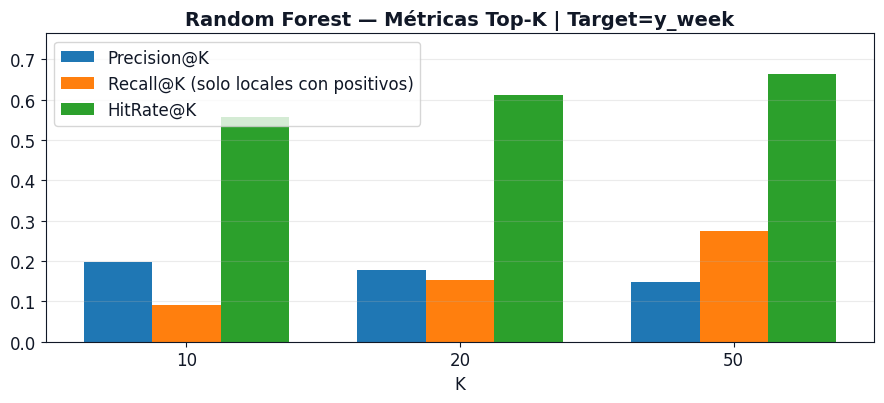


CELDA 9 — RANDOM FOREST | Target=y_month
Train filas: 956255 | tasa: 26.815 %
Test  filas: 242542 | tasa: 27.534 %

OK | Downsampling
Train original: 956255 | Train sampled: 390919 | Positivos: 256421 | tasa: 65.594 %

OK | Matrices listas (sparse)
X_train: (390919, 33) | X_test: (242542, 33)

OK | RandomForest entrenado | n_estimators: 140

=== Métricas globales (muestra) ===
AUC (ROC): 0.7199
Average Precision (PR-AUC): 0.5266

=== Métricas Top-K (test, por local) ===


,K,Precision@K_mean,Recall@K_mean_(solo_locales_con_positivos),HitRate@K_mean,%_locales_con_positivos_en_test
0,10,0.516228,0.099921,0.833333,88.815789
1,20,0.486075,0.170649,0.864035,88.815789
2,50,0.433070,0.295446,0.877193,88.815789


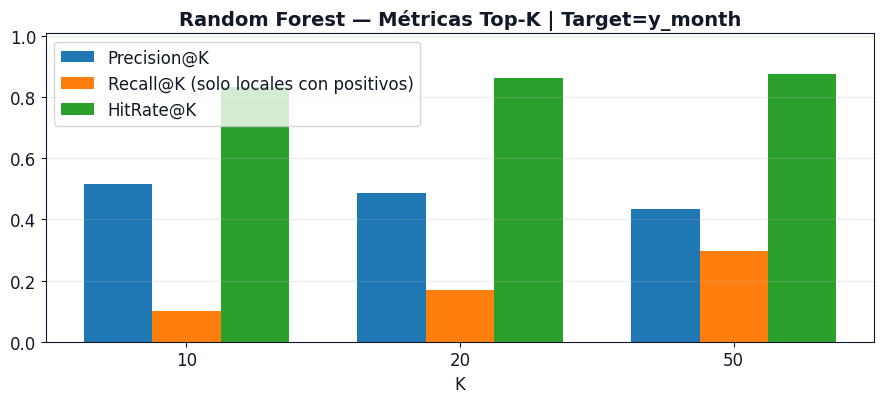


RESUMEN GLOBAL RF (copy/paste)
 target  AUC_ROC_sample  PR_AUC_sample  train_rows  test_rows  train_rate_%  test_rate_% X_train_shape X_test_shape  train_sampled_rows  train_sampled_rate_%
 y_week        0.707624       0.203887      956255     242542      7.518183     7.378928  (207274, 33) (242542, 33)              207274             34.685006
y_month        0.719895       0.526566      956255     242542     26.815128    27.533788  (390919, 33) (242542, 33)              390919             65.594407


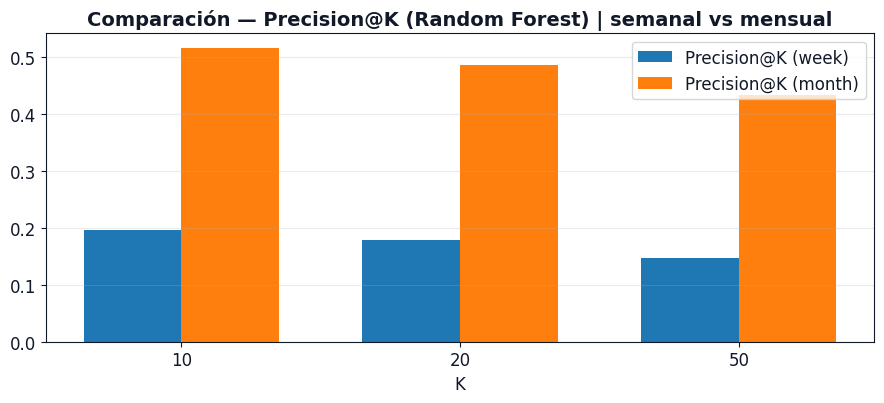

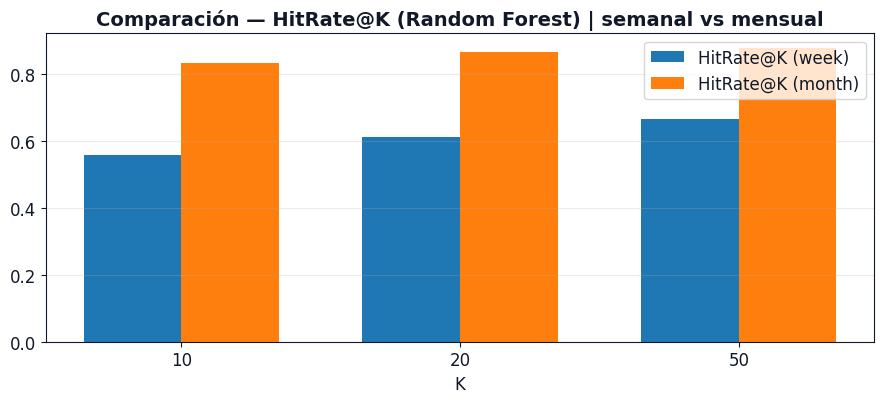


✅ OK | Objetos en memoria: model_rf (dict), preprocess_rf (dict), rank_metrics_rf (dict), global_metrics_rf, test_scored_rf (dict)


In [14]:
# =========================
# CELDA 9 — Random Forest (pedido sugerido) SEMANAL + MENSUAL (y_week + y_month)
# - Usa df_ls
# - Split por LOCALES (común, 80/20)
# - Downsampling de negativos por local (anti-memoria)
# - Preproceso SPARSE (OneHot) + imputación
# - Scoring por chunks
# - Métricas: AUC/AP (muestra) + Precision@K / Recall@K / HitRate@K (Top-K por local)
# - Gráficos: barras Top-K por target + comparación
# Objetos en memoria:
# - model_rf (dict), preprocess_rf (dict), rank_metrics_rf (dict),
# - global_metrics_rf (DataFrame), test_scored_rf (dict)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy import sparse

# -------------------------
# 0) Validaciones
# -------------------------
if "df_ls" not in globals():
    raise RuntimeError("No existe 'df_ls' en memoria. Ejecuta primero la Celda 8 (construcción de df_ls).")

dfm = df_ls.copy().replace({pd.NA: np.nan})

id_local = "IDLOCALCODIGO"
id_sku   = "IDINTERNOCODIGO"

# Filtro seguridad: SKU dummy -99999
sku_num = pd.to_numeric(dfm[id_sku], errors="coerce")
dfm = dfm[sku_num.ne(-99999)].copy()

# Targets disponibles
TARGETS = [t for t in ["y_week", "y_month"] if t in dfm.columns]
if not TARGETS:
    raise RuntimeError("No encontré y_week ni y_month en df_ls.")

# -------------------------
# 1) Features
# -------------------------
num_feats = [
    "f_recency_days","f_freq_days","f_units","f_value","f_tickets",
    "f_share_web","f_share_foco","f_share_mp","f_price_avg"
]
num_feats = [c for c in num_feats if c in dfm.columns]

# OJO leakage: si quieres evitarlo, quita "cluster_kmeans" de esta lista.
cat_feats = [c for c in ["UC_FCV", "Mundo", "cluster_kmeans"] if c in dfm.columns]

use_cols = [id_local, id_sku] + TARGETS + num_feats + cat_feats
dfm = dfm[use_cols].copy()

# Limpieza numéricas (float32 para RAM)
for c in num_feats:
    dfm[c] = pd.to_numeric(dfm[c], errors="coerce").astype(np.float32)
dfm[num_feats] = dfm[num_feats].fillna(0.0)

# Limpieza categóricas (object + np.nan; NO usar pandas "string")
def clean_cat_obj(s: pd.Series) -> pd.Series:
    s = s.astype("object")
    s = s.map(lambda x: x.strip() if isinstance(x, str) else x)
    s = s.replace({"": np.nan, "None": np.nan, "none": np.nan, "nan": np.nan, "NaN": np.nan})
    s = s.map(lambda x: np.nan if x is pd.NA else x)
    return s

for c in cat_feats:
    dfm[c] = clean_cat_obj(dfm[c]).fillna("NA")

# Targets a int
for t in TARGETS:
    dfm[t] = pd.to_numeric(dfm[t], errors="coerce").fillna(0).astype(int)

print("OK | Dataset base listo")
print("Filas:", len(dfm), "| Locales:", dfm[id_local].nunique(), "| SKUs:", dfm[id_sku].nunique())
for t in TARGETS:
    print(f"Target {t} | positivos: {int(dfm[t].sum()):,} | tasa: {dfm[t].mean()*100:.3f}%")
print("Num feats:", len(num_feats), "| Cat feats:", len(cat_feats), cat_feats)

# -------------------------
# 2) Split por LOCALES (común para ambos targets)
# -------------------------
SEED = 42
rng = np.random.RandomState(SEED)

locals_all = dfm[id_local].drop_duplicates().to_numpy()
rng.shuffle(locals_all)

cut = int(len(locals_all) * 0.80)
locals_train = set(locals_all[:cut])
locals_test  = set(locals_all[cut:])

base_train = dfm[dfm[id_local].isin(locals_train)].copy()
base_test  = dfm[dfm[id_local].isin(locals_test)].copy()

print("\nOK | Split por locales (común)")
print("Locales train:", base_train[id_local].nunique(), "| filas train:", len(base_train))
print("Locales test :", base_test[id_local].nunique(),  "| filas test :", len(base_test))

# -------------------------
# 3) Helpers
# -------------------------
def downsample_negatives_by_local(train_df, target, max_neg_per_local=80, seed=42):
    """Mantiene todos los positivos y limita negativos por local. Devuelve train_s barajado."""
    rng_local = np.random.RandomState(seed)

    pos = train_df[train_df[target] == 1]
    neg = train_df[train_df[target] == 0]

    neg_groups = neg.groupby(id_local).groups  # local -> Index(labels)
    sampled_labels = []

    for loc, idx_labels in neg_groups.items():
        idx_labels = np.asarray(idx_labels)
        take = min(len(idx_labels), max_neg_per_local)
        if take > 0:
            sampled_labels.append(rng_local.choice(idx_labels, size=take, replace=False))

    if sampled_labels:
        sampled_labels = np.concatenate(sampled_labels)
        neg_sample = neg.loc[sampled_labels]
    else:
        neg_sample = neg.iloc[0:0].copy()

    train_s = pd.concat([pos, neg_sample], axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return train_s

def predict_proba_chunks(model, Xmat, chunk_size=200_000):
    nrows = Xmat.shape[0]
    out = np.empty(nrows, dtype=np.float32)
    for start in range(0, nrows, chunk_size):
        end = min(nrows, start + chunk_size)
        out[start:end] = model.predict_proba(Xmat[start:end])[:, 1].astype(np.float32)
    return out

def topk_metrics(test_df, target_col, k_list=(10,20,50)):
    rows = []
    for k in k_list:
        per_local = []
        for loc, g in test_df.groupby(id_local, sort=False):
            top = g.nlargest(k, "score")
            hits = int(top[target_col].sum())
            total_pos = int(g[target_col].sum())
            precision = hits / k
            recall = hits / total_pos if total_pos > 0 else np.nan
            hitrate = 1.0 if hits > 0 else 0.0
            per_local.append((precision, recall, hitrate, total_pos))

        per_local = np.array(per_local, dtype=float)
        prec_mean = float(np.nanmean(per_local[:,0]))
        hit_mean  = float(np.nanmean(per_local[:,2]))
        mask_pos = per_local[:,3] > 0
        rec_mean_pos = float(np.nanmean(per_local[mask_pos,1])) if mask_pos.any() else np.nan
        coverage_pos = float(mask_pos.mean() * 100.0)

        rows.append({
            "K": k,
            "Precision@K_mean": prec_mean,
            "Recall@K_mean_(solo_locales_con_positivos)": rec_mean_pos,
            "HitRate@K_mean": hit_mean,
            "%_locales_con_positivos_en_test": coverage_pos
        })
    return pd.DataFrame(rows)

def plot_rank_table(rank_df, title):
    """Barras para Precision/Recall/HitRate por K."""
    ks = rank_df["K"].astype(int).to_list()
    p = rank_df["Precision@K_mean"].to_numpy()
    r = rank_df["Recall@K_mean_(solo_locales_con_positivos)"].to_numpy()
    h = rank_df["HitRate@K_mean"].to_numpy()

    x = np.arange(len(ks))
    w = 0.25

    plt.figure(figsize=(9,4.2))
    plt.bar(x-w, p, width=w, label="Precision@K")
    plt.bar(x,   r, width=w, label="Recall@K (solo locales con positivos)")
    plt.bar(x+w, h, width=w, label="HitRate@K")
    plt.xticks(x, ks)
    plt.ylim(0, max(np.nanmax(p), np.nanmax(r), np.nanmax(h)) * 1.15)
    plt.title(title)
    plt.xlabel("K")
    plt.grid(True, axis="y", alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

# -------------------------
# 4) Entrenar/evaluar RF para ambos targets
# -------------------------
MAX_NEG_PER_LOCAL = 80

model_rf = {}
preprocess_rf = {}
rank_metrics_rf = {}
test_scored_rf = {}
global_rows = []

for TARGET in TARGETS:
    print("\n" + "="*95)
    print(f"CELDA 9 — RANDOM FOREST | Target={TARGET}")
    print("="*95)

    train = base_train[[id_local, id_sku, TARGET] + num_feats + cat_feats].copy()
    test  = base_test [[id_local, id_sku, TARGET] + num_feats + cat_feats].copy()

    print("Train filas:", len(train), "| tasa:", round(train[TARGET].mean()*100, 3), "%")
    print("Test  filas:", len(test),  "| tasa:", round(test[TARGET].mean()*100, 3), "%")

    # Downsampling (solo train)
    train_s = downsample_negatives_by_local(train, TARGET, max_neg_per_local=MAX_NEG_PER_LOCAL, seed=SEED)
    print("\nOK | Downsampling")
    print("Train original:", len(train), "| Train sampled:", len(train_s),
          "| Positivos:", int(train_s[TARGET].sum()),
          "| tasa:", round(train_s[TARGET].mean()*100, 3), "%")

    # Preproceso SPARSE
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median", missing_values=np.nan))
    ])

    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float32)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=True, dtype=np.float32)

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent", missing_values=np.nan)),
        ("onehot", ohe)
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_feats),
            ("cat", categorical_transformer, cat_feats)
        ],
        remainder="drop",
        sparse_threshold=0.1
    )

    X_train = preprocess.fit_transform(train_s[num_feats + cat_feats])
    y_train = train_s[TARGET].to_numpy().astype(int)

    X_test  = preprocess.transform(test[num_feats + cat_feats])
    y_test  = test[TARGET].to_numpy().astype(int)

    if not sparse.isspmatrix_csr(X_train):
        X_train = sparse.csr_matrix(X_train)
    if not sparse.isspmatrix_csr(X_test):
        X_test = sparse.csr_matrix(X_test)

    print("\nOK | Matrices listas (sparse)")
    print("X_train:", X_train.shape, "| X_test:", X_test.shape)

    # Modelo RF (mismo set de hiperparámetros que te funcionó)
    rf = RandomForestClassifier(
        n_estimators=140,
        random_state=SEED,
        n_jobs=-1,
        class_weight="balanced_subsample",
        max_depth=18,
        max_features="sqrt",
        min_samples_leaf=10,
        min_samples_split=20,
        bootstrap=True
    )

    rf.fit(X_train, y_train)
    print("\nOK | RandomForest entrenado | n_estimators:", rf.n_estimators)

    # Score por chunks
    test_sc = test.copy()
    test_sc["score"] = predict_proba_chunks(rf, X_test, chunk_size=200_000)

    # Métricas globales (muestra)
    SAMPLE_N = min(200_000, len(test_sc))
    idx = rng.choice(test_sc.index.to_numpy(), size=SAMPLE_N, replace=False)

    auc = roc_auc_score(test_sc.loc[idx, TARGET], test_sc.loc[idx, "score"])
    ap  = average_precision_score(test_sc.loc[idx, TARGET], test_sc.loc[idx, "score"])

    print("\n=== Métricas globales (muestra) ===")
    print("AUC (ROC):", round(float(auc), 4))
    print("Average Precision (PR-AUC):", round(float(ap), 4))

    # Top-K
    rk = topk_metrics(test_sc, TARGET, k_list=(10,20,50))
    print("\n=== Métricas Top-K (test, por local) ===")
    try:
        display(rk)
    except NameError:
        print(rk)

    # Gráfico Top-K
    plot_rank_table(rk, title=f"Random Forest — Métricas Top-K | Target={TARGET}")

    # Guardar
    model_rf[TARGET] = rf
    preprocess_rf[TARGET] = preprocess
    rank_metrics_rf[TARGET] = rk
    test_scored_rf[TARGET] = test_sc

    global_rows.append({
        "target": TARGET,
        "AUC_ROC_sample": float(auc),
        "PR_AUC_sample": float(ap),
        "train_rows": int(len(train)),
        "test_rows": int(len(test)),
        "train_rate_%": float(train[TARGET].mean()*100.0),
        "test_rate_%": float(test[TARGET].mean()*100.0),
        "X_train_shape": str(tuple(X_train.shape)),
        "X_test_shape": str(tuple(X_test.shape)),
        "train_sampled_rows": int(len(train_s)),
        "train_sampled_rate_%": float(train_s[TARGET].mean()*100.0),
    })

# Resumen global
global_metrics_rf = pd.DataFrame(global_rows)

print("\n" + "="*95)
print("RESUMEN GLOBAL RF (copy/paste)")
print("="*95)
print(global_metrics_rf.to_string(index=False))

# Comparación gráfica mensual vs semanal (Precision@K)
if ("y_week" in rank_metrics_rf) and ("y_month" in rank_metrics_rf):
    comp = pd.merge(
        rank_metrics_rf["y_week"][["K","Precision@K_mean","HitRate@K_mean"]].rename(columns={
            "Precision@K_mean":"Prec_week", "HitRate@K_mean":"Hit_week"
        }),
        rank_metrics_rf["y_month"][["K","Precision@K_mean","HitRate@K_mean"]].rename(columns={
            "Precision@K_mean":"Prec_month", "HitRate@K_mean":"Hit_month"
        }),
        on="K",
        how="inner"
    )

    x = np.arange(len(comp["K"]))
    w = 0.35

    plt.figure(figsize=(9,4.2))
    plt.bar(x-w/2, comp["Prec_week"],  width=w, label="Precision@K (week)")
    plt.bar(x+w/2, comp["Prec_month"], width=w, label="Precision@K (month)")
    plt.xticks(x, comp["K"].astype(int).tolist())
    plt.title("Comparación — Precision@K (Random Forest) | semanal vs mensual")
    plt.xlabel("K")
    plt.grid(True, axis="y", alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9,4.2))
    plt.bar(x-w/2, comp["Hit_week"],  width=w, label="HitRate@K (week)")
    plt.bar(x+w/2, comp["Hit_month"], width=w, label="HitRate@K (month)")
    plt.xticks(x, comp["K"].astype(int).tolist())
    plt.title("Comparación — HitRate@K (Random Forest) | semanal vs mensual")
    plt.xlabel("K")
    plt.grid(True, axis="y", alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

print("\n✅ OK | Objetos en memoria: model_rf (dict), preprocess_rf (dict), rank_metrics_rf (dict), global_metrics_rf, test_scored_rf (dict)")

## Celda 10 — Regresión Logística (baseline interpretable) para recomendación Local–SKU (semanal y mensual) — Documentación FINAL (con resultados reales)

### 0) Objetivo
Entrenar un modelo **simple e interpretable** (Regresión Logística) para estimar la probabilidad de recompra de un SKU por local, y usar esa probabilidad como **score** para ordenar SKUs dentro de cada local y generar un **Top‑K** (pedido sugerido).

Esta celda entrena **dos horizontes** (mismo split por locales):
- **Semanal:** `y_week` (7 días)
- **Mensual:** `y_month` (30 días)

---

### 1) Datos de entrada
Se utiliza `df_ls` (dataset Local–SKU) construido previamente, con:
- Features numéricas (historial lookback)
- Features categóricas de producto/segmento
- Targets `y_week` y `y_month`

---

### 2) Features utilizadas

#### 2.1 Numéricas (9)
- `f_recency_days`
- `f_freq_days`
- `f_units`
- `f_value`
- `f_tickets`
- `f_share_web`
- `f_share_foco`
- `f_share_mp`
- `f_price_avg`

#### 2.2 Categóricas (3) — One‑Hot (sparse)
- `UC_FCV`
- `Mundo`
- `cluster_kmeans`

**Preproceso**
- Numéricas: imputación (mediana) + escalado (`StandardScaler(with_mean=False)` para mantener formato sparse)
- Categóricas: imputación (moda) + One‑Hot (`handle_unknown="ignore"`, formato sparse)

---

### 3) Split Train/Test (común y justo) — por LOCALES
Para evaluar recomendación sin mezclar el mismo local en train y test, el split es por **locales** (80/20) y se usa **igual** para ambos targets.

**Resultado real:**
- Train:
  - Locales: **1,824**
  - Filas: **956,255**
- Test:
  - Locales: **456**
  - Filas: **242,542**

---

### 4) Entrenamiento del modelo (configuración)
Se entrena una Regresión Logística con:
- `solver="saga"` (compatible con matrices sparse y datasets grandes)
- `class_weight="balanced"` (compensa desbalance)
- `max_iter=1200` (alto para intentar converger)

---

### 5) Advertencias observadas (y su interpretación)
En ambos targets aparecen warnings:

1) **FutureWarning (penalty deprecado / n_jobs sin efecto)**
- Son avisos de compatibilidad con futuras versiones de scikit‑learn.
- No invalidan resultados, solo sugieren ajustes de parámetros en el futuro.

2) **ConvergenceWarning (max_iter alcanzado, no convergió)**
- Indica que el optimizador no estabilizó completamente los coeficientes.
- Es común en problemas grandes, sparse y con colinealidad/correlaciones fuertes.
- Mitigaciones típicas:
  - subir `max_iter` (p.ej. 3000–5000),
  - aumentar regularización (bajar `C`),
  - o probar `saga` con `tol` más alto.

**Importante:** aunque no converja perfecto, suele seguir dando un ranking útil (que es lo que nos importa para Top‑K).

---

## PARTE A — Resultados para `y_week` (semanal)

### A.1 Distribución de clase (real)
- Train tasa `y_week`: **7.518%**
- Test  tasa `y_week`: **7.379%**
- Matrices:
  - `X_train`: **(956,255, 33)**
  - `X_test`:  **(242,542, 33)**

### A.2 Métricas globales (muestra del test)
- **AUC (ROC): 0.7036**
- **Average Precision (PR‑AUC): 0.2015**

Interpretación rápida:
- AUC razonable para ranking.
- PR‑AUC baja esperable por desbalance fuerte (positivos ~7%).

### A.3 Métricas de recomendación Top‑K (por local)
Se ordenan los SKUs por `score` dentro de cada local y se evalúa:

| K  | Precision@K (prom) | Recall@K (prom, solo locales con positivos) | HitRate@K (prom) | % locales con positivos (test) |
|----|--------------------:|-------------------------------------------:|-----------------:|-------------------------------:|
| 10 | 0.188816 | 0.087115 | 0.537281 | 70.394737 |
| 20 | 0.171053 | 0.139068 | 0.600877 | 70.394737 |
| 50 | 0.145658 | 0.258040 | 0.642544 | 70.394737 |

Lectura:
- Precision baja (esperable por target semanal más difícil).
- HitRate@10 ~0.54: en ~54% de locales, al menos 1 SKU del Top‑10 se compra esa semana.

---

## PARTE B — Resultados para `y_month` (mensual)

### B.1 Distribución de clase (real)
- Train tasa `y_month`: **26.815%**
- Test  tasa `y_month`: **27.534%**
- Matrices:
  - `X_train`: **(956,255, 33)**
  - `X_test`:  **(242,542, 33)**

### B.2 Métricas globales (muestra del test)
- **AUC (ROC): 0.7142**
- **Average Precision (PR‑AUC): 0.5225**

Interpretación rápida:
- Mejor desempeño que semanal (target menos ruidoso y menos desbalanceado).

### B.3 Métricas de recomendación Top‑K (por local)

| K  | Precision@K (prom) | Recall@K (prom, solo locales con positivos) | HitRate@K (prom) | % locales con positivos (test) |
|----|--------------------:|-------------------------------------------:|-----------------:|-------------------------------:|
| 10 | 0.504605 | 0.097458 | 0.824561 | 88.815789 |
| 20 | 0.480154 | 0.158730 | 0.850877 | 88.815789 |
| 50 | 0.426535 | 0.281077 | 0.875000 | 88.815789 |

Lectura:
- Precision@10 ~0.50: en promedio ~5 de cada 10 sugerencias del Top‑10 se compran en el mes.
- HitRate@10 ~0.825: en ~82.5% de locales, al menos 1 recomendación del Top‑10 fue correcta.

---

### 6) Salidas (objetos en memoria)
La celda deja listo:
- `model_lr` (diccionario por target: `y_week`, `y_month`)  
  Contiene el pipeline (preproceso + logística).
- `rank_metrics_logit` (diccionario por target)  
  Tabla de métricas Top‑K.
- `test_scored_logit` (diccionario por target)  
  DataFrame test con columna `score` para ranking por local.

---

### 7) Conclusión
La Regresión Logística funciona como un baseline fuerte e interpretable:
- Para **mensual** entrega métricas de ranking competitivas (Precision@10 ~0.50, HitRate@10 ~0.82).
- Para **semanal** el problema es más difícil (más desbalance y ruido), pero aun así se logra un ranking útil (HitRate@10 ~0.54).

Este baseline es ideal para comparar contra Random Forest y justificar selección final del modelo para “pedido sugerido” semanal y mensual.

FIN.

In [12]:
# =========================
# CELDA 10 — Regresión Logística (baseline interpretable) para recomendación Local–SKU
# - Entrena 2 modelos: y_week y y_month (misma partición por LOCALES)
# - Preproceso SPARSE (OneHot) + escalado numérico (StandardScaler with_mean=False)
# - class_weight="balanced" (maneja desbalance)
# - Scoring por chunks
# - Métricas: AUC/AP (muestra) + Precision@K / Recall@K / HitRate@K (Top-K por local)
# Objetos en memoria:
# - model_lr (dict por target)
# - rank_metrics_logit (dict por target)
# - test_scored_logit (dict por target)  -> test con score
# =========================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

from scipy import sparse

# -------------------------
# 0) Validaciones
# -------------------------
if "df_ls" not in globals():
    raise RuntimeError("No existe 'df_ls' en memoria. Ejecuta primero la Celda 8 (construcción de df_ls).")

dfm = df_ls.copy().replace({pd.NA: np.nan})

id_local = "IDLOCALCODIGO"
id_sku   = "IDINTERNOCODIGO"

# Filtro seguridad: SKU dummy
sku_num = pd.to_numeric(dfm[id_sku], errors="coerce")
dfm = dfm[sku_num.ne(-99999)].copy()

# -------------------------
# 1) Features
# -------------------------
num_feats = [
    "f_recency_days","f_freq_days","f_units","f_value","f_tickets",
    "f_share_web","f_share_foco","f_share_mp","f_price_avg"
]
num_feats = [c for c in num_feats if c in dfm.columns]

# OJO leakage: si quieres evitarlo, quita cluster_kmeans de aquí.
cat_feats = [c for c in ["UC_FCV", "Mundo", "cluster_kmeans"] if c in dfm.columns]

# Limpieza numéricas
for c in num_feats:
    dfm[c] = pd.to_numeric(dfm[c], errors="coerce").astype(np.float32)
dfm[num_feats] = dfm[num_feats].fillna(0.0)

# Limpieza categóricas (object + np.nan)
def clean_cat_obj(s: pd.Series) -> pd.Series:
    s = s.astype("object")
    s = s.map(lambda x: x.strip() if isinstance(x, str) else x)
    s = s.replace({"": np.nan, "None": np.nan, "none": np.nan, "nan": np.nan, "NaN": np.nan})
    s = s.map(lambda x: np.nan if x is pd.NA else x)
    return s

for c in cat_feats:
    dfm[c] = clean_cat_obj(dfm[c]).fillna("NA")

# -------------------------
# 2) Split por LOCALES (mismo para ambos targets)
# -------------------------
SEED = 42
rng = np.random.RandomState(SEED)

locals_all = dfm[id_local].drop_duplicates().to_numpy()
rng.shuffle(locals_all)

cut = int(len(locals_all) * 0.80)
locals_train = set(locals_all[:cut])
locals_test  = set(locals_all[cut:])

base_train = dfm[dfm[id_local].isin(locals_train)].copy()
base_test  = dfm[dfm[id_local].isin(locals_test)].copy()

print("OK | Split por locales (común)")
print("Locales train:", base_train[id_local].nunique(), "| filas train:", len(base_train))
print("Locales test :", base_test[id_local].nunique(),  "| filas test :", len(base_test))

# -------------------------
# 3) Preproceso SPARSE (común)
# -------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", missing_values=np.nan)),
    ("scaler", StandardScaler(with_mean=False))  # clave para mantener sparse
])

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float32)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True, dtype=np.float32)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent", missing_values=np.nan)),
    ("onehot", ohe)
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_feats),
        ("cat", categorical_transformer, cat_feats)
    ],
    remainder="drop",
    sparse_threshold=0.1
)

# -------------------------
# Helpers
# -------------------------
def predict_proba_chunks(model, Xmat, chunk_size=250_000):
    nrows = Xmat.shape[0]
    out = np.empty(nrows, dtype=np.float32)
    for start in range(0, nrows, chunk_size):
        end = min(nrows, start + chunk_size)
        out[start:end] = model.predict_proba(Xmat[start:end])[:, 1].astype(np.float32)
    return out

def topk_metrics(test_df, target_col, k_list=(10,20,50)):
    rows = []
    for k in k_list:
        per_local = []
        for loc, g in test_df.groupby(id_local, sort=False):
            top = g.nlargest(k, "score")
            hits = int(top[target_col].sum())
            total_pos = int(g[target_col].sum())
            precision = hits / k
            recall = hits / total_pos if total_pos > 0 else np.nan
            hitrate = 1.0 if hits > 0 else 0.0
            per_local.append((precision, recall, hitrate, total_pos))

        per_local = np.array(per_local, dtype=float)
        prec_mean = float(np.nanmean(per_local[:,0]))
        hit_mean  = float(np.nanmean(per_local[:,2]))
        mask_pos = per_local[:,3] > 0
        rec_mean_pos = float(np.nanmean(per_local[mask_pos,1])) if mask_pos.any() else np.nan
        coverage_pos = float(mask_pos.mean() * 100.0)

        rows.append({
            "K": k,
            "Precision@K_mean": prec_mean,
            "Recall@K_mean_(solo_locales_con_positivos)": rec_mean_pos,
            "HitRate@K_mean": hit_mean,
            "%_locales_con_positivos_en_test": coverage_pos
        })
    return pd.DataFrame(rows)

# -------------------------
# 4) Entrenar/evaluar para ambos targets
# -------------------------
TARGETS = [t for t in ["y_week", "y_month"] if t in df_ls.columns]
if not TARGETS:
    raise RuntimeError("No encontré y_week ni y_month en df_ls.")

model_lr = {}
rank_metrics_logit = {}
test_scored_logit = {}

for TARGET in TARGETS:
    # dataset de trabajo por target
    train = base_train[[id_local, id_sku, TARGET] + num_feats + cat_feats].copy()
    test  = base_test [[id_local, id_sku, TARGET] + num_feats + cat_feats].copy()

    train[TARGET] = pd.to_numeric(train[TARGET], errors="coerce").fillna(0).astype(int)
    test[TARGET]  = pd.to_numeric(test[TARGET], errors="coerce").fillna(0).astype(int)

    print("\n" + "="*90)
    print(f"CELDA 10 — LOGIT | Target={TARGET}")
    print("="*90)
    print("Train filas:", len(train), "| tasa:", round(train[TARGET].mean()*100, 3), "%")
    print("Test  filas:", len(test),  "| tasa:", round(test[TARGET].mean()*100, 3), "%")

    # Transformación
    X_train = preprocess.fit_transform(train[num_feats + cat_feats])
    y_train = train[TARGET].to_numpy().astype(int)

    X_test  = preprocess.transform(test[num_feats + cat_feats])
    y_test  = test[TARGET].to_numpy().astype(int)

    if not sparse.isspmatrix_csr(X_train):
        X_train = sparse.csr_matrix(X_train)
    if not sparse.isspmatrix_csr(X_test):
        X_test = sparse.csr_matrix(X_test)

    print("X_train:", X_train.shape, "| X_test:", X_test.shape)

    # Modelo LR (saga soporta sparse y suele converger mejor con max_iter alto)
    lr = LogisticRegression(
        solver="saga",
        penalty="l2",
        C=1.0,
        max_iter=1200,
        tol=1e-4,
        n_jobs=-1,
        class_weight="balanced",
        random_state=SEED
    )

    lr.fit(X_train, y_train)

    # Scoring
    test_sc = test.copy()
    test_sc["score"] = predict_proba_chunks(lr, X_test, chunk_size=250_000)

    # Métricas globales (muestra)
    SAMPLE_N = min(200_000, len(test_sc))
    idx = rng.choice(test_sc.index.to_numpy(), size=SAMPLE_N, replace=False)

    auc = roc_auc_score(test_sc.loc[idx, TARGET], test_sc.loc[idx, "score"])
    ap  = average_precision_score(test_sc.loc[idx, TARGET], test_sc.loc[idx, "score"])

    print("\n=== Métricas globales (muestra) ===")
    print("AUC (ROC):", round(float(auc), 4))
    print("Average Precision (PR-AUC):", round(float(ap), 4))

    # Métricas Top-K
    rk = topk_metrics(test_sc, TARGET, k_list=(10,20,50))
    print("\n=== Métricas Top-K (test, por local) ===")
    try:
        display(rk)
    except NameError:
        print(rk)

    # Guardar
    model_lr[TARGET] = Pipeline(steps=[("preprocess", preprocess), ("logit", lr)])
    rank_metrics_logit[TARGET] = rk
    test_scored_logit[TARGET] = test_sc

print("\n✅ OK | Objetos en memoria: model_lr (dict), rank_metrics_logit (dict), test_scored_logit (dict)")

OK | Split por locales (común)
Locales train: 1824 | filas train: 956255
Locales test : 456 | filas test : 242542

CELDA 10 — LOGIT | Target=y_week
Train filas: 956255 | tasa: 7.518 %
Test  filas: 242542 | tasa: 7.379 %
X_train: (956255, 33) | X_test: (242542, 33)


c:\Users\alejandro.aguilar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\alejandro.aguilar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\alejandro.aguilar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



=== Métricas globales (muestra) ===
AUC (ROC): 0.7036
Average Precision (PR-AUC): 0.2015

=== Métricas Top-K (test, por local) ===


,K,Precision@K_mean,Recall@K_mean_(solo_locales_con_positivos),HitRate@K_mean,%_locales_con_positivos_en_test
0,10,0.188816,0.087115,0.537281,70.394737
1,20,0.171053,0.139068,0.600877,70.394737
2,50,0.145658,0.258040,0.642544,70.394737



CELDA 10 — LOGIT | Target=y_month
Train filas: 956255 | tasa: 26.815 %
Test  filas: 242542 | tasa: 27.534 %
X_train: (956255, 33) | X_test: (242542, 33)


c:\Users\alejandro.aguilar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\alejandro.aguilar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
c:\Users\alejandro.aguilar\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



=== Métricas globales (muestra) ===
AUC (ROC): 0.7142
Average Precision (PR-AUC): 0.5225

=== Métricas Top-K (test, por local) ===


,K,Precision@K_mean,Recall@K_mean_(solo_locales_con_positivos),HitRate@K_mean,%_locales_con_positivos_en_test
0,10,0.504605,0.097458,0.824561,88.815789
1,20,0.480154,0.158730,0.850877,88.815789
2,50,0.426535,0.281077,0.875000,88.815789



✅ OK | Objetos en memoria: model_lr (dict), rank_metrics_logit (dict), test_scored_logit (dict)


## Celda 11 — Boosting experimental (HistGradientBoostingClassifier) para pedido sugerido semanal y mensual — Documentación FINAL (con resultados reales)

### 0) Objetivo
Probar un modelo **boosting** como experimento final para comparar contra:
- Random Forest (Celda 9)
- Regresión Logística (Celda 10)

El boosting entrena un clasificador que entrega un **score** por par *(local, SKU)* y se evalúa como recomendador **Top‑K por local** para:
- **Semanal:** `y_week`
- **Mensual:** `y_month`

---

### 1) Datos de entrada y split (común)
Se utiliza `df_ls` (Local–SKU) y se aplica el **mismo split por locales (80/20)** para ambos targets:

- Locales train: **1,824** | filas train: **956,255**
- Locales test : **456**   | filas test : **242,542**

Este split por locales es clave para evitar fuga por identidad y evaluar recomendación de manera justa (mismo local no aparece en train y test).

---

### 2) Features utilizadas
Se usan las mismas features que en RF/Logit para comparar de forma justa:

#### 2.1 Numéricas (9)
- `f_recency_days`, `f_freq_days`, `f_units`, `f_value`, `f_tickets`,
- `f_share_web`, `f_share_foco`, `f_share_mp`, `f_price_avg`

#### 2.2 Categóricas (3) — One‑Hot sparse
- `UC_FCV`
- `Mundo`
- `cluster_kmeans`

**Nota metodológica:** `cluster_kmeans` puede tener leakage si se calculó con información posterior a `fecha_corte`. Si se quiere un set 100% “safe”, se evalúa también quitando `cluster_kmeans`.

---

### 3) Preprocesamiento
Se usa `ColumnTransformer`:
- Numéricas: imputación por mediana
- Categóricas: imputación por moda + `OneHotEncoder(handle_unknown="ignore")` en formato sparse

Luego, **se convierte a denso** (`toarray()`) para entrenar `HistGradientBoostingClassifier` (este modelo no trabaja con sparse).  
Esto es viable aquí porque después del One‑Hot el total queda en ~pocas decenas de columnas (similar a RF/Logit, ~33).

---

### 4) Balanceo de clases (sin downsampling)
A diferencia del RF (que usaba downsampling), aquí se usa **ponderación por clase vía `sample_weight`**:

- Se calcula:
  - `w_pos = (#neg / #pos)`
- Se asigna:
  - `sample_weight = w_pos` para positivos, y `1.0` para negativos

Esto permite entrenar con todos los datos sin alterar la distribución por muestreo.

---

### 5) Modelo (hiperparámetros)
Se entrenó `HistGradientBoostingClassifier` con:

- `learning_rate = 0.08`
- `max_depth = 6`
- `max_iter = 300`
- `min_samples_leaf = 30`
- `l2_regularization = 0.0`
- `random_state = 42`

---

## PARTE A — Resultados para `y_week` (semanal)

### A.1 Métricas globales (muestra del test)
- **AUC (ROC): 0.7242**
- **PR‑AUC: 0.2169**

*(Semanal es más difícil por desbalance fuerte; por eso PR‑AUC es naturalmente baja, pero el modelo mejora respecto a baselines típicos.)*

### A.2 Métricas Top‑K (ranking por local, test)
| K  | Precision@K_mean | Recall@K_mean (solo locales con positivos) | HitRate@K_mean | % locales con positivos (test) |
|----|------------------:|-------------------------------------------:|---------------:|-------------------------------:|
| 10 | 0.199561 | 0.096934 | 0.559211 | 70.394737 |
| 20 | 0.183443 | 0.163429 | 0.633772 | 70.394737 |
| 50 | 0.151754 | 0.286181 | 0.666667 | 70.394737 |

Lectura rápida:
- En semanal logra ~0.20 de precision@10 y hitrate@10 ~0.56 (más de la mitad de los locales con al menos 1 acierto en Top‑10).

---

## PARTE B — Resultados para `y_month` (mensual)

### B.1 Métricas globales (muestra del test)
- **AUC (ROC): 0.7302**
- **PR‑AUC: 0.5399**

### B.2 Métricas Top‑K (ranking por local, test)
| K  | Precision@K_mean | Recall@K_mean (solo locales con positivos) | HitRate@K_mean | % locales con positivos (test) |
|----|------------------:|-------------------------------------------:|---------------:|-------------------------------:|
| 10 | 0.530921 | 0.103642 | 0.844298 | 88.815789 |
| 20 | 0.500000 | 0.171817 | 0.868421 | 88.815789 |
| 50 | 0.443465 | 0.305040 | 0.881579 | 88.815789 |

Lectura rápida:
- Mensual queda muy fuerte: precision@10 ~0.53 y hitrate@10 ~0.84.

---

### 6) Salidas (objetos en memoria)
La celda deja disponibles:
- `models_hgb` (dict por target: `y_week`, `y_month`)
- `rank_metrics_hgb` (dict por target)
- `test_scored_hgb` (dict por target, test con columna `score` para ranking por local)

Esto permite:
- construir pedido sugerido (Top‑K) por local,
- comparar directamente contra RF/Logit con el mismo split,
- y decidir el modelo final por horizonte.

---

### 7) Conclusión
El boosting experimental entrega resultados competitivos en ambos horizontes:
- **Semanal (`y_week`)**: mejora AUC/PR‑AUC y también sube métricas Top‑K.
- **Mensual (`y_month`)**: destaca con precision@10 ~0.53 y hitrate@10 ~0.84.

Queda listo para comparación final (tabla resumen) y selección del modelo “ganador” para pedido sugerido semanal y mensual.

FIN.

In [15]:
# =========================
# CELDA 11 — Boosting experimental (HistGradientBoosting) | y_week + y_month
# - Usa df_ls
# - Split por LOCALES (común)
# - Preproceso: imputación + OneHot (sparse) -> se convierte a denso (pocas columnas)
# - Balanceo con sample_weight (porque HGB no tiene class_weight directo)
# - Métricas: AUC/AP (muestra) + Top-K (10/20/50)
# =========================

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

from scipy import sparse

# ---------- Validaciones ----------
if "df_ls" not in globals():
    raise RuntimeError("No existe df_ls. Ejecuta Celda 8.")

dfm = df_ls.copy().replace({pd.NA: np.nan})
id_local = "IDLOCALCODIGO"
id_sku   = "IDINTERNOCODIGO"

# filtro dummy
sku_num = pd.to_numeric(dfm[id_sku], errors="coerce")
dfm = dfm[sku_num.ne(-99999)].copy()

TARGETS = [t for t in ["y_week","y_month"] if t in dfm.columns]
if not TARGETS:
    raise RuntimeError("No encontré y_week ni y_month en df_ls.")

num_feats = [c for c in [
    "f_recency_days","f_freq_days","f_units","f_value","f_tickets",
    "f_share_web","f_share_foco","f_share_mp","f_price_avg"
] if c in dfm.columns]

cat_feats = [c for c in ["UC_FCV","Mundo","cluster_kmeans"] if c in dfm.columns]

# limpieza numéricas
for c in num_feats:
    dfm[c] = pd.to_numeric(dfm[c], errors="coerce").astype(np.float32)
dfm[num_feats] = dfm[num_feats].fillna(0.0)

# limpieza categóricas (object, sin pandas "string")
def clean_cat_obj(s):
    s = s.astype("object")
    s = s.map(lambda x: x.strip() if isinstance(x, str) else x)
    s = s.replace({"": np.nan, "None": np.nan, "none": np.nan, "nan": np.nan, "NaN": np.nan})
    s = s.map(lambda x: np.nan if x is pd.NA else x)
    return s

for c in cat_feats:
    dfm[c] = clean_cat_obj(dfm[c]).fillna("NA")

for t in TARGETS:
    dfm[t] = pd.to_numeric(dfm[t], errors="coerce").fillna(0).astype(int)

# ---------- Split por LOCALES (común) ----------
SEED = 42
rng = np.random.RandomState(SEED)

locals_all = dfm[id_local].drop_duplicates().to_numpy()
rng.shuffle(locals_all)
cut = int(len(locals_all) * 0.80)
locals_train = set(locals_all[:cut])
locals_test  = set(locals_all[cut:])

base_train = dfm[dfm[id_local].isin(locals_train)].copy()
base_test  = dfm[dfm[id_local].isin(locals_test)].copy()

print("OK | Split por locales (común)")
print("Locales train:", base_train[id_local].nunique(), "| filas train:", len(base_train))
print("Locales test :", base_test[id_local].nunique(),  "| filas test :", len(base_test))

# ---------- Preproceso (sparse) ----------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", missing_values=np.nan)),
])

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float32)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True, dtype=np.float32)

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent", missing_values=np.nan)),
    ("onehot", ohe),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_feats),
        ("cat", categorical_transformer, cat_feats),
    ],
    remainder="drop",
    sparse_threshold=0.1
)

def predict_proba_chunks(model, Xmat, chunk_size=250_000):
    nrows = Xmat.shape[0]
    out = np.empty(nrows, dtype=np.float32)
    for start in range(0, nrows, chunk_size):
        end = min(nrows, start + chunk_size)
        out[start:end] = model.predict_proba(Xmat[start:end])[:,1].astype(np.float32)
    return out

def topk_metrics(test_df, target_col, k_list=(10,20,50)):
    rows = []
    for k in k_list:
        per_local = []
        for loc, g in test_df.groupby(id_local, sort=False):
            top = g.nlargest(k, "score")
            hits = int(top[target_col].sum())
            total_pos = int(g[target_col].sum())
            precision = hits / k
            recall = hits / total_pos if total_pos > 0 else np.nan
            hitrate = 1.0 if hits > 0 else 0.0
            per_local.append((precision, recall, hitrate, total_pos))
        per_local = np.array(per_local, dtype=float)
        prec_mean = float(np.nanmean(per_local[:,0]))
        hit_mean  = float(np.nanmean(per_local[:,2]))
        mask_pos  = per_local[:,3] > 0
        rec_mean_pos = float(np.nanmean(per_local[mask_pos,1])) if mask_pos.any() else np.nan
        coverage_pos = float(mask_pos.mean() * 100.0)
        rows.append({
            "K": k,
            "Precision@K_mean": prec_mean,
            "Recall@K_mean_(solo_locales_con_positivos)": rec_mean_pos,
            "HitRate@K_mean": hit_mean,
            "%_locales_con_positivos_en_test": coverage_pos
        })
    return pd.DataFrame(rows)

# ---------- Entrenar por target ----------
models_hgb = {}
rank_metrics_hgb = {}
test_scored_hgb = {}

for TARGET in TARGETS:
    print("\n" + "="*90)
    print(f"BOOSTING EXPERIMENTAL | Target={TARGET}")
    print("="*90)

    train = base_train[[id_local, id_sku, TARGET] + num_feats + cat_feats].copy()
    test  = base_test [[id_local, id_sku, TARGET] + num_feats + cat_feats].copy()

    X_train = preprocess.fit_transform(train[num_feats + cat_feats])
    X_test  = preprocess.transform(test[num_feats + cat_feats])

    # Convertir a denso (pocas columnas, razonable)
    if sparse.issparse(X_train):
        X_train = X_train.toarray()
    if sparse.issparse(X_test):
        X_test = X_test.toarray()

    y_train = train[TARGET].to_numpy().astype(int)
    y_test  = test[TARGET].to_numpy().astype(int)

    # Balanceo con sample_weight
    pos = (y_train == 1).sum()
    neg = (y_train == 0).sum()
    w_pos = (neg / max(pos, 1))
    sample_weight = np.where(y_train == 1, w_pos, 1.0).astype(np.float32)

    model = HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_depth=6,
        max_iter=300,
        min_samples_leaf=30,
        l2_regularization=0.0,
        random_state=SEED
    )

    model.fit(X_train, y_train, sample_weight=sample_weight)

    test_sc = test.copy()
    test_sc["score"] = model.predict_proba(X_test)[:,1].astype(np.float32)

    # métricas globales muestra
    SAMPLE_N = min(200_000, len(test_sc))
    idx = rng.choice(test_sc.index.to_numpy(), size=SAMPLE_N, replace=False)
    auc = roc_auc_score(test_sc.loc[idx, TARGET], test_sc.loc[idx, "score"])
    ap  = average_precision_score(test_sc.loc[idx, TARGET], test_sc.loc[idx, "score"])
    print("AUC:", round(float(auc), 4), "| PR-AUC:", round(float(ap), 4))

    rk = topk_metrics(test_sc, TARGET, k_list=(10,20,50))
    print("\nTop-K:")
    try:
        display(rk)
    except NameError:
        print(rk)

    models_hgb[TARGET] = model
    rank_metrics_hgb[TARGET] = rk
    test_scored_hgb[TARGET] = test_sc

print("\n✅ OK | Objetos: models_hgb, rank_metrics_hgb, test_scored_hgb")

OK | Split por locales (común)
Locales train: 1824 | filas train: 956255
Locales test : 456 | filas test : 242542

BOOSTING EXPERIMENTAL | Target=y_week
AUC: 0.7242 | PR-AUC: 0.2169

Top-K:


,K,Precision@K_mean,Recall@K_mean_(solo_locales_con_positivos),HitRate@K_mean,%_locales_con_positivos_en_test
0,10,0.199561,0.096934,0.559211,70.394737
1,20,0.183443,0.163429,0.633772,70.394737
2,50,0.151754,0.286181,0.666667,70.394737



BOOSTING EXPERIMENTAL | Target=y_month
AUC: 0.7302 | PR-AUC: 0.5399

Top-K:


,K,Precision@K_mean,Recall@K_mean_(solo_locales_con_positivos),HitRate@K_mean,%_locales_con_positivos_en_test
0,10,0.530921,0.103642,0.844298,88.815789
1,20,0.500000,0.171817,0.868421,88.815789
2,50,0.443465,0.305040,0.881579,88.815789



✅ OK | Objetos: models_hgb, rank_metrics_hgb, test_scored_hgb


## Celda 12
## Comparación de modelos (recomendación Local–SKU) — Semanal vs Mensual

**Contexto común (mismo experimento para todos):**
- Dataset: `df_ls` (Local–SKU) con 9 features numéricas + 3 categóricas (UC_FCV, Mundo, cluster_kmeans).
- Split **por locales** (80/20) común: **1824 locales train** y **456 locales test**.
- Evaluación como recomendación: se ordena por **score** dentro de cada local y se mide **Top‑K**.
- Métricas globales (AUC/PR‑AUC) calculadas en **muestra** del test.

---

### 1) Resultados — Horizonte semanal (`y_week`)
| Modelo | AUC (ROC) | PR‑AUC | Precision@10 | Recall@10* | HitRate@10 | Precision@20 | Recall@20* | HitRate@20 | Precision@50 | Recall@50* | HitRate@50 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Logit (Reg. Logística) | 0.7036 | 0.2015 | 0.1888 | 0.0871 | 0.5373 | 0.1711 | 0.1391 | 0.6009 | 0.1457 | 0.2580 | 0.6425 |
| Random Forest | 0.7076 | 0.2039 | 0.1971 | 0.0914 | 0.5570 | 0.1785 | 0.1522 | 0.6118 | 0.1476 | 0.2732 | 0.6645 |
| Boosting (HGB) | **0.7242** | **0.2169** | **0.1996** | **0.0969** | **0.5592** | **0.1834** | **0.1634** | **0.6338** | **0.1518** | **0.2862** | **0.6667** |

\*Recall@K calculado **solo en locales con positivos**.

**Ganador semanal:** **Boosting (HGB)** (mejor AUC/PR‑AUC y mejor Top‑K de forma consistente).

---

### 2) Resultados — Horizonte mensual (`y_month`)
| Modelo | AUC (ROC) | PR‑AUC | Precision@10 | Recall@10* | HitRate@10 | Precision@20 | Recall@20* | HitRate@20 | Precision@50 | Recall@50* | HitRate@50 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Logit (Reg. Logística) | 0.7142 | 0.5225 | 0.5046 | 0.0975 | 0.8246 | 0.4802 | 0.1587 | 0.8509 | 0.4265 | 0.2811 | 0.8750 |
| Random Forest | 0.7199 | 0.5266 | 0.5162 | 0.0999 | 0.8333 | 0.4861 | 0.1706 | 0.8640 | 0.4331 | 0.2954 | 0.8772 |
| Boosting (HGB) | **0.7302** | **0.5399** | **0.5309** | **0.1036** | **0.8443** | **0.5000** | **0.1718** | **0.8684** | **0.4435** | **0.3050** | **0.8816** |

\*Recall@K calculado **solo en locales con positivos**.

**Ganador mensual:** **Boosting (HGB)** (mejor AUC/PR‑AUC y mejor Top‑K).

---

### 3) Decisión recomendada (para el “pedido sugerido”)
- **Modelo final recomendado (semanal y mensual):** **Boosting (HGB)**  
- **Baselines a reportar en tesis:**  
  - **Random Forest** (fuerte y muy competitivo)  
  - **Regresión Logística** (interpretable)

**Interpretación del score:** el modelo produce un **score por (local, SKU)** que sirve para **rankear** SKUs dentro del local (mientras más alto, más arriba en el pedido sugerido).  
> Nota: por balanceo/downsampling, el score se usa principalmente como **ranking**, no como probabilidad perfectamente calibrada.

---


## Celda 13 — Generación de pedidos sugeridos (semanal y mensual) con K dinámico + cantidad sugerida — MKD FINAL (con resultados reales)

### 0) Objetivo
Construir los **pedidos sugeridos** a partir de los scores del modelo (ranking), generando dos salidas:
- `pedido_week`: pedido sugerido **semanal** (horizonte 7 días)
- `pedido_month`: pedido sugerido **mensual** (horizonte 30 días)

Cada pedido se arma ordenando SKUs por `score` dentro de cada local y seleccionando un número **dinámico** de SKUs por local (`K_local`), además de proponer una **cantidad sugerida** por SKU (`qty_suggest`).

---

### 1) Inputs y fuentes de score
**Inputs mínimos:**
- `df_ls`: dataset Local–SKU con features (lookback) para estimar cantidades y atributos.
- Un dataframe “scoreado” con columnas:
  - `IDLOCALCODIGO`, `IDINTERNOCODIGO`, `score`

**Fuente de scores utilizada:**
- Preferencia: `test_scored_hgb["y_week"]` y `test_scored_hgb["y_month"]` (Boosting).
- Fallback (si no existe HGB): `test_scored_rf[...]` (Random Forest).

---

### 2) Regla de tamaño del pedido (K dinámico por local)
Se define `K_local` usando el número de SKUs candidatos del local en `df_ls` (pares Local–SKU presentes en el lookback):

- **Mensual:** `K_local ≈ 60%` de los candidatos del local  
  - límites: mínimo **80** y máximo **800**
- **Semanal:** `K_local ≈ 25%` de los candidatos del local  
  - límites: mínimo **30** y máximo **300**
- Si un local tiene menos candidatos que `K_local`, se ajusta `K_local = n_candidates`.

Esto evita un “K fijo” para todos y permite pedidos grandes en clientes grandes.

---

### 3) Selección Top‑K por local (ranking)
Para cada local:
1) Se ordenan los SKUs por `score` descendente.
2) Se asigna `rank_in_local`.
3) Se filtra `rank_in_local <= K_local`.

---

### 4) Cantidad sugerida (`qty_suggest`)
Se propone cantidad a partir de la intensidad en lookback:

- `daily_units_avg = f_units / max(f_freq_days, 1)`
- `qty_suggest = ceil(daily_units_avg * horizon_days)`
  - horizon_days = 7 (semanal) o 30 (mensual)
- Se fuerza `qty_suggest >= 1`

Interpretación:
- Si un SKU se compra seguido y en más unidades, sube la cantidad sugerida.

---

### 5) Columnas finales del pedido
Los pedidos incluyen (según disponibilidad):
- Identificadores: `IDLOCALCODIGO`, `IDINTERNOCODIGO`
- Ranking: `score`, `rank_in_local`, `K_local`
- Cantidad: `qty_suggest`
- Contexto: `f_recency_days`, `f_freq_days`, `f_units`, `f_value`, `f_price_avg`
- Atributos de producto: `UC_FCV`, `Mundo`, `Marca`, `EquivalenciaComercial`
- Segmento: `cluster_kmeans`

---

### 6) Resultados reales obtenidos (tu corrida)
Se generaron pedidos para los **456 locales del set scoreado (test)**:

- **Pedido semanal (`pedido_week`):**
  - filas: **58,941**
  - locales: **456**

- **Pedido mensual (`pedido_month`):**
  - filas: **142,557**
  - locales: **456**

Esto demuestra que el tamaño del pedido **no es fijo**: crece o baja según el `K_local` de cada cliente.

---

### 7) Ejemplo de salida (interpretación)
En el ejemplo del local `5230101`:
- Semanal: `K_local = 110` → se sugieren 110 SKUs (Top‑110 por score).
- Mensual: `K_local = 265` → se sugieren 265 SKUs (Top‑265 por score).
- `qty_suggest` cambia por SKU según su intensidad histórica:
  - SKUs con más unidades/frecuencia en lookback reciben cantidades mayores.

---

### 8) Outputs en memoria
La celda deja listo:
- `pedido_week` (DataFrame)
- `pedido_month` (DataFrame)

Estos son los insumos directos para:
- exportar a CSV/Excel,
- aplicar reglas de negocio (bloqueos, stock, mínimos por UC, foco),
- y construir el “pedido sugerido final” para presentación.

FIN.

In [ ]:
# =========================# CELDA 13 — Pedido sugerido semanal y mensual (Top-K dinámico por local)
# Requiere (ideal): test_scored_hgb["y_week"] y test_scored_hgb["y_month"]
# Alternativa: cualquier df scoreado con columnas: IDLOCALCODIGO, IDINTERNOCODIGO, score
# Usa df_ls para traer features (f_units, f_freq_days, f_price_avg, etc.)
# Salidas:
# - pedido_week, pedido_month (DataFrames)
# =========================

import numpy as np
import pandas as pd

# ---------- Validaciones ----------
if "df_ls" not in globals():
    raise RuntimeError("No existe df_ls. Ejecuta Celda 8 primero.")

df_ls_base = df_ls.copy()

ID_LOCAL = "IDLOCALCODIGO"
ID_SKU   = "IDINTERNOCODIGO"

# ---------- Helper: construir K dinámico ----------
def build_k_by_local(df_ls, horizon="month", k_min=None, k_max=None):
    """
    Regla simple y estable:
    - Usa el número de SKUs candidatos del local (df_ls ya es lookback).
    - Mensual: sugerir ~ el 60% de sus candidatos (clip entre min/max).
    - Semanal: sugerir ~ el 25% de sus candidatos (clip entre min/max).
    """
    cand = df_ls.groupby(ID_LOCAL)[ID_SKU].nunique().rename("n_candidates").reset_index()

    if horizon == "month":
        frac = 0.60
        k_min = 80 if k_min is None else k_min
        k_max = 800 if k_max is None else k_max
    else:
        frac = 0.25
        k_min = 30 if k_min is None else k_min
        k_max = 300 if k_max is None else k_max

    cand["K"] = (cand["n_candidates"] * frac).round().astype(int)
    cand["K"] = cand["K"].clip(lower=k_min, upper=k_max)

    # Si el local tiene menos candidatos que K, ajusta
    cand["K"] = np.minimum(cand["K"], cand["n_candidates"]).astype(int)

    return cand.set_index(ID_LOCAL)["K"]

# ---------- Helper: sugerir cantidad ----------
def add_qty(df_rank, horizon_days):
    """
    qty sugerida desde features:
    daily_units_avg = f_units / max(f_freq_days,1)
    qty = ceil(daily_units_avg * horizon_days)
    """
    d = df_rank.copy()
    d["f_freq_days"] = d["f_freq_days"].clip(lower=1)
    daily = d["f_units"] / d["f_freq_days"]
    d["qty_suggest"] = np.ceil(daily * horizon_days).astype(int)
    d["qty_suggest"] = d["qty_suggest"].clip(lower=1)
    return d

# ---------- Helper: generar pedido Top-K dinámico ----------
def make_order(df_scored, df_ls, horizon="month"):
    """
    df_scored debe tener: IDLOCALCODIGO, IDINTERNOCODIGO, score
    df_ls aporta features.
    """
    # unir features necesarios
    keep_feats = [
        ID_LOCAL, ID_SKU,
        "f_units","f_freq_days","f_value","f_tickets","f_recency_days",
        "f_share_web","f_share_foco","f_share_mp","f_price_avg",
        "UC_FCV","Mundo","Laboratorio","Marca","EquivalenciaComercial",
        "cluster_kmeans"
    ]
    keep_feats = [c for c in keep_feats if c in df_ls.columns]

    df_rank = df_scored[[ID_LOCAL, ID_SKU, "score"]].merge(
        df_ls[keep_feats],
        on=[ID_LOCAL, ID_SKU],
        how="left"
    )

    # K dinámico por local
    k_map = build_k_by_local(df_ls, horizon=("month" if horizon=="month" else "week"))

    # asignar K a cada fila (si local no aparece, usar mínimo)
    df_rank["K_local"] = df_rank[ID_LOCAL].map(k_map)
    df_rank["K_local"] = df_rank["K_local"].fillna(80 if horizon=="month" else 30).astype(int)

    # rankear dentro de cada local
    df_rank["rank_in_local"] = df_rank.groupby(ID_LOCAL)["score"].rank(method="first", ascending=False)

    # filtrar top K local
    df_rank = df_rank[df_rank["rank_in_local"] <= df_rank["K_local"]].copy()

    # cantidad sugerida
    horizon_days = 30 if horizon=="month" else 7
    df_rank = add_qty(df_rank, horizon_days=horizon_days)

    # ordenar bonito
    df_rank = df_rank.sort_values([ID_LOCAL, "score"], ascending=[True, False])

    # columnas finales sugeridas
    out_cols = [
        ID_LOCAL, ID_SKU, "score", "qty_suggest",
        "K_local", "rank_in_local",
        "f_recency_days","f_freq_days","f_units","f_value","f_price_avg",
        "UC_FCV","Mundo","Marca","EquivalenciaComercial","cluster_kmeans"
    ]
    out_cols = [c for c in out_cols if c in df_rank.columns]
    return df_rank[out_cols].reset_index(drop=True)

# ---------- Elegir de dónde sacamos los scores ----------
# Preferencia: boosting (ya scoreado)
use_week = None
use_month = None

if "test_scored_hgb" in globals() and isinstance(test_scored_hgb, dict):
    if "y_week" in test_scored_hgb:
        use_week = test_scored_hgb["y_week"]
    if "y_month" in test_scored_hgb:
        use_month = test_scored_hgb["y_month"]

# Si no existe, intenta RF scoreado
if use_week is None and "test_scored_rf" in globals() and isinstance(test_scored_rf, dict) and "y_week" in test_scored_rf:
    use_week = test_scored_rf["y_week"]
if use_month is None and "test_scored_rf" in globals() and isinstance(test_scored_rf, dict) and "y_month" in test_scored_rf:
    use_month = test_scored_rf["y_month"]

if use_week is None or use_month is None:
    raise RuntimeError("No encontré dataframes scoreados (test_scored_hgb/test_scored_rf). Ejecuta la celda de scoring del modelo.")

# Asegurar columnas esperadas: score
if "score" not in use_week.columns or "score" not in use_month.columns:
    raise RuntimeError("Los dataframes scoreados deben traer columna 'score'.")

# ---------- Generar pedidos ----------
pedido_week  = make_order(use_week,  df_ls_base, horizon="week")
pedido_month = make_order(use_month, df_ls_base, horizon="month")

print("✅ OK | Pedidos sugeridos generados")
print("Semanal  | filas:", len(pedido_week),  "| locales:", pedido_week[ID_LOCAL].nunique())
print("Mensual  | filas:", len(pedido_month), "| locales:", pedido_month[ID_LOCAL].nunique())

print("\nEjemplo semanal (primeros 5):")
print(pedido_week.head())

print("\nEjemplo mensual (primeros 5):")
print(pedido_month.head())


✅ OK | Pedidos sugeridos generados
Semanal  | filas: 58941 | locales: 456
Mensual  | filas: 142557 | locales: 456

Ejemplo semanal (primeros 5):
   IDLOCALCODIGO  IDINTERNOCODIGO     score  qty_suggest  K_local  rank_in_local  f_recency_days  f_freq_days  f_units   f_value  f_price_avg                      UC_FCV           Mundo       Marca  \
0        5230101             6256  0.868571           26      110            1.0               1            6     22.0   67170.0  3053.181818                       FARMA             OTC    TRIO-VAL   
1        5230101           265009  0.865979           13      110            2.0              20            7     13.0   88005.0  6769.615385                       FARMA             OTC  KETANOR-SL   
2        5230101           267269  0.863739           17      110            3.0               6            7     17.0  157890.0  9287.647059                       FARMA           ETICO        HEEL   
3        5230101           261808  0.858267        